In [1]:
from jax import config
config.update("jax_enable_x64", True)
import os, re, csv, h5py
import numpy as np
import jax
import jax.numpy as jnp

# =================== CONFIG ===================
MAT_FILES = {
    "FILCOH": [
        "/storage/scratch1/1/bchoi73/filcoh_1e-4.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-5.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-6.mat",
    ],
    "MATURE": [
        "/storage/scratch1/1/bchoi73/maturevm_1e-4.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-6.mat",
    ],
    "CONDENSATE": [
        "/storage/scratch1/1/bchoi73/condensate_1e-4.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-5.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-6.mat",
    ],
}

Lx = Ly = 2.0 * jnp.pi                            # periodic box
DELTAS = jnp.geomspace(2*jnp.pi/512, 2*jnp.pi/2, 200)  # Δ sweep (raw Δ saved)
MAX_T = 5                                          # None for all frames
OUTDIR = "out_ratios_enstrophy"
os.makedirs(OUTDIR, exist_ok=True)
# ==============================================


# ---------------- I/O helpers -----------------
def parse_nu_from_filename(path: str) -> float:
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m:
        raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def load_variable_from_mat(mat_file_path, variable_name):
    """Efficiently load a single variable from a MATLAB v7.3 .mat file."""
    try:
        with h5py.File(mat_file_path, 'r') as f:
            if variable_name in f:
                return np.array(f[variable_name])
            else:
                raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")
    except Exception as e:
        raise RuntimeError(f"Error loading .mat file {mat_file_path}: {e}")

def load_velocity_uv(path: str, max_t: int | None = MAX_T) -> jnp.ndarray:
    """
    Return velocity array u with shape (Nx, Ny, 2, T), dtype float64, using only 's'.
    Supports shapes: (T,2,Nx,Ny) or (2,Nx,Ny,T).
    """
    s = load_variable_from_mat(path, "s")
    s = jnp.asarray(s)
    if s.ndim != 4:
        raise ValueError(f"Unsupported 's' shape: {s.shape}")
    max_t = 5

    T, _, Nx, Ny = s.shape
    U = s[:,1,:,:] 
    V = s[:,0,:,:] 
    if max_t is not None:
        U, V = U[:max_t,:,:], V[:max_t,:,:]
    U = jnp.transpose(U, (1,2,0))  # (Nx,Ny,T)
    V = jnp.transpose(V, (1,2,0))


    u = jnp.stack([U, V], axis=2).astype(jnp.float64)  # (Nx,Ny,2,T)
    return u


def gaussian_filter_fft(field, Delta, Lx, Ly):

    if field.ndim not in (2, 3, 4):
        raise ValueError("field must have 2D, 3D, or 4D shape")

    Nx, Ny = field.shape[:2]

    qx = jnp.fft.fftfreq(Nx) * Nx
    qy = jnp.fft.fftfreq(Ny) * Ny
    X, Y = jnp.meshgrid(qy, qx)
    R2 = X**2 + Y**2
    G = jnp.exp(-R2 * (Delta**2) / 24.0).astype(field.dtype)

    def filt2(x2d):
        F = jnp.fft.fft2(x2d, axes=(-2, -1))
        Y = F * G
        y = jnp.fft.ifft2(Y, axes=(-2, -1))
        return y.real.astype(field.dtype) if jnp.isrealobj(field) else y.astype(field.dtype)

    if field.ndim == 2:
        return filt2(field)

    elif field.ndim == 3:  # (Nx,Ny,C)
        return vmap(filt2, in_axes=2, out_axes=2)(field)

    else:  # (Nx,Ny,C,T)
        def filt3(x3d):  # x3d = (Nx,Ny,C)
            return vmap(filt2, in_axes=2, out_axes=2)(x3d)
        return vmap(filt3, in_axes=3, out_axes=3)(field)

def filtered_gradients(ux_f, uy_f, Lx, Ly):
    
    Nx, Ny = ux_f.shape
    dx = dy = Lx/Nx
    kx = np.fft.fftfreq(Nx, d=dx) * 2 * np.pi  # axis 1 (x direction)
    ky = np.fft.fftfreq(Ny, d=dy) * 2 * np.pi  # axis 0 (y direction)
    kx_grid, ky_grid = np.meshgrid(kx, ky, indexing='xy')

    # --- use fft2 / ifft2 everywhere, consistent with gaussian_filter_fft ---
    Ux = jnp.fft.fft2(ux_f)
    Uy = jnp.fft.fft2(uy_f)

    ux_x = jnp.fft.ifft2(1j*kx_grid * Ux).real
    ux_y = jnp.fft.ifft2(1j*ky_grid * Ux).real
    uy_x = jnp.fft.ifft2(1j*kx_grid * Uy).real
    uy_y = jnp.fft.ifft2(1j*ky_grid * Uy).real

    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5 * (ux_y + uy_x)

    div = ux_x + uy_y
    #print(f"⟨|Sxy|⟩={float(jnp.sqrt(jnp.mean(Sxy**2))):.3e},  ⟨|div|⟩={float(jnp.sqrt(jnp.mean(div**2))):.3e}")
    return Sxx, Sxy, Syy

def eps_nu_sum_from_S(Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray, nu: float) -> float:
    # Sum over domain (space only); caller will sum over time
    S2 = Sxx*Sxx + 2.0*Sxy*Sxy + Syy*Syy
    # NOTE: positive sign (energy dissipation is positive-definite)
    return -float(2.0 * nu * jnp.sum(S2))

def sgs_Pi_signed_sum(ux: jnp.ndarray, uy: jnp.ndarray,
                      Delta: float, Lx: float, Ly: float,
                      Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray) -> float:
    """
    Signed SGS energy transfer sum over space:
      Pi = - [ txx*Sxx + 2 txy*Sxy + tyy*Syy ]
      where τ = overline(u u) - ubar ubar
    """
    ux_f = gaussian_filter_fft(ux, Delta, Lx, Ly)
    uy_f = gaussian_filter_fft(uy, Delta, Lx, Ly)
    txx = gaussian_filter_fft(ux*ux, Delta, Lx, Ly) - ux_f*ux_f
    txy = gaussian_filter_fft(ux*uy, Delta, Lx, Ly) - ux_f*uy_f
    tyy = gaussian_filter_fft(uy*uy, Delta, Lx, Ly) - uy_f*uy_f
    Pi = -(txx*Sxx + 2.0*txy*Sxy + tyy*Syy)
    return float(jnp.sum(Pi))

# ------------- Core per-file routine -------------
def process_one_file(path: str, family: str):
    nu = parse_nu_from_filename(path)
    Re = 1.0 / nu
    dataset = os.path.splitext(os.path.basename(path))[0]
    print(f"\n[{family}] {dataset}   nu={nu:g}  Re≈{Re:.0e}")

    # Load velocity
    u = load_velocity_uv(path)               # (Nx,Ny,2,T)
    Nx, Ny, _, T = u.shape

    # Sweep Δ
    rows_csv = []
    rows_txt = []
    for Delta in np.asarray(DELTAS):   # iterate with Python floats
        Delta = float(Delta)
        Pi_sum_all = 0.0
        eps_sum_all = 0.0

        for t in range(int(T)):
            ux = u[:,:,0,t]; uy = u[:,:,1,t]
            ux_f = gaussian_filter_fft(ux, Delta, float(Lx), float(Ly))
            uy_f = gaussian_filter_fft(uy, Delta, float(Lx), float(Ly))
            Sxx, Sxy, Syy = filtered_gradients(ux_f, uy_f, float(Lx), float(Ly))

            Pi_sum_all  += sgs_Pi_signed_sum(ux, uy, Delta, float(Lx), float(Ly), Sxx, Sxy, Syy)
            eps_sum_all += eps_nu_sum_from_S(Sxx, Sxy, Syy, nu)

        R_signed = Pi_sum_all / (eps_sum_all + 1e-300)

        rows_csv.append([
            family, dataset, f"{Re:.0e}" ,
            int(Nx), int(Ny), int(T),
            float(Delta), float(R_signed), float(Pi_sum_all), float(eps_sum_all)
        ])
        rows_txt.append([float(Delta), float(R_signed)])

        print(f"  Δ={Delta:.6f}  R_signed={R_signed:.3e}")

    # Save per-dataset Δ–R file
    txt_path = os.path.join(OUTDIR, f"{dataset}_Delta_R_signed.txt")
    np.savetxt(txt_path, np.asarray(rows_txt), fmt="%.8e", header="Delta  Ratio_signed")
    return rows_csv


def main():
    all_rows = []
    for fam, files in MAT_FILES.items():
        for p in files:
            if not os.path.exists(p):
                print(f"[WARN] missing: {p}")
                continue
            try:
                all_rows += process_one_file(p, fam)
            except Exception as e:
                print(f"[ERROR] {p}: {e}")

    # Write consolidated CSV
    csv_path = os.path.join(OUTDIR, "ratios_signed_all.csv")
    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "family","dataset","Re","nu",
            "Nx","Ny","Nt","Delta","Ratio_signed","Pi_signed_sum","eps_nu_sum"
        ])
        w.writerows(all_rows)
    print(f"\n[OK] Wrote {csv_path}")
    print(f"[OK] Per-dataset Δ–R files in: {OUTDIR}/")

if __name__ == "__main__":
    main()


[FILCOH] filcoh_1e-4   nu=0.0001  Re≈1e+04
  Δ=0.012272  R_signed=5.439e-05
  Δ=0.012619  R_signed=6.070e-05
  Δ=0.012975  R_signed=6.773e-05
  Δ=0.013342  R_signed=7.558e-05
  Δ=0.013719  R_signed=8.432e-05
  Δ=0.014106  R_signed=9.407e-05
  Δ=0.014505  R_signed=1.049e-04
  Δ=0.014915  R_signed=1.170e-04
  Δ=0.015336  R_signed=1.305e-04
  Δ=0.015770  R_signed=1.455e-04
  Δ=0.016215  R_signed=1.623e-04
  Δ=0.016674  R_signed=1.809e-04
  Δ=0.017145  R_signed=2.016e-04
  Δ=0.017629  R_signed=2.247e-04
  Δ=0.018127  R_signed=2.503e-04
  Δ=0.018640  R_signed=2.789e-04
  Δ=0.019166  R_signed=3.106e-04
  Δ=0.019708  R_signed=3.459e-04
  Δ=0.020265  R_signed=3.851e-04
  Δ=0.020837  R_signed=4.287e-04
  Δ=0.021426  R_signed=4.771e-04
  Δ=0.022032  R_signed=5.309e-04
  Δ=0.022654  R_signed=5.906e-04
  Δ=0.023294  R_signed=6.568e-04
  Δ=0.023953  R_signed=7.303e-04
  Δ=0.024629  R_signed=8.118e-04
  Δ=0.025325  R_signed=9.021e-04
  Δ=0.026041  R_signed=1.002e-03
  Δ=0.026777  R_signed=1.113e-03

  Δ=0.044217  R_signed=1.056e-01
  Δ=0.045466  R_signed=1.155e-01
  Δ=0.046751  R_signed=1.263e-01
  Δ=0.048072  R_signed=1.380e-01
  Δ=0.049431  R_signed=1.507e-01
  Δ=0.050827  R_signed=1.644e-01
  Δ=0.052264  R_signed=1.793e-01
  Δ=0.053740  R_signed=1.954e-01
  Δ=0.055259  R_signed=2.129e-01
  Δ=0.056820  R_signed=2.318e-01
  Δ=0.058426  R_signed=2.521e-01
  Δ=0.060077  R_signed=2.742e-01
  Δ=0.061774  R_signed=2.979e-01
  Δ=0.063520  R_signed=3.236e-01
  Δ=0.065315  R_signed=3.512e-01
  Δ=0.067161  R_signed=3.810e-01
  Δ=0.069058  R_signed=4.130e-01
  Δ=0.071010  R_signed=4.474e-01
  Δ=0.073016  R_signed=4.845e-01
  Δ=0.075079  R_signed=5.242e-01
  Δ=0.077201  R_signed=5.669e-01
  Δ=0.079382  R_signed=6.127e-01
  Δ=0.081626  R_signed=6.618e-01
  Δ=0.083932  R_signed=7.144e-01
  Δ=0.086304  R_signed=7.708e-01
  Δ=0.088742  R_signed=8.311e-01
  Δ=0.091250  R_signed=8.956e-01
  Δ=0.093828  R_signed=9.645e-01
  Δ=0.096480  R_signed=1.038e+00
  Δ=0.099206  R_signed=1.117e+00
  Δ=0.1020

  Δ=0.163821  R_signed=3.870e+01
  Δ=0.168450  R_signed=4.119e+01
  Δ=0.173210  R_signed=4.381e+01
  Δ=0.178104  R_signed=4.659e+01
  Δ=0.183137  R_signed=4.952e+01
  Δ=0.188312  R_signed=5.260e+01
  Δ=0.193633  R_signed=5.586e+01
  Δ=0.199104  R_signed=5.928e+01
  Δ=0.204730  R_signed=6.289e+01
  Δ=0.210516  R_signed=6.668e+01
  Δ=0.216464  R_signed=7.066e+01
  Δ=0.222581  R_signed=7.484e+01
  Δ=0.228870  R_signed=7.923e+01
  Δ=0.235337  R_signed=8.383e+01
  Δ=0.241987  R_signed=8.864e+01
  Δ=0.248825  R_signed=9.368e+01
  Δ=0.255856  R_signed=9.894e+01
  Δ=0.263086  R_signed=1.044e+02
  Δ=0.270520  R_signed=1.102e+02
  Δ=0.278164  R_signed=1.161e+02
  Δ=0.286024  R_signed=1.224e+02
  Δ=0.294107  R_signed=1.288e+02
  Δ=0.302417  R_signed=1.355e+02
  Δ=0.310963  R_signed=1.425e+02
  Δ=0.319749  R_signed=1.497e+02
  Δ=0.328785  R_signed=1.572e+02
  Δ=0.338075  R_signed=1.649e+02
  Δ=0.347628  R_signed=1.728e+02
  Δ=0.357451  R_signed=1.811e+02
  Δ=0.367552  R_signed=1.895e+02
  Δ=0.3779

  Δ=0.606945  R_signed=1.156e+00
  Δ=0.624095  R_signed=1.246e+00
  Δ=0.641730  R_signed=1.343e+00
  Δ=0.659864  R_signed=1.446e+00
  Δ=0.678509  R_signed=1.557e+00
  Δ=0.697682  R_signed=1.675e+00
  Δ=0.717397  R_signed=1.801e+00
  Δ=0.737668  R_signed=1.936e+00
  Δ=0.758513  R_signed=2.079e+00
  Δ=0.779946  R_signed=2.231e+00
  Δ=0.801985  R_signed=2.392e+00
  Δ=0.824647  R_signed=2.562e+00
  Δ=0.847949  R_signed=2.740e+00
  Δ=0.871909  R_signed=2.927e+00
  Δ=0.896547  R_signed=3.122e+00
  Δ=0.921881  R_signed=3.325e+00
  Δ=0.947930  R_signed=3.534e+00
  Δ=0.974716  R_signed=3.750e+00
  Δ=1.002259  R_signed=3.969e+00
  Δ=1.030580  R_signed=4.192e+00
  Δ=1.059701  R_signed=4.415e+00
  Δ=1.089645  R_signed=4.636e+00
  Δ=1.120435  R_signed=4.853e+00
  Δ=1.152095  R_signed=5.063e+00
  Δ=1.184650  R_signed=5.262e+00
  Δ=1.218125  R_signed=5.445e+00
  Δ=1.252545  R_signed=5.608e+00
  Δ=1.287939  R_signed=5.747e+00
  Δ=1.324332  R_signed=5.855e+00
  Δ=1.361754  R_signed=5.927e+00
  Δ=1.4002

  Δ=2.248689  R_signed=-6.195e+01
  Δ=2.312230  R_signed=-7.828e+01
  Δ=2.377567  R_signed=-9.540e+01
  Δ=2.444750  R_signed=-1.132e+02
  Δ=2.513832  R_signed=-1.315e+02
  Δ=2.584865  R_signed=-1.503e+02
  Δ=2.657906  R_signed=-1.692e+02
  Δ=2.733011  R_signed=-1.883e+02
  Δ=2.810238  R_signed=-2.073e+02
  Δ=2.889647  R_signed=-2.261e+02
  Δ=2.971300  R_signed=-2.446e+02
  Δ=3.055260  R_signed=-2.627e+02
  Δ=3.141593  R_signed=-2.802e+02

[MATURE] maturevm_1e-6   nu=1e-06  Re≈1e+06
  Δ=0.012272  R_signed=1.306e-03
  Δ=0.012619  R_signed=1.453e-03
  Δ=0.012975  R_signed=1.617e-03
  Δ=0.013342  R_signed=1.799e-03
  Δ=0.013719  R_signed=2.001e-03
  Δ=0.014106  R_signed=2.225e-03
  Δ=0.014505  R_signed=2.473e-03
  Δ=0.014915  R_signed=2.749e-03
  Δ=0.015336  R_signed=3.054e-03
  Δ=0.015770  R_signed=3.393e-03
  Δ=0.016215  R_signed=3.768e-03
  Δ=0.016674  R_signed=4.183e-03
  Δ=0.017145  R_signed=4.642e-03
  Δ=0.017629  R_signed=5.151e-03
  Δ=0.018127  R_signed=5.713e-03
  Δ=0.018640  R_si

  Δ=0.029934  R_signed=1.186e-05
  Δ=0.030780  R_signed=1.301e-05
  Δ=0.031650  R_signed=1.426e-05
  Δ=0.032544  R_signed=1.562e-05
  Δ=0.033464  R_signed=1.710e-05
  Δ=0.034409  R_signed=1.871e-05
  Δ=0.035381  R_signed=2.045e-05
  Δ=0.036381  R_signed=2.235e-05
  Δ=0.037409  R_signed=2.440e-05
  Δ=0.038466  R_signed=2.662e-05
  Δ=0.039553  R_signed=2.903e-05
  Δ=0.040671  R_signed=3.163e-05
  Δ=0.041820  R_signed=3.444e-05
  Δ=0.043002  R_signed=3.748e-05
  Δ=0.044217  R_signed=4.075e-05
  Δ=0.045466  R_signed=4.428e-05
  Δ=0.046751  R_signed=4.809e-05
  Δ=0.048072  R_signed=5.218e-05
  Δ=0.049431  R_signed=5.659e-05
  Δ=0.050827  R_signed=6.132e-05
  Δ=0.052264  R_signed=6.640e-05
  Δ=0.053740  R_signed=7.185e-05
  Δ=0.055259  R_signed=7.770e-05
  Δ=0.056820  R_signed=8.397e-05
  Δ=0.058426  R_signed=9.068e-05
  Δ=0.060077  R_signed=9.786e-05
  Δ=0.061774  R_signed=1.055e-04
  Δ=0.063520  R_signed=1.137e-04
  Δ=0.065315  R_signed=1.225e-04
  Δ=0.067161  R_signed=1.318e-04
  Δ=0.0690

  Δ=0.110903  R_signed=4.561e-03
  Δ=0.114037  R_signed=4.836e-03
  Δ=0.117260  R_signed=5.125e-03
  Δ=0.120573  R_signed=5.427e-03
  Δ=0.123980  R_signed=5.743e-03
  Δ=0.127483  R_signed=6.073e-03
  Δ=0.131086  R_signed=6.417e-03
  Δ=0.134790  R_signed=6.775e-03
  Δ=0.138599  R_signed=7.147e-03
  Δ=0.142515  R_signed=7.533e-03
  Δ=0.146542  R_signed=7.932e-03
  Δ=0.150683  R_signed=8.344e-03
  Δ=0.154941  R_signed=8.768e-03
  Δ=0.159319  R_signed=9.204e-03
  Δ=0.163821  R_signed=9.649e-03
  Δ=0.168450  R_signed=1.010e-02
  Δ=0.173210  R_signed=1.057e-02
  Δ=0.178104  R_signed=1.103e-02
  Δ=0.183137  R_signed=1.151e-02
  Δ=0.188312  R_signed=1.198e-02
  Δ=0.193633  R_signed=1.246e-02
  Δ=0.199104  R_signed=1.293e-02
  Δ=0.204730  R_signed=1.340e-02
  Δ=0.210516  R_signed=1.385e-02
  Δ=0.216464  R_signed=1.430e-02
  Δ=0.222581  R_signed=1.474e-02
  Δ=0.228870  R_signed=1.516e-02
  Δ=0.235337  R_signed=1.556e-02
  Δ=0.241987  R_signed=1.594e-02
  Δ=0.248825  R_signed=1.630e-02
  Δ=0.2558

  Δ=0.410890  R_signed=6.952e-02
  Δ=0.422500  R_signed=5.601e-02
  Δ=0.434439  R_signed=4.098e-02
  Δ=0.446715  R_signed=2.439e-02
  Δ=0.459338  R_signed=6.230e-03
  Δ=0.472317  R_signed=-1.351e-02
  Δ=0.485663  R_signed=-3.481e-02
  Δ=0.499387  R_signed=-5.761e-02
  Δ=0.513498  R_signed=-8.178e-02
  Δ=0.528008  R_signed=-1.072e-01
  Δ=0.542928  R_signed=-1.336e-01
  Δ=0.558270  R_signed=-1.606e-01
  Δ=0.574045  R_signed=-1.879e-01
  Δ=0.590265  R_signed=-2.148e-01
  Δ=0.606945  R_signed=-2.408e-01
  Δ=0.624095  R_signed=-2.650e-01
  Δ=0.641730  R_signed=-2.862e-01
  Δ=0.659864  R_signed=-3.033e-01
  Δ=0.678509  R_signed=-3.145e-01
  Δ=0.697682  R_signed=-3.181e-01
  Δ=0.717397  R_signed=-3.118e-01
  Δ=0.737668  R_signed=-2.929e-01
  Δ=0.758513  R_signed=-2.582e-01
  Δ=0.779946  R_signed=-2.038e-01
  Δ=0.801985  R_signed=-1.256e-01
  Δ=0.824647  R_signed=-1.819e-02
  Δ=0.847949  R_signed=1.242e-01
  Δ=0.871909  R_signed=3.086e-01
  Δ=0.896547  R_signed=5.427e-01
  Δ=0.921881  R_signed

In [2]:
#!/usr/bin/env python3
# combine_delta_R_signed.py
# Combine per-dataset "*_Delta_R_signed.txt" into one CSV:
#   out_ratios_enstrophy/ratios_signed_all.csv
#
# Expects files named like: "<dataset>_Delta_R_signed.txt"
# where <dataset> looks like "filcoh_1e-5" or "maturevm_1e-4".
#
# Columns in output (matching original intent):
#   family, dataset, Re, nu, Nx, Ny, Nt, Delta, Ratio_signed, Pi_signed_sum, eps_nu_sum
#
# Missing info (Nx, Ny, Nt, Pi_signed_sum, eps_nu_sum) is left blank.

import os
import re
import csv
import math

OUTDIR = "out_ratios_enstrophy"
OUTCSV = os.path.join(OUTDIR, "ratios_signed_all.csv")

# Heuristics to determine family from dataset name
def infer_family(dataset: str) -> str:
    ds = dataset.lower()
    if ds.startswith("filcoh"):
        return "FILCOH"
    if ds.startswith("mature"):
        return "MATURE"
    if ds.startswith("condensate"):
        return "CONDENSATE"
    return "UNKNOWN"

# Parse nu from dataset (or file) name: e.g., "..._1e-5" or "..._-3.2e-4"
NU_RE = re.compile(r'_([-+]?[\d\.]+(?:[eE][-+]?\d+)?)$')

def parse_nu_from_dataset(dataset: str):
    m = NU_RE.search(dataset)
    if not m:
        return None
    try:
        return float(m.group(1))
    except Exception:
        return None

def find_single_files():
    if not os.path.isdir(OUTDIR):
        return []
    files = []
    for name in os.listdir(OUTDIR):
        if name.endswith("_Delta_R_signed.txt"):
            files.append(os.path.join(OUTDIR, name))
    files.sort()
    return files

def main():
    os.makedirs(OUTDIR, exist_ok=True)
    single_files = find_single_files()
    if not single_files:
        print(f"[WARN] No per-dataset files found in {OUTDIR} matching '*_Delta_R_signed.txt'.")
        # still write an empty CSV with header to be safe/consistent
        with open(OUTCSV, "w", newline="") as f:
            w = csv.writer(f)
            w.writerow(["family","dataset","Re","nu","Nx","Ny","Nt","Delta","Ratio_signed","Pi_signed_sum","eps_nu_sum"])
        print(f"[OK] Wrote empty {OUTCSV}")
        return

    rows = []
    for path in single_files:
        base = os.path.basename(path)
        dataset = base.replace("_Delta_R_signed.txt", "")
        family = infer_family(dataset)
        nu = parse_nu_from_dataset(dataset)
        Re = (1.0/nu) if (nu is not None and nu != 0.0) else None

        # Read two columns: Delta  Ratio_signed
        try:
            with open(path, "r") as f:
                for line in f:
                    line = line.strip()
                    if not line or line.startswith("#") or line.lower().startswith("delta"):
                        continue
                    parts = line.split()
                    if len(parts) < 2:
                        continue
                    try:
                        delta = float(parts[0])
                        ratio = float(parts[1])
                    except Exception:
                        continue

                    # Append row with missing fields as empty strings
                    rows.append([
                        family,
                        dataset,
                        f"{Re:.0e}" if Re is not None and math.isfinite(Re) else "",
                        f"{nu:.16g}" if nu is not None and math.isfinite(nu) else "",
                        "",  # Nx
                        "",  # Ny
                        "",  # Nt
                        f"{delta:.8e}",
                        f"{ratio:.8e}",
                        "",  # Pi_signed_sum
                        "",  # eps_nu_sum
                    ])
        except Exception as e:
            print(f"[ERROR] Failed to read {path}: {e}")
            # Continue combining others

    # Always write the CSV, even if some files failed
    with open(OUTCSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["family","dataset","Re","nu","Nx","Ny","Nt","Delta","Ratio_signed","Pi_signed_sum","eps_nu_sum"])
        w.writerows(rows)

    print(f"[OK] Combined {len(single_files)} per-dataset files into {OUTCSV}")
    print(f"[OK] Rows written: {len(rows)}")

if __name__ == "__main__":
    main()

[OK] Combined 9 per-dataset files into out_ratios_enstrophy/ratios_signed_all.csv
[OK] Rows written: 1800


[INFO] total rows=1800 | finite pairs=1800 | usable for log-log y>0=1728


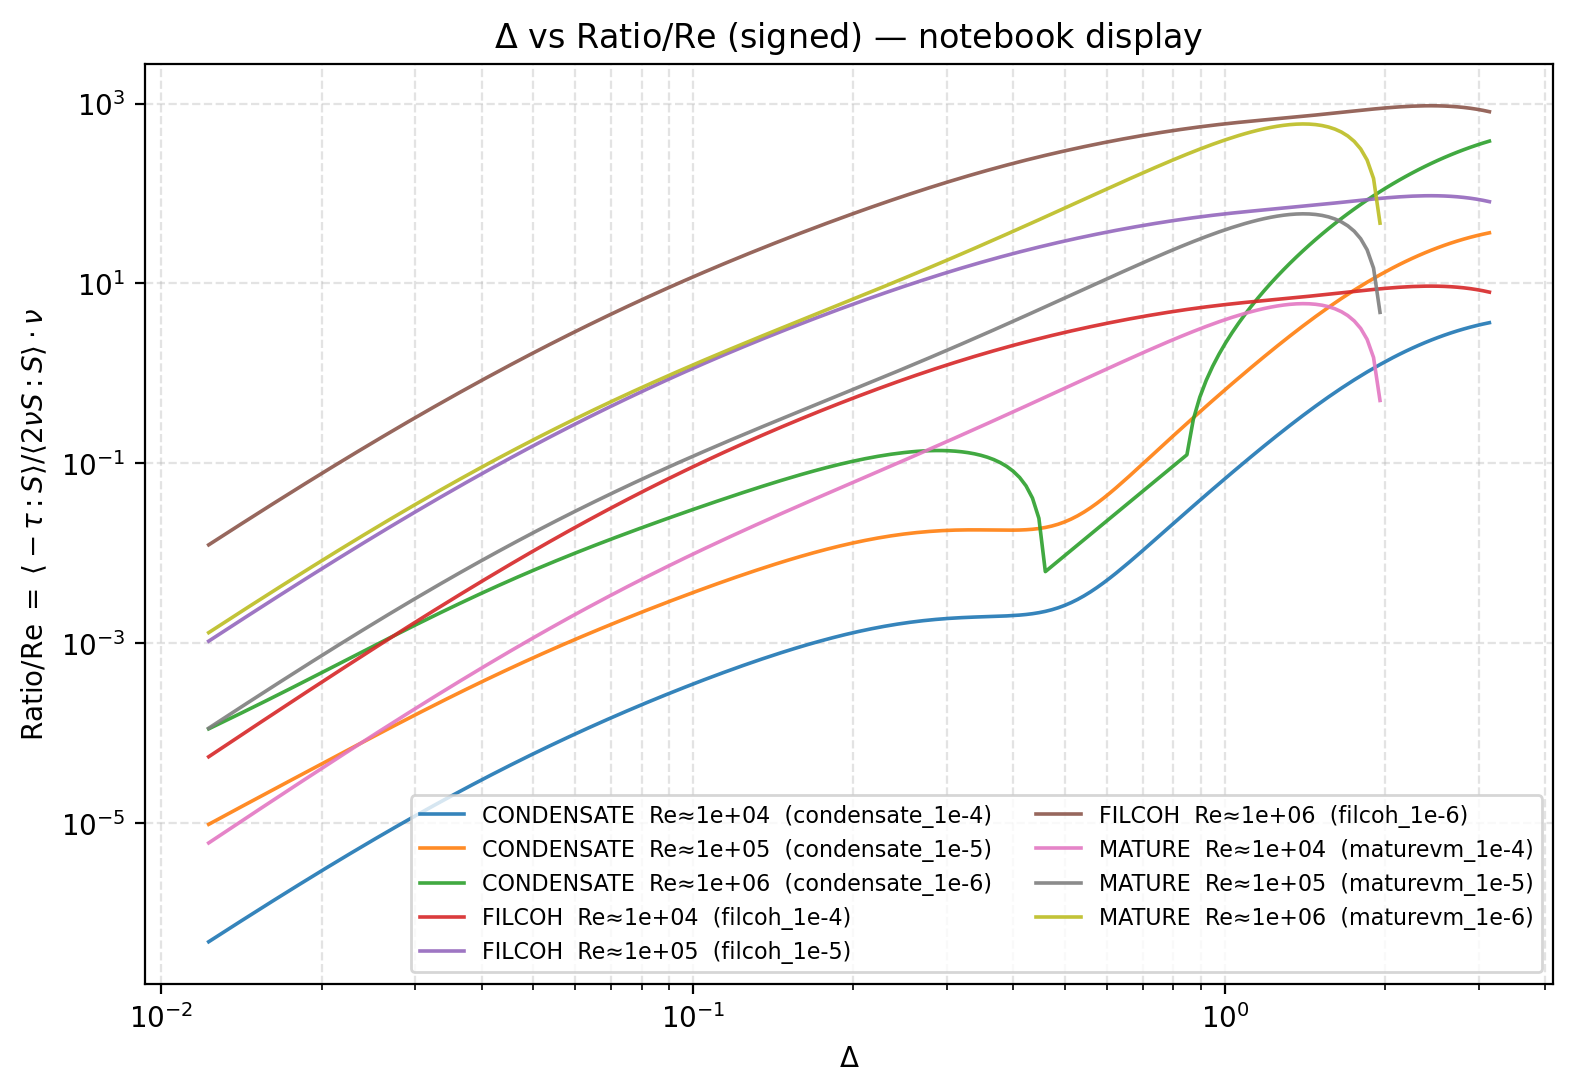

In [2]:
# %% [markdown]
# Δ vs (Ratio_signed / Re) — Jupyter-friendly (show-only, robust)

# %%
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"
# =====================

# ---- load & basic checks ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

required = {"family","dataset","nu","Delta","Ratio_signed"}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for c in ["nu","Delta","Ratio_signed"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df["Re_float"] = 1.0 / df["nu"]
df["y_ratio_over_Re"] = df["Ratio_signed"] 

# ---- diagnostics ----
finite_mask = (
    np.isfinite(df["Delta"]) &
    np.isfinite(df["y_ratio_over_Re"])
)
pos_mask = finite_mask & (df["Delta"] > 0) & (df["y_ratio_over_Re"] > 0)

total = len(df)
finite_count = int(finite_mask.sum())
pos_count = int(pos_mask.sum())

print(f"[INFO] total rows={total} | finite pairs={finite_count} | usable for log-log y>0={pos_count}")

# ---- choose scale & subset ----
if pos_count > 0:
    plot_df = df[pos_mask].copy()
    xscale, yscale, ymsg = "log", "log", ""
else:
    # fall back to signed-friendly symlog on y
    plot_df = df[finite_mask & (df["Delta"] > 0)].copy()
    xscale, yscale, ymsg = "log", "symlog", " (symlog)"
    print("[WARN] No positive y for log–log; using y='symlog' so signed values are visible.")

if plot_df.empty:
    raise RuntimeError("No valid points to plot (check that Δ>0 and values are finite).")

# ---- plot ----
plt.figure(figsize=(8, 5.6))
plt.xscale(xscale); plt.yscale(yscale)
if yscale == "symlog":
    plt.yscale("symlog", linthresh=1e-8)

families = [f for f in plot_df["family"].dropna().unique() if isinstance(f, str)]
families.sort()

markers    = ["o","s","^","D","v","P","X","*"]
linestyles = ["-","--","-."," :".replace(" ","")]

legend_entries = 0
for fi, fam in enumerate(families):
    sub = plot_df[plot_df["family"] == fam]
    # group by continuous Re value
    for ri, (Re_val, grp) in enumerate(sub.groupby("Re_float")):
        if not np.isfinite(Re_val) or grp.empty:
            continue
        grp = grp.sort_values("Delta")
        label = f"{fam}  Re≈{Re_val:.0e}  ({grp['dataset'].iloc[0]})"
        plt.plot(
            grp["Delta"].to_numpy(),
            grp["y_ratio_over_Re"].to_numpy(),
            #linestyle=linestyles[fi % len(linestyles)],
            #marker=markers[ri % len(markers)],
            ms=3.5, lw=1.3, alpha=0.9, label=label
        )
        legend_entries += 1

plt.xlabel(r"$\Delta$")
ylabel = r"$\mathrm{Ratio}/\mathrm{Re}\;=\;\langle -\tau:S\rangle / \langle 2\nu S:S\rangle \cdot \nu$" + ymsg
plt.ylabel(ylabel)
plt.title(r"$\Delta$ vs Ratio/Re (signed) — notebook display")
plt.grid(True, which="both", ls="--", alpha=0.35)
if legend_entries:
    plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

[INFO] total rows=1800 | finite pairs=1800 | usable for log-log (x>0,y>0)=1728


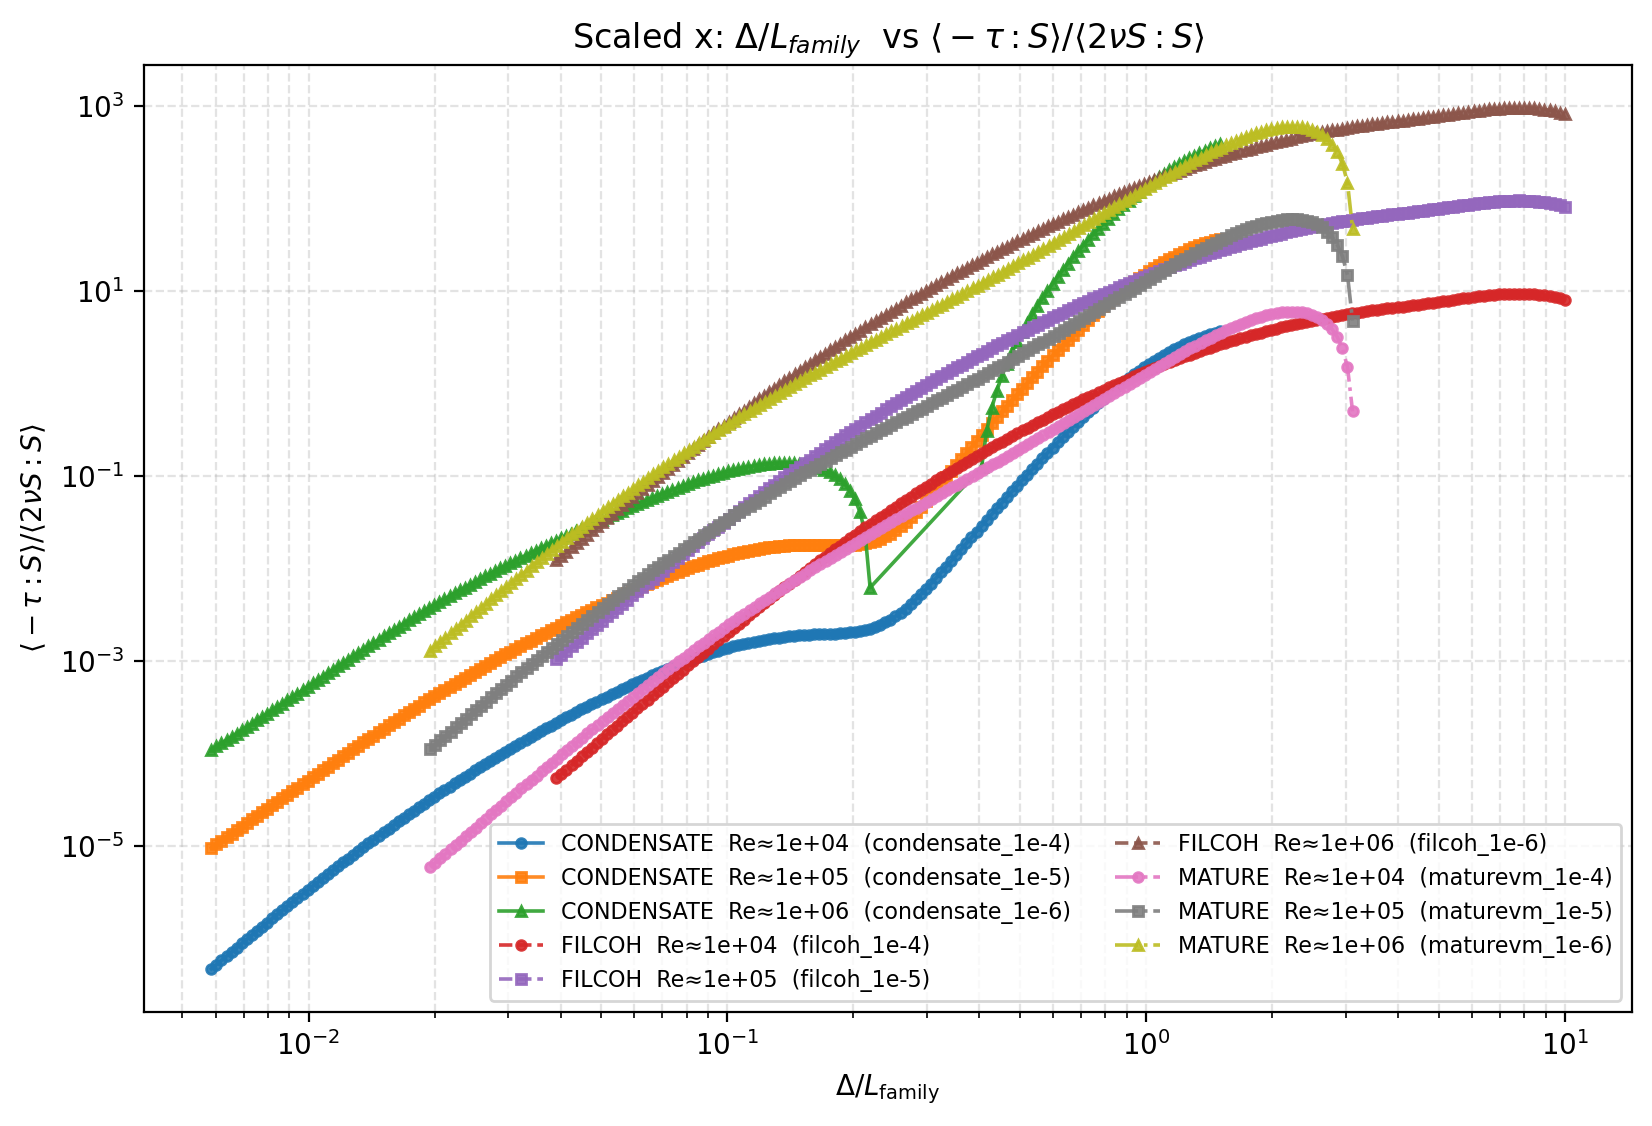

In [3]:
# %% [markdown]
# Δ/L_family (optionally * Re) vs (Ratio_signed) — Jupyter, show-only

# %%
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"

# Set a lengthscale per FAMILY (edit these to your chosen definitions)
# Example: FILCOH uses L = 2π/25, MATURE uses L = 2π/10
LENGTHSCALES = {
    "FILCOH": 2*np.pi/20.0,
    "MATURE": 2*np.pi/10.0,
    "CONDENSATE": 2*np.pi/3.0,
}

# If True, multiply x by Re (i.e., x = (Δ/L_family) * Re)
MULTIPLY_X_BY_RE = False
RE_LABEL = r"\,Re" if MULTIPLY_X_BY_RE else ""

# Y choice (keep as your current 'Ratio_signed')
Y_COLUMN = "Ratio_signed"
Y_LABEL = r"$\langle -\tau:S\rangle / \langle 2\nu S:S\rangle$"
# =====================

# ---- load & checks ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

required = {"family","dataset","nu","Delta", Y_COLUMN}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for c in ["nu","Delta", Y_COLUMN]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Compute Re and x-scaling by family
df["Re_float"] = 1.0 / df["nu"]

def family_L(fam: str) -> float:
    if fam in LENGTHSCALES and LENGTHSCALES[fam] is not None:
        return float(LENGTHSCALES[fam])
    # Fallback if unknown: use 1.0 (no scale), but warn in label
    return 1.0

df["L_family"] = df["family"].map(family_L).astype(float)

# x := Δ / L_family  (optionally * Re)
df["x_scaled"] = df["Delta"] / df["L_family"]
if MULTIPLY_X_BY_RE:
    df["x_scaled"] = df["x_scaled"] * df["Re_float"]

# y := chosen column (signed allowed)
df["y_val"] = df[Y_COLUMN]

# ---- diagnostics ----
finite_mask = np.isfinite(df["x_scaled"]) & np.isfinite(df["y_val"])
pos_log_mask = finite_mask & (df["x_scaled"] > 0) & (df["y_val"] > 0)

total = len(df)
finite_count = int(finite_mask.sum())
pos_count = int(pos_log_mask.sum())
print(f"[INFO] total rows={total} | finite pairs={finite_count} | usable for log-log (x>0,y>0)={pos_count}")

# ---- choose scale & subset ----
if pos_count > 0:
    plot_df = df[pos_log_mask].copy()
    xscale, yscale, ymsg = "log", "log", ""
else:
    # fall back to signed-friendly symlog on y; still require x>0 for log x
    plot_df = df[finite_mask & (df["x_scaled"] > 0)].copy()
    xscale, yscale, ymsg = "log", "symlog", " (symlog)"
    print("[WARN] No positive y for log–log; using y='symlog' so signed values are visible.")

if plot_df.empty:
    raise RuntimeError("No valid points to plot (need x>0; check LENGTHSCALES and data.)")

# ---- plot ----
plt.figure(figsize=(8.4, 5.8))
plt.xscale(xscale)
if yscale == "log":
    plt.yscale("log")
else:
    plt.yscale("symlog", linthresh=1e-8)

families = [f for f in plot_df["family"].dropna().unique() if isinstance(f, str)]
families.sort()

markers    = ["o","s","^","D","v","P","X","*"]
linestyles = ["-","--","-."," :".replace(" ","")]

legend_entries = 0
for fi, fam in enumerate(families):
    sub = plot_df[plot_df["family"] == fam]
    for ri, (Re_val, grp) in enumerate(sub.groupby("Re_float")):
        if not np.isfinite(Re_val) or grp.empty:
            continue
        grp = grp.sort_values("x_scaled")
        label = f"{fam}  Re≈{Re_val:.0e}  ({grp['dataset'].iloc[0]})"
        plt.plot(
            grp["x_scaled"].to_numpy(),
            grp["y_val"].to_numpy(),
            linestyle=linestyles[fi % len(linestyles)],
            marker=markers[ri % len(markers)],
            ms=3.5, lw=1.3, alpha=0.9, label=label
        )
        legend_entries += 1

# Labels
xlab = r"$\Delta / L_{\mathrm{family}}$" + RE_LABEL
plt.xlabel(xlab)
plt.ylabel(Y_LABEL + ymsg)
title_extra = r"$\times\,Re$" if MULTIPLY_X_BY_RE else ""
plt.title(rf"Scaled x: $\Delta/L_{{family}}$ {title_extra} vs {Y_LABEL}")
plt.grid(True, which="both", ls="--", alpha=0.35)
if legend_entries:
    plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

[DIAG] column stats:
        family: {'unique': 3, 'sample': ['CONDENSATE', 'FILCOH', 'MATURE'], 'dtype': 'object'}
       dataset: {'unique': 9, 'sample': ['condensate_1e-4', 'condensate_1e-5', 'condensate_1e-6', 'filcoh_1e-4', 'filcoh_1e-5'], 'dtype': 'object'}
            nu: {'nan': 0, 'finite': 1800, 'min': 1e-06, 'max': 0.0001, 'dtype': 'float64'}
         Delta: {'nan': 0, 'finite': 1800, 'min': 0.0122718463, 'max': 3.14159265, 'dtype': 'float64'}
  Ratio_signed: {'nan': 0, 'finite': 1800, 'min': -2803.98956, 'max': 946.572195, 'dtype': 'float64'}
[INFO] dropped 0 rows due to unknown/invalid L_family
[INFO] total rows=1800 | finite after parsing=1800 | after Δ/L cuts=1719 | dropped_by_family={'CONDENSATE': 0, 'FILCOH': 0, 'MATURE': 81}


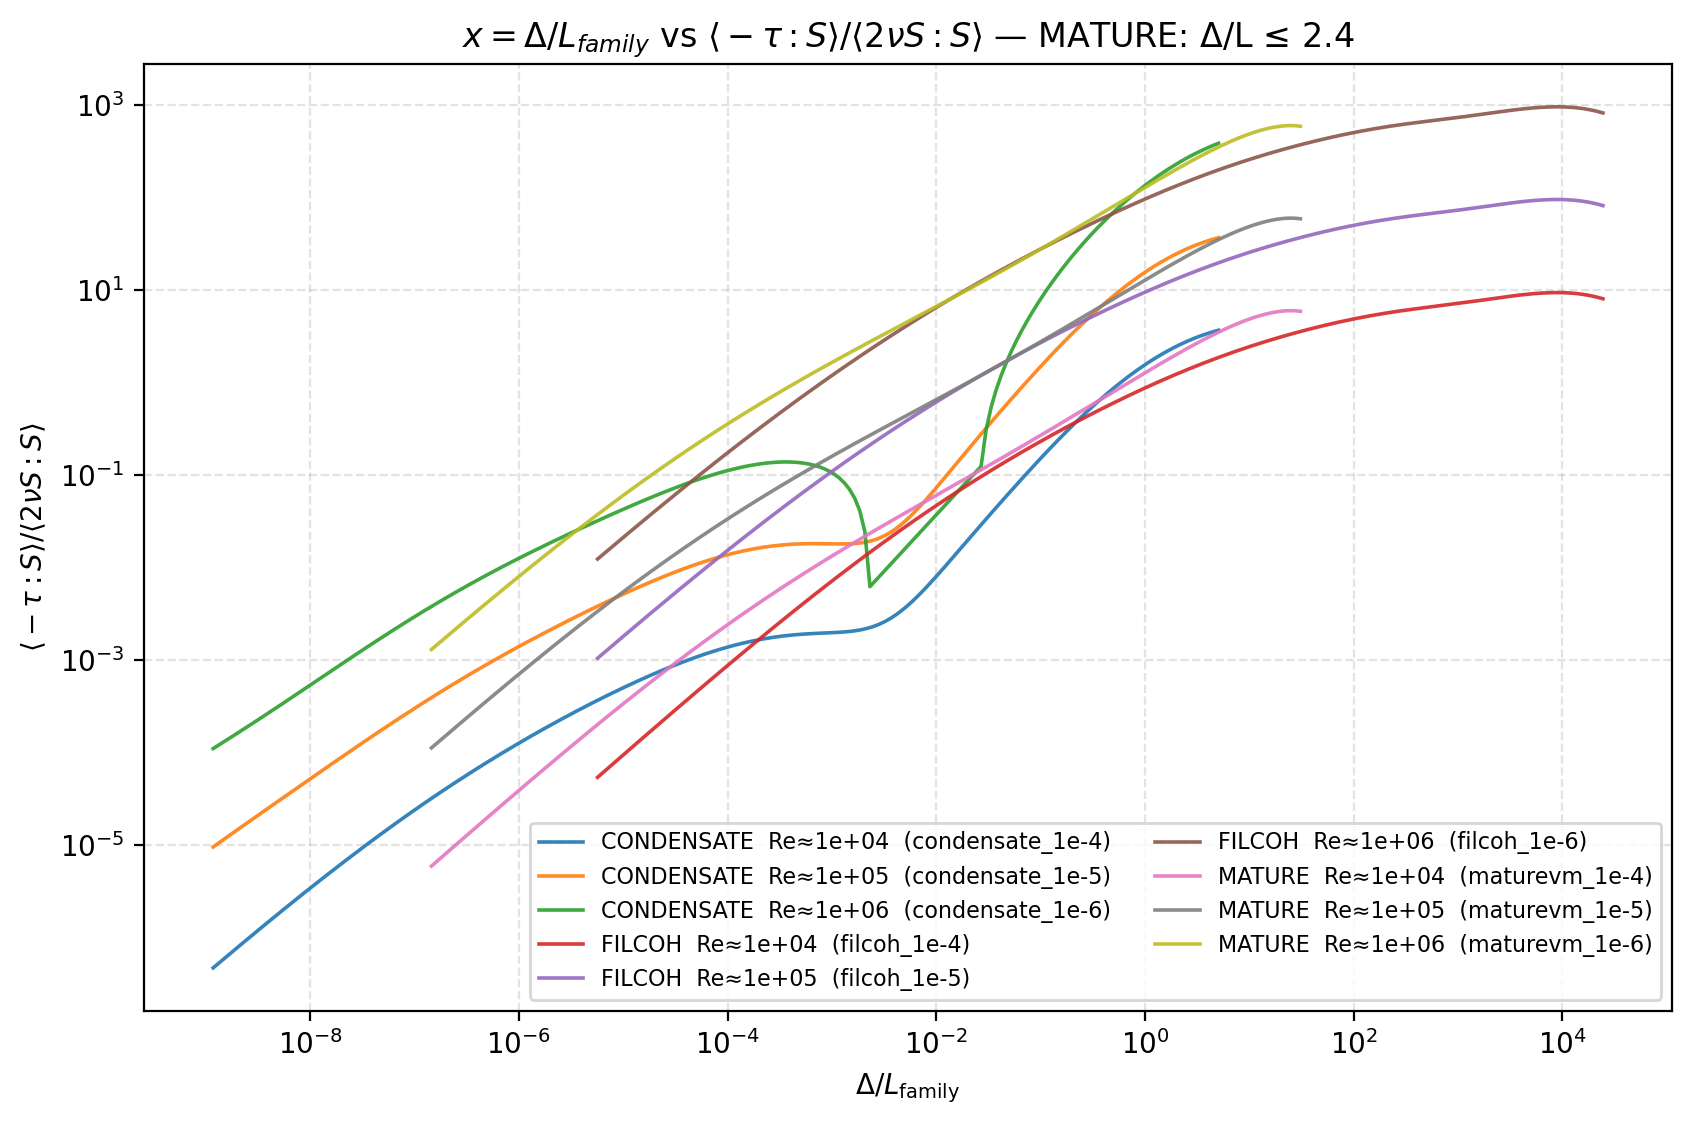

In [4]:
# %% [markdown]
# Δ/L_family (optionally × Re) vs Ratio_signed — per-family cuts + robust diagnostics (show-only)

# %%
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"

# Per-family lengthscales
LENGTHSCALES = {
    "FILCOH":  2*np.pi/25.0,
    "MATURE": 2*np.pi/10.0,
    "CONDENSATE": 2*np.pi/3.0,
}

# Per-family Δ/L cuts (applied to x_base = Δ/L_family BEFORE any ×Re)
CUT_MAX_XBASE = {
    "FILCOH": None,   # e.g., 0.25
    "MATURE": 2.4,   # e.g., 0.15
}
CUT_MIN_XBASE = {
    "FILCOH": None,
    "MATURE": None,
}

# Optional multiply x by Re  (x_scaled = x_base * Re)
MULTIPLY_X_BY_RE = False

Y_COLUMN = "Ratio_signed"
Y_LABEL  = r"$\langle -\tau:S\rangle / \langle 2\nu S:S\rangle$"
# ===============================================

# ---- load ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

required = {"family","dataset","nu","Delta",Y_COLUMN}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# ---- sanitize family names ----
def normalize_family(x):
    s = str(x).strip().upper()
    if s.startswith("FILCOH"):  return "FILCOH"
    if s.startswith("MATURE"):  return "MATURE"
    return s
df["family"] = df["family"].map(normalize_family)

# ---- numeric coercion for numeric cols ----
def to_num(series):
    cleaned = series.astype(str).str.strip().str.replace(",", "", regex=False)
    cleaned = cleaned.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")

for c in ["nu", "Delta", Y_COLUMN]:
    df[c] = to_num(df[c])

# ---- safe diagnostics (no isfinite on strings) ----
def col_stats(s: pd.Series):
    if is_numeric_dtype(s):
        arr = s.to_numpy()
        finite = np.isfinite(arr)
        return {
            "nan": int(np.isnan(arr).sum()),
            "finite": int(finite.sum()),
            "min": float(arr[finite].min()) if finite.any() else None,
            "max": float(arr[finite].max()) if finite.any() else None,
            "dtype": s.dtype.name,
        }
    else:
        return {
            "unique": int(s.nunique(dropna=True)),
            "sample": list(s.dropna().astype(str).unique()[:5]),
            "dtype": s.dtype.name,
        }

print("[DIAG] column stats:")
for col in ["family","dataset","nu","Delta",Y_COLUMN]:
    print(f"  {col:>12}: {col_stats(df[col])}")

# Quick hard checks for numeric columns
for col in ["Delta", Y_COLUMN, "nu"]:
    if not is_numeric_dtype(df[col]) or not np.isfinite(df[col].to_numpy()).any():
        raise RuntimeError(f"Column '{col}' has no finite numeric values after parsing. Check the CSV.")

# ---- compute Re, L_family, x_base/x_scaled, y_val ----
df["Re_float"] = 1.0 / df["nu"]
df["L_family"] = df["family"].map(lambda fam: float(LENGTHSCALES.get(fam, np.nan)))
unknown = sorted(set(df["family"].unique()) - set(LENGTHSCALES.keys()))
if unknown:
    print(f"[WARN] Families with no LENGTHSCALE mapping (dropping): {unknown}")
before = len(df)
df = df[np.isfinite(df["L_family"])]
print(f"[INFO] dropped {before - len(df)} rows due to unknown/invalid L_family")

df["x_base"]   = df["Delta"] / df["L_family"]
df["x_scaled"] = df["x_base"] * (df["Re_float"] if MULTIPLY_X_BY_RE else 1.0)
df["y_val"]    = df[Y_COLUMN]

# ---- apply per-family Δ/L cuts (on x_base) ----
mask_cuts = np.ones(len(df), dtype=bool)
dropped_by_fam = {}
for fam in df["family"].dropna().unique():
    fam_mask = (df["family"] == fam)
    fam_keep = np.ones(len(df), dtype=bool)
    xmax = CUT_MAX_XBASE.get(fam)
    xmin = CUT_MIN_XBASE.get(fam)
    if xmax is not None:
        fam_keep &= ((df["x_base"] <= float(xmax)) | ~fam_mask)
    if xmin is not None:
        fam_keep &= ((df["x_base"] >= float(xmin)) | ~fam_mask)
    before_fam = int(fam_mask.sum())
    after_fam  = int((fam_mask & fam_keep).sum())
    dropped_by_fam[fam] = before_fam - after_fam
    mask_cuts &= fam_keep

# ---- finite filter + cuts ----
finite_mask = np.isfinite(df["x_scaled"]) & np.isfinite(df["y_val"])
mask = finite_mask & mask_cuts
print(f"[INFO] total rows={len(df)} | finite after parsing={int(finite_mask.sum())} | "
      f"after Δ/L cuts={int(mask.sum())} | dropped_by_family={dropped_by_fam}")

if mask.sum() == 0:
    # Show a few problematic rows for debugging
    bad = df[~finite_mask].head(5)
    print("[DEBUG] Non-finite rows example:")
    display(bad[["family","dataset","Delta","L_family","x_base","x_scaled","y_val","nu"]])
    raise RuntimeError("No valid points after sanitation + cuts. "
                       "Check NaNs in Delta/nu/Ratio_signed and your LENGTHSCALES/CUTS.")

# ---- choose scale ----
pos_log_mask = mask & (df["x_scaled"] > 0) & (df["y_val"] > 0)
if int(pos_log_mask.sum()) > 0:
    plot_df = df[pos_log_mask].copy()
    xscale, yscale, ymsg = "log", "log", ""
else:
    fallback_mask = mask & (df["x_scaled"] > 0)
    plot_df = df[fallback_mask].copy()
    xscale, yscale, ymsg = "log", "symlog", " (symlog)"
    print("[WARN] No positive y after cuts for log–log; using y='symlog' to show signed values.")

if plot_df.empty:
    print("[DEBUG] Example rows with x<=0 after cuts:", df[mask & (df["x_scaled"] <= 0)].head(3))
    raise RuntimeError("No valid points to plot (x must be > 0). Adjust Δ/L cuts or LENGTHSCALES.")

# ---- plot ----
plt.figure(figsize=(8.6, 5.8))
plt.xscale(xscale)
if yscale == "log":
    plt.yscale("log")
else:
    plt.yscale("symlog", linthresh=1e-8)

families = sorted([f for f in plot_df["family"].dropna().unique() if isinstance(f, str)])
markers    = ["o","s","^","D","v","P","X","*"]
linestyles = ["-","--","-."," :".replace(" ","")]

legend_entries = 0
for fi, fam in enumerate(families):
    sub = plot_df[plot_df["family"] == fam]
    for ri, (Re_val, grp) in enumerate(sub.groupby("Re_float")):
        if not np.isfinite(Re_val) or grp.empty:
            continue
        grp = grp.sort_values("x_scaled")
        label = f"{fam}  Re≈{Re_val:.0e}  ({grp['dataset'].iloc[0]})"
        plt.plot(
            grp["x_scaled"].to_numpy()**4,
            grp["y_val"].to_numpy(),
            #linestyle=linestyles[fi % len(linestyles)],
            #marker=markers[ri % len(markers)],
            ms=3.5, lw=1.3, alpha=0.9, label=label
        )
        legend_entries += 1

xlab = r"$\Delta / L_{\mathrm{family}}$" + (r"\,\times Re" if MULTIPLY_X_BY_RE else "")
plt.xlabel(xlab)
plt.ylabel(Y_LABEL + ymsg)

cuts_txt = []
for fam in ["FILCOH","MATURE"]:
    lo = CUT_MIN_XBASE.get(fam); hi = CUT_MAX_XBASE.get(fam)
    if (lo is not None) or (hi is not None):
        seg = []
        if lo is not None: seg.append(f"{lo:g} ≤")
        seg.append("Δ/L")
        if hi is not None: seg.append(f"≤ {hi:g}")
        cuts_txt.append(f"{fam}: " + " ".join(seg))
subtitle = (" | ".join(cuts_txt)) if cuts_txt else "no Δ/L cuts"
title_extra = " × Re" if MULTIPLY_X_BY_RE else ""
plt.title(rf"$x = \Delta/L_{{family}}{title_extra}$ vs {Y_LABEL} — {subtitle}")

plt.grid(True, which="both", ls="--", alpha=0.35)
if legend_entries:
    plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
# ---- grid & ticks: show ONLY decade lines (10^k) ----
from matplotlib.ticker import LogLocator, NullFormatter, FuncFormatter
ax = plt.gca()

# X axis (always log in your script)
if xscale == "log":
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    # No minor ticks at all
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=()))
    ax.xaxis.set_minor_formatter(NullFormatter())

# Y axis
if yscale == "log":
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=()))
    ax.yaxis.set_minor_formatter(NullFormatter())
else:
    # symlog: build symmetric decade ticks (… -1e2, -1e1, -1, 0, 1, 1e1, 1e2, …), skipping the linear core
    linthresh = 1e-8  # must match the one used in set_yscale
    ymin, ymax = ax.get_ylim()
    rng_max = max(abs(ymin), abs(ymax))
    # choose a sensible exponent range
    if rng_max <= 0:
        decade_ticks = [0.0]
    else:
        import math
        kmax = int(math.floor(math.log10(rng_max)))
        kmin = int(math.ceil(math.log10(linthresh))) if linthresh > 0 else -12
        ks = list(range(kmin, kmax + 1))
        pos = [10.0**k for k in ks]
        neg = [-v for v in pos]
        decade_ticks = [v for v in (neg[::-1] + [0.0] + pos) if (ymin <= v <= ymax)]
    ax.set_yticks(decade_ticks)

    # Nice labels for symlog decades
    def _fmt_symlog_tick(v):
        if v == 0:
            return "0"
        s = "-" if v < 0 else ""
        p = abs(v)
        k = int(round(np.log10(p)))
        # ensure it's exactly a decade (within FP tolerance)
        if np.isclose(p, 10.0**k, rtol=1e-12, atol=0.0):
            return rf"{s}$10^{{{k}}}$"
        return ""  # should not happen with our constructed ticks
    ax.set_yticklabels([_fmt_symlog_tick(v) for v in ax.get_yticks()])

# Grid: ONLY major ticks -> ONLY decades
ax.grid(True, which="major", ls="--", alpha=0.35)
ax.grid(False, which="minor")

plt.show()


=== Fitting L_eff for p=2 ===
[OK] FILCOH: L_eff = 0.567287  (objective=0.2909)
[OK] MATURE: L_eff = 0.749467  (objective=0.2667)

=== Fitting L_eff for p=3 ===
[OK] FILCOH: L_eff = 0.157154  (objective=0.1728)
[OK] MATURE: L_eff = 0.159347  (objective=0.1012)

=== Fitting L_eff for p=4 ===
[OK] FILCOH: L_eff = 0.157542  (objective=0.2937)
[OK] MATURE: L_eff = 0.159984  (objective=0.2653)

[plot] Using p=2 with fitted L_eff: {'FILCOH': '0.567287', 'MATURE': '0.749467'}


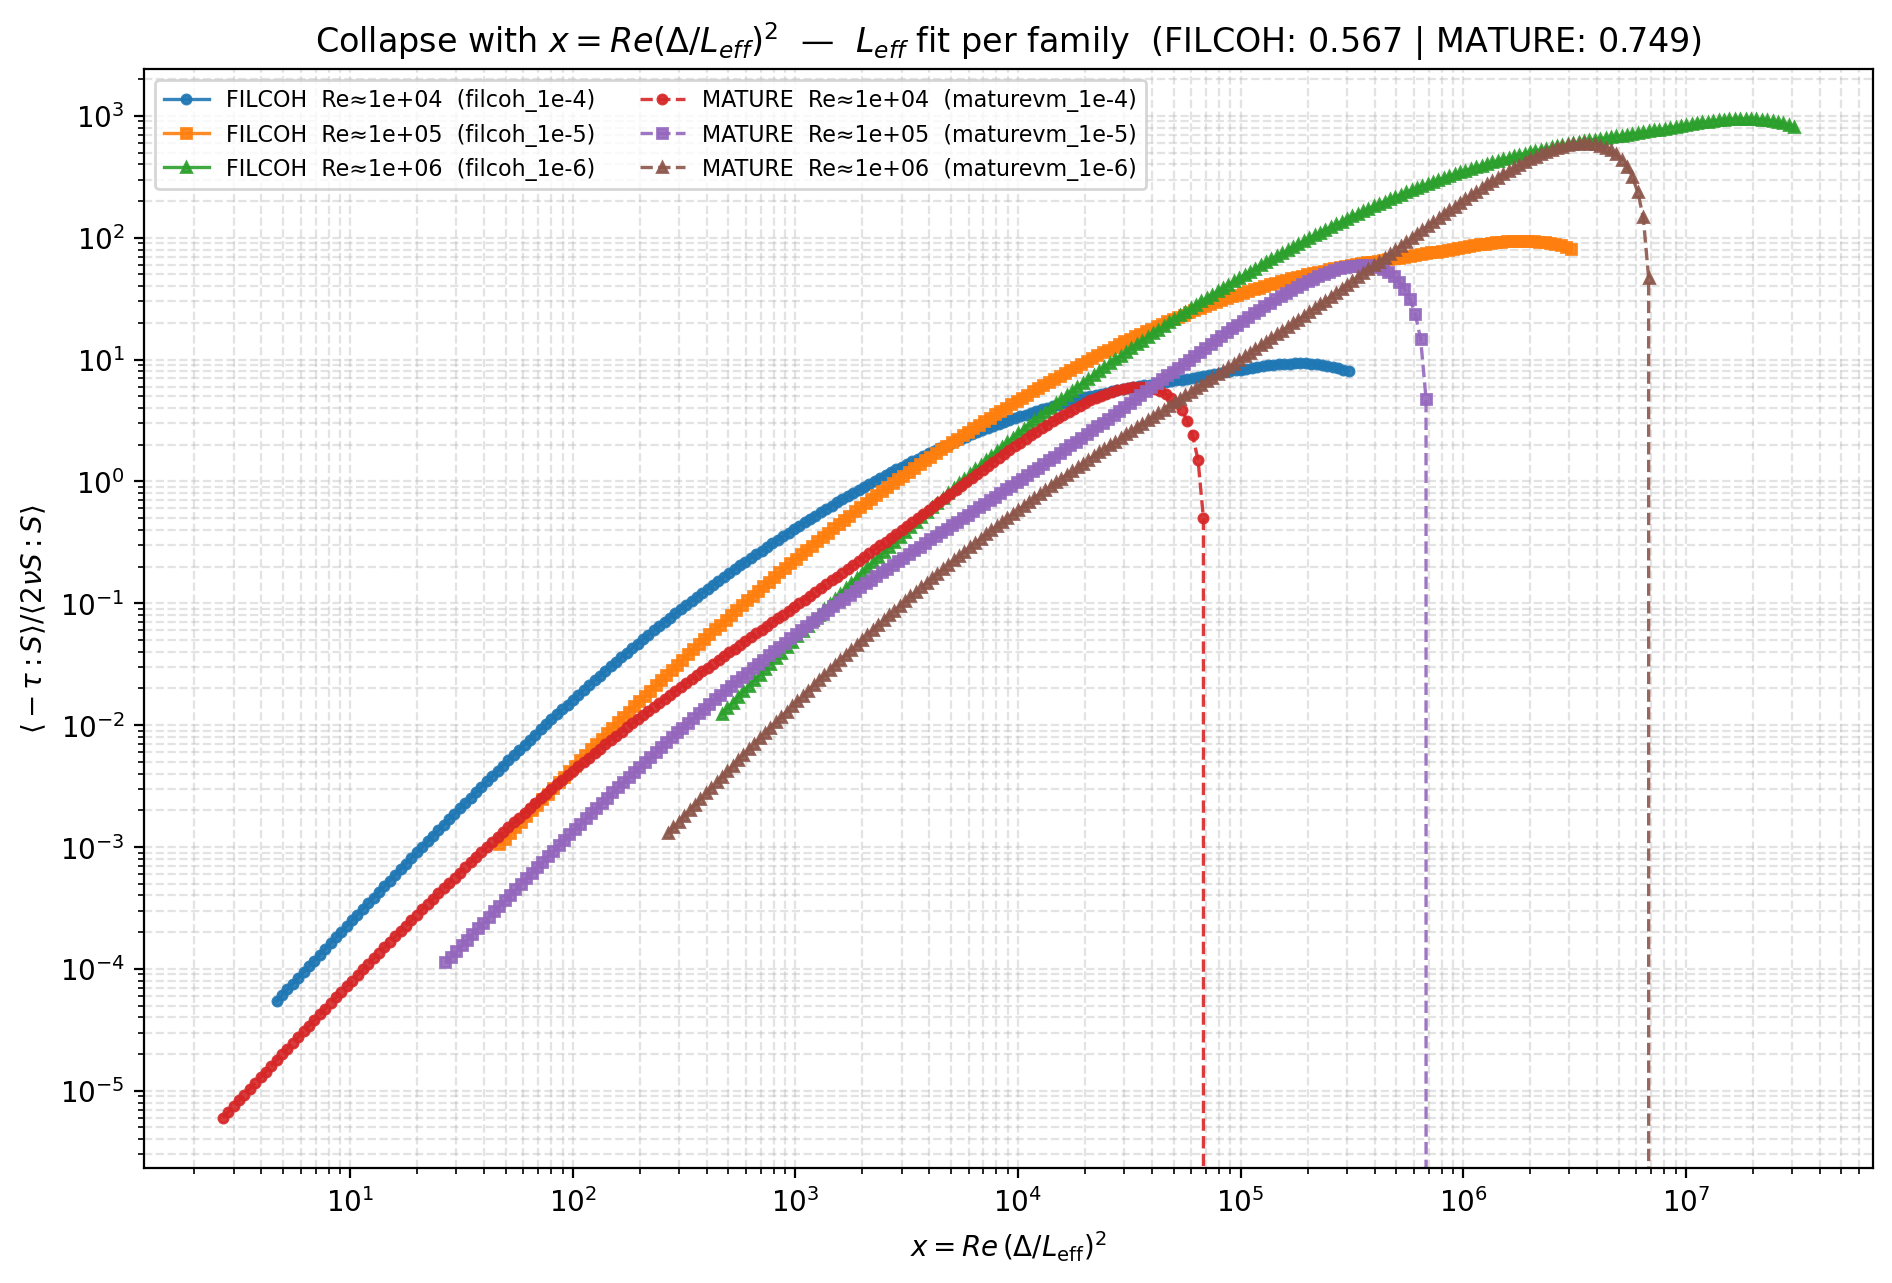


[plot] Using p=3 with fitted L_eff: {'FILCOH': '0.157154', 'MATURE': '0.159347'}


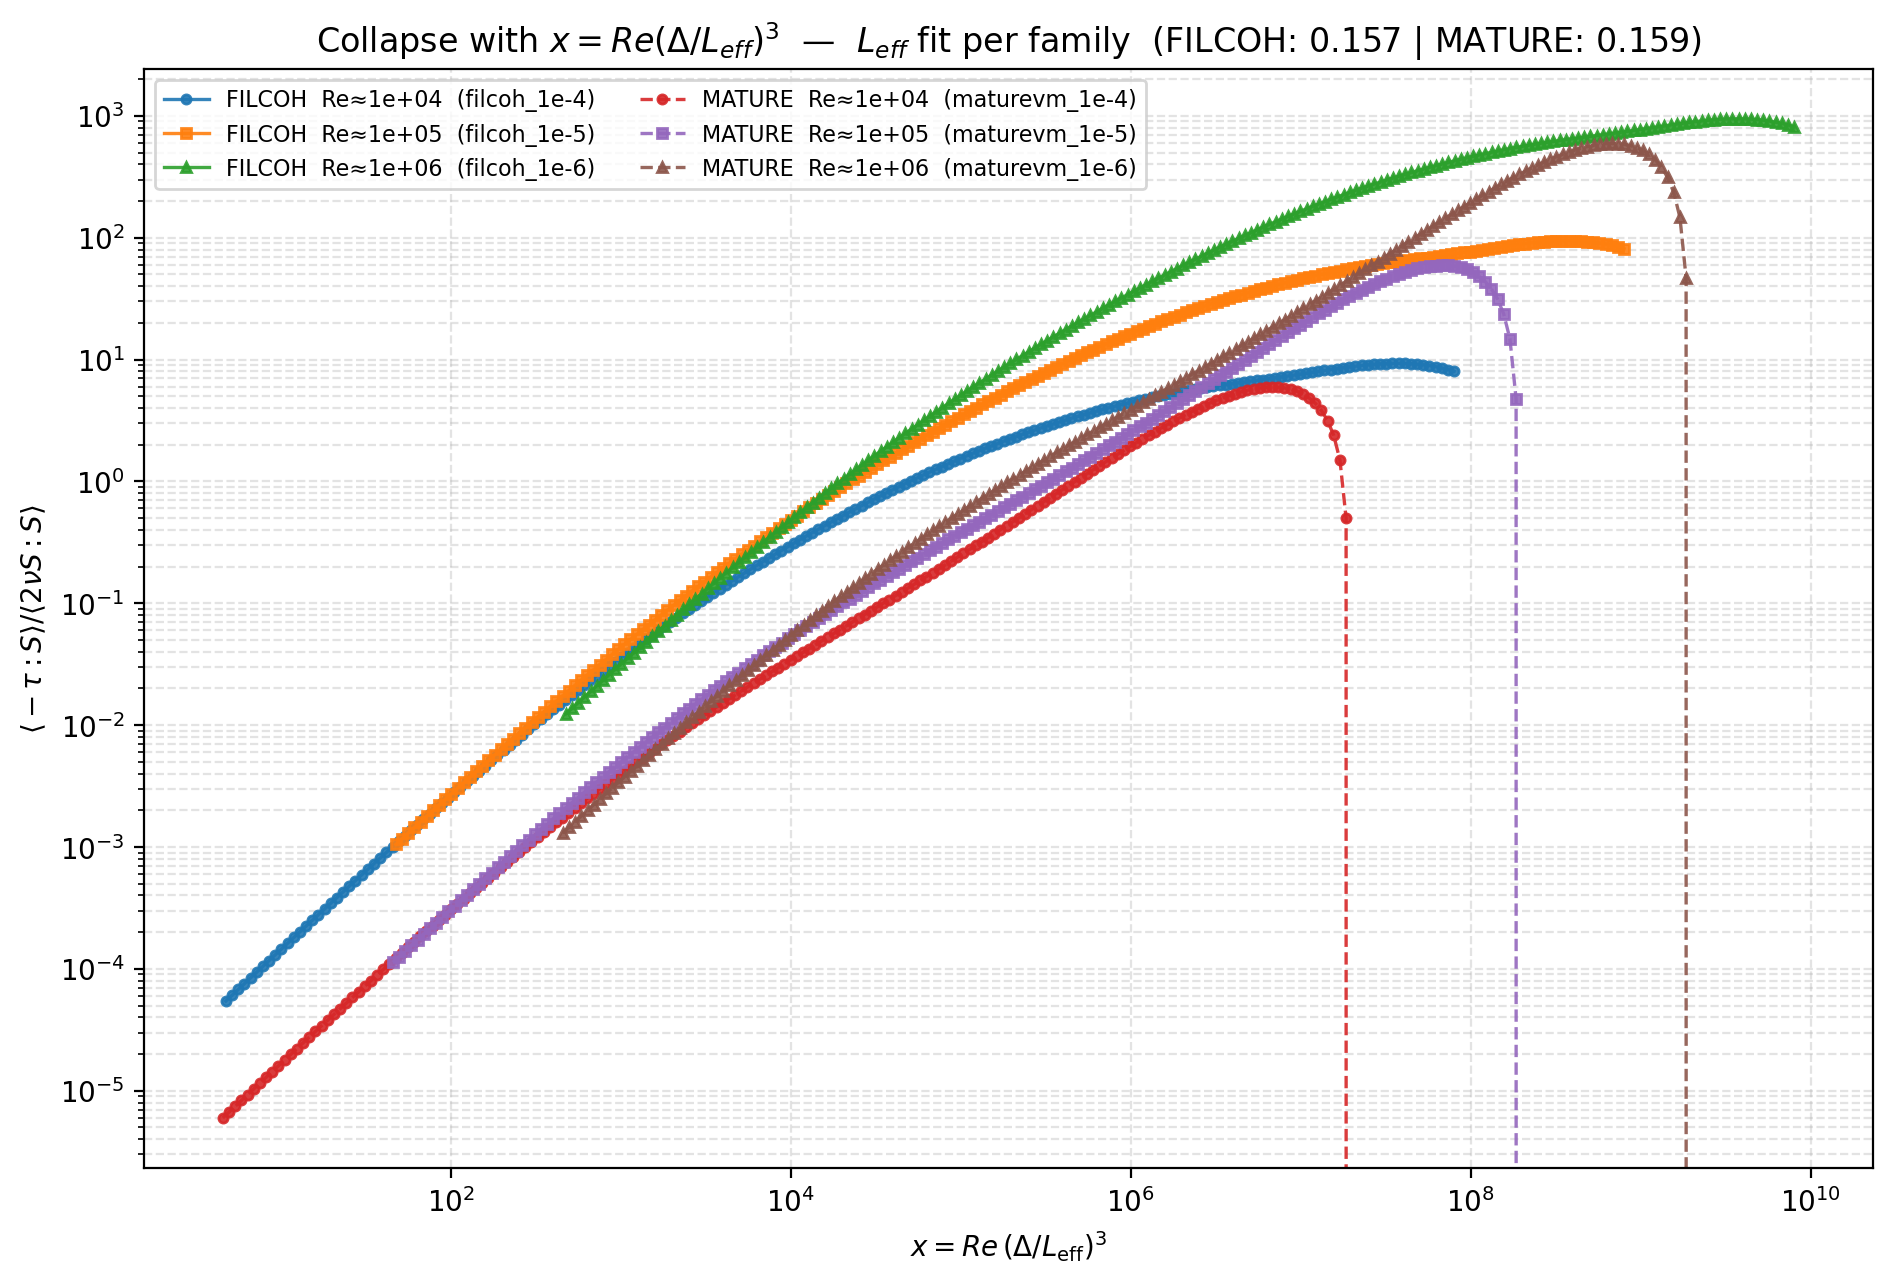


[plot] Using p=4 with fitted L_eff: {'FILCOH': '0.157542', 'MATURE': '0.159984'}


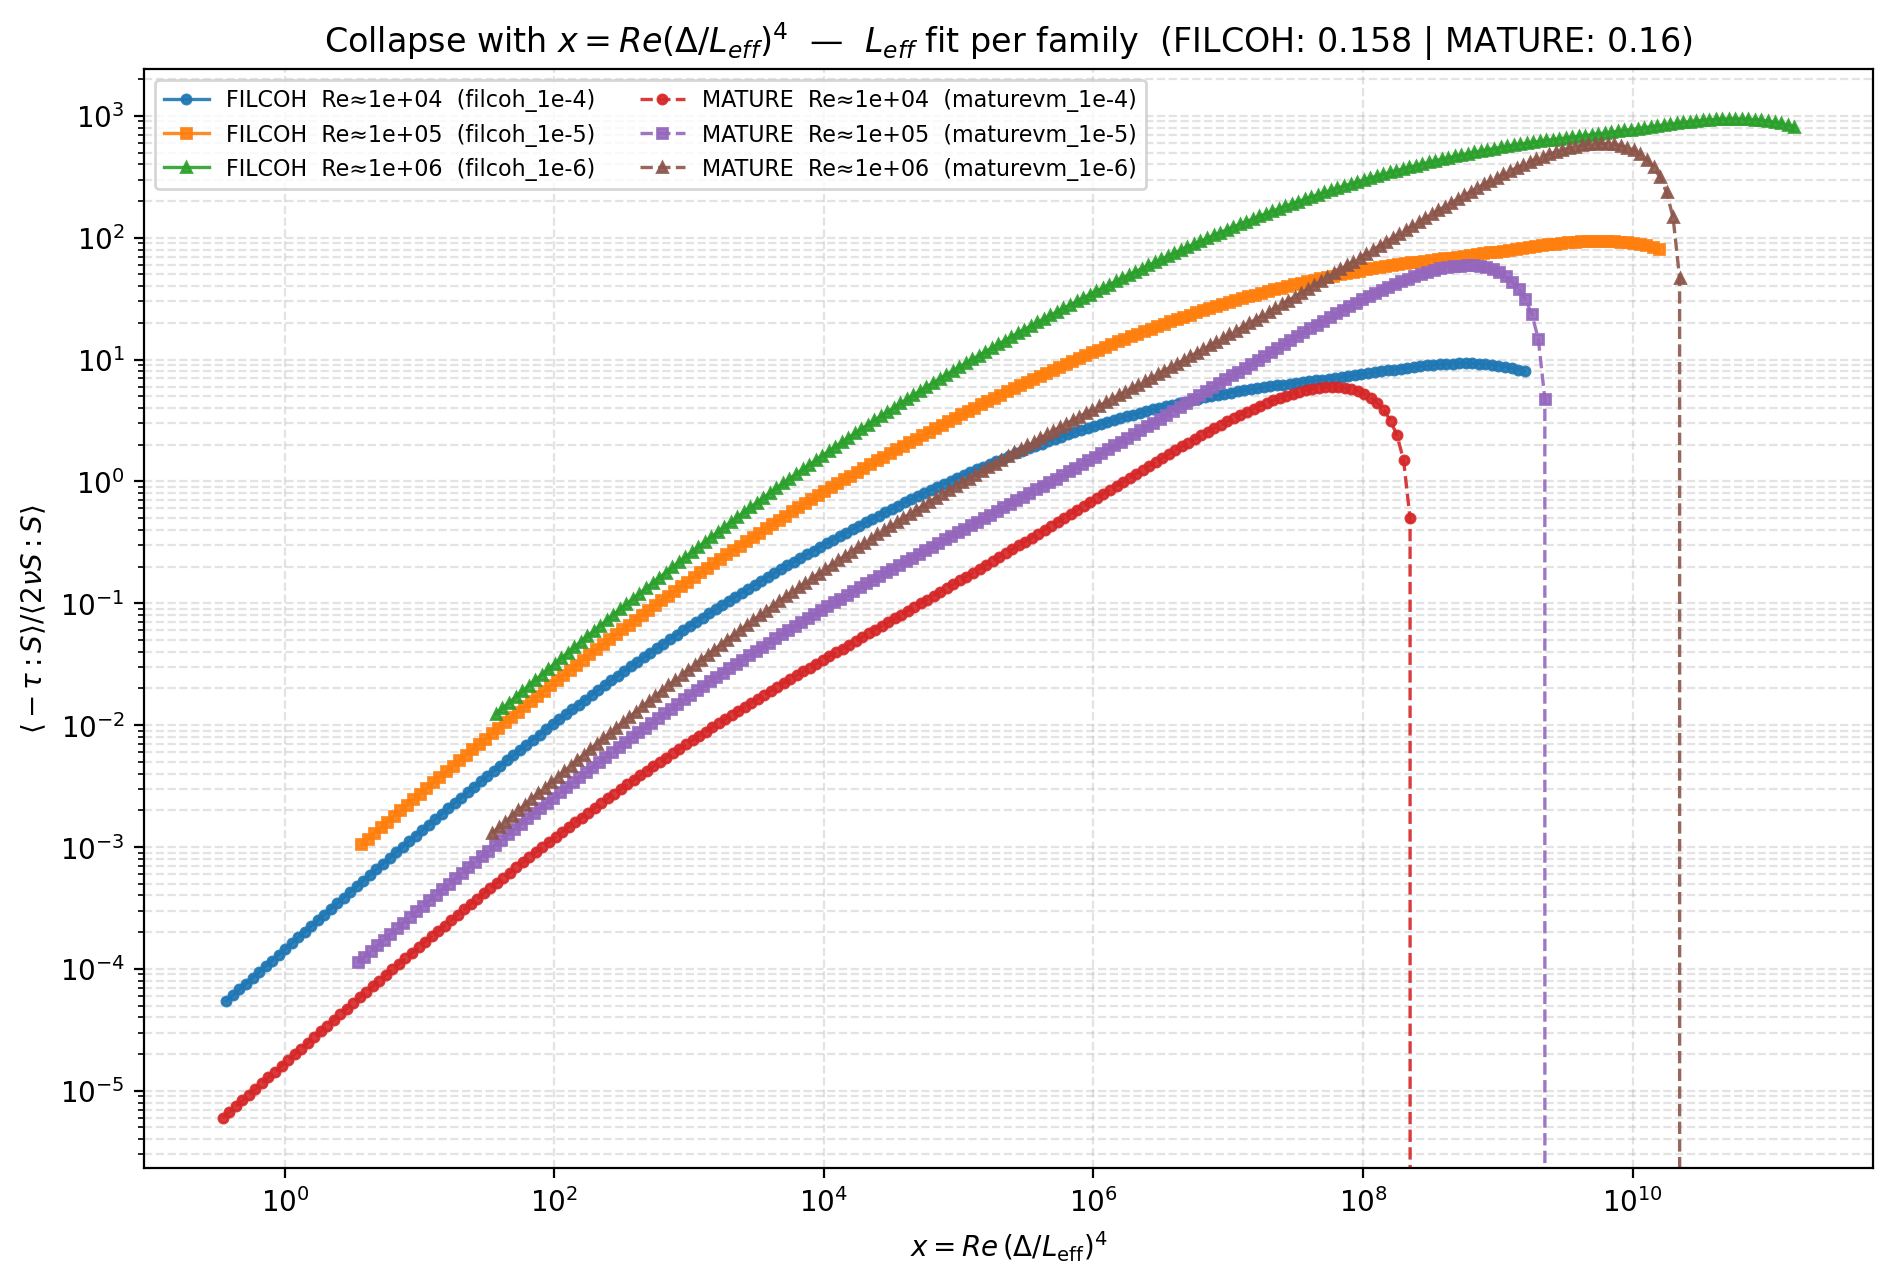

In [46]:
# %% [markdown]
# Empirical L_eff per family for collapse with x = Re*(Δ/L_eff)^p, p ∈ {2,4}

# %%
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"

FAMILIES      = ["FILCOH", "MATURE"]     # which families to fit
P_EXPTS       = [2, 3,4]                    # try p=2 and p=4
Y_COLUMN      = "Ratio_signed"            # signed; we use y>0 for log objective
X_LOG_GRID    = np.linspace(-6, +6, 241)  # common log10(x) grid for family alignment
BRACKETS_L0   = {                         # search bracket for L_eff (in absolute Δ units)
    "FILCOH": (2*np.pi/40, 2*np.pi/5),    # wide bracket; tweak if needed
    "MATURE": (2*np.pi/40, 2*np.pi/5),
}
INIT_GUESS    = {                         # initial guesses for L_eff
    "FILCOH": 2*np.pi/25,
    "MATURE": 2*np.pi/10,
}
# Plot aesthetics
MARKERS    = ["o","s","^","D","v","P","X","*"]
LINESTYLES = ["-","--","-."," :".replace(" ","")]
# ===============================================

# ---- load & basic sanitize ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

req = {"family","dataset","nu","Delta",Y_COLUMN}
missing = req - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def to_num(s):
    t = s.astype(str).str.strip().str.replace(",", "", regex=False)
    t = t.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(t, errors="coerce")

df["family"] = df["family"].astype(str).str.strip().str.upper()
for c in ["nu","Delta",Y_COLUMN]:
    df[c] = to_num(df[c])

# Compute Re, basic masks
df["Re_float"] = 1.0 / df["nu"]
finite_mask = np.isfinite(df["Delta"]) & np.isfinite(df["Re_float"]) & np.isfinite(df[Y_COLUMN])
df = df[finite_mask].copy()

# ---- helpers: golden-section search over log L ----
def golden_minimize(func, a, b, x0=None, tol=1e-3, maxiter=80):
    """
    Minimize func(logL) on [log a, log b] using golden section.
    Returns (x_opt, f_opt). Works on log-domain to keep L>0.
    """
    phi = (1 + 5**0.5) / 2
    invphi = 1/phi
    lo, hi = np.log(a), np.log(b)
    if x0 is not None:
        x0 = np.log(x0)
        # clamp inside
        x0 = min(max(x0, lo + 1e-9), hi - 1e-9)
    # initialize interior points
    c = hi - invphi*(hi - lo)
    d = lo + invphi*(hi - lo)
    fc = func(c)
    fd = func(d)
    it = 0
    while (hi - lo) > tol and it < maxiter:
        it += 1
        if fc < fd:
            hi, d, fd = d, c, fc
            c = hi - invphi*(hi - lo)
            fc = func(c)
        else:
            lo, c, fc = c, d, fd
            d = lo + invphi*(hi - lo)
            fd = func(d)
    x_opt = (lo + hi) / 2
    return x_opt, func(x_opt)

# --- Replace your X_LOG_GRID (make it wide, but not too sparse) ---
X_LOG_GRID = np.linspace(-8, +6, 301)  # common log10(x) grid for *all* datasets


# --- Replace family_objective with a NaN-aware, common-grid version ---
def family_objective(fam_df, p, L_eff):
    """
    Build x = Re*(Δ/L_eff)^p, keep y>0 for log, map every dataset to the same
    global grid X_LOG_GRID, and compute the RMS spread of log10(y) ignoring NaNs.
    Returns +inf if not enough overlap.
    """
    x = fam_df["Re_float"].to_numpy() * (fam_df["Delta"].to_numpy() / float(L_eff))**p
    y = fam_df[Y_COLUMN].to_numpy()

    # Require finite x,y and positive y (for log y)
    ok = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    if ok.sum() < 10:
        return np.inf

    fam_df_ = fam_df.iloc[ok.nonzero()[0]].copy()
    fam_df_["x"] = x[ok]
    fam_df_["y"] = y[ok]

    # Interpolate each dataset onto the same grid; NaN outside its support
    grid = X_LOG_GRID
    Z = []  # rows = datasets, cols = grid bins
    for ds, grp in fam_df_.groupby("dataset"):
        g = grp.sort_values("x")
        if len(g) < 5:
            continue
        lx = np.log10(g["x"].to_numpy())
        ly = np.log10(g["y"].to_numpy())
        m = np.isfinite(lx) & np.isfinite(ly)
        lx, ly = lx[m], ly[m]
        if len(lx) < 5:
            continue

        # Build a NaN-filled row and fill only within [min,max] of this dataset
        row = np.full_like(grid, np.nan, dtype=float)
        mask = (grid >= lx.min()) & (grid <= lx.max())
        if mask.sum() < 8:
            continue
        row[mask] = np.interp(grid[mask], lx, ly)
        Z.append(row)

    if len(Z) < 2:
        return np.inf  # need at least 2 datasets to measure spread

    A = np.vstack(Z)  # (n_datasets, n_grid)
    # Compute per-grid mean ignoring NaNs; require >=2 contributors per bin
    counts = np.sum(~np.isnan(A), axis=0)
    valid_bins = counts >= 2
    if valid_bins.sum() < 10:
        return np.inf

    mean_curve = np.nanmean(A[:, valid_bins], axis=0)
    resid = A[:, valid_bins] - mean_curve  # NaNs already excluded by valid_bins
    rms = np.sqrt(np.nanmean(resid**2))
    return float(rms)

# ---- fit L_eff per family and per exponent p ----
fitted_Leff = {p:{} for p in P_EXPTS}
for p in P_EXPTS:
    print(f"\n=== Fitting L_eff for p={p} ===")
    for fam in FAMILIES:
        fam_df = df[df["family"] == fam]
        if fam_df.empty:
            print(f"[WARN] family {fam}: no rows.")
            continue
        a, b = BRACKETS_L0.get(fam, (1e-3, 10.0))
        x0 = INIT_GUESS.get(fam, None)

        # objective in log-L
        def obj_logL(logL):
            L = np.exp(logL)
            return family_objective(fam_df, p=p, L_eff=L)

        x_opt, f_opt = golden_minimize(obj_logL, a, b, x0=x0, tol=1e-3, maxiter=80)
        Leff = float(np.exp(x_opt))
        fitted_Leff[p][fam] = Leff
        print(f"[OK] {fam}: L_eff = {Leff:.6g}  (objective={f_opt:.4g})")

# ---- plot collapsed curves for each p using fitted L_eff ----
for p in P_EXPTS:
    plt.figure(figsize=(9.6, 6.6))
    legend_entries = 0
    print(f"\n[plot] Using p={p} with fitted L_eff:", {fam: f"{fitted_Leff[p].get(fam, np.nan):.6g}" for fam in FAMILIES})

    for fi, fam in enumerate(FAMILIES):
        fam_df = df[df["family"] == fam].copy()
        if fam_df.empty or fam not in fitted_Leff[p]:
            continue
        L_eff = fitted_Leff[p][fam]
        x = fam_df["Re_float"].to_numpy() * (fam_df["Delta"].to_numpy() / L_eff)**p
        y = fam_df[Y_COLUMN].to_numpy()

        # choose positive y for log plot; if none positive, fallback to symlog later
        pos = np.isfinite(x) & np.isfinite(y) & (x > 0)
        sub = fam_df.iloc[pos.nonzero()[0]].copy()
        sub["x"] = x[pos]
        sub["y"] = y[pos]

        for ri, (Re_val, grp) in enumerate(sub.groupby("Re_float")):
            grp = grp.sort_values("x")
            label = f"{fam}  Re≈{Re_val:.0e}  ({grp['dataset'].iloc[0]})"
            plt.plot(
                grp["x"].to_numpy(),
                grp["y"].to_numpy(),
                linestyle=LINESTYLES[fi % len(LINESTYLES)],
                marker=MARKERS[ri % len(MARKERS)],
                ms=3.3, lw=1.2, alpha=0.9, label=label
            )
            legend_entries += 1

    # axes + labels
    # try log-log; if your y has negatives, switch to symlog manually
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel(rf"$x = Re\,(\Delta/L_{{\mathrm{{eff}}}})^{{{p}}}$")
    plt.ylabel(r"$\langle -\tau:S\rangle / \langle 2\nu S:S\rangle$")
    leff_txt = " | ".join([f"{fam}: {fitted_Leff[p].get(fam, np.nan):.3g}" for fam in FAMILIES if fam in fitted_Leff[p]])
    plt.title(rf"Collapse with $x=Re(\Delta/L_{{eff}})^{{{p}}}$  —  $L_{{eff}}$ fit per family  ({leff_txt})")
    plt.grid(True, which="both", ls="--", alpha=0.35)
    if legend_entries:
        plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()

In [4]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Extract power-law scaling exponent alpha in:  (Ratio_signed / Re) ~ C * Delta^alpha

Reads: out_ratios_enstrophy/ratios_signed_all.csv
Writes:
  - out_ratios_enstrophy/delta_scaling_summary.csv  (per dataset fit results)
  - out_ratios_enstrophy/delta_local_slopes.csv     (optional per-point local slopes)
  - out_ratios_enstrophy/delta_scaling_overlay.png  (optional plot)
"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CSV_PATH  = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"  # fallback if C missing

# Fit y = A * x^alpha with x = Delta, y = Ratio_signed / Re
X_COLUMN = "Delta"
USE_Y_OVER_RE = True   # set False to fit raw Ratio_signed ~ Delta^alpha

# Choose a Delta window for the fit (log-space quantiles over each dataset)
# e.g. (0.15, 0.75) ignores the tiniest/largest Deltas which often break scaling.
Q_LO, Q_HI = 0, 0.3

# Optional outputs
WRITE_LOCAL_SLOPES = False
MAKE_OVERLAY_PLOT  = False
FIG_PATH = "out_ratios_enstrophy/delta_scaling_overlay.png"
OUT_SUMMARY_CSV = "out_ratios_enstrophy/delta_scaling_summary.csv"
OUT_LOCAL_CSV   = "out_ratios_enstrophy/delta_local_slopes.csv"
# ===============================


def prepare_dataframe(path: str) -> pd.DataFrame:
    if not os.path.exists(path):
        raise FileNotFoundError(f"CSV not found: {path}")
    df = pd.read_csv(path)

    # numeric conversions
    df["nu"] = df["nu"].astype(float)
    df["Re_float"] = 1.0 / df["nu"]
    df["Delta"] = df["Delta"].astype(float)
    df["Ratio_signed"] = df["Ratio_signed"].astype(float)

    if USE_Y_OVER_RE:
        df["y"] = df["Ratio_signed"] / df["Re_float"]
    else:
        df["y"] = df["Ratio_signed"]

    # keep only finite, positive y for log–log fit
    df = df[np.isfinite(df["Delta"]) & (df["Delta"] > 0)]
    df = df[np.isfinite(df["y"]) & (df["y"] > 0)]
    return df


def loglog_fit_alpha(x: np.ndarray, y: np.ndarray):
    """
    Fit log10(y) = a + alpha * log10(x).
    Returns alpha, A (10^a), R2, and indices used.
    """
    x = np.asarray(x); y = np.asarray(y)
    lx = np.log10(x); ly = np.log10(y)

    # Linear regression
    A = np.vstack([lx, np.ones_like(lx)]).T
    # least squares
    coeff, residuals, rank, s = np.linalg.lstsq(A, ly, rcond=None)
    alpha = coeff[0]
    a = coeff[1]
    yhat = A @ coeff
    ss_tot = np.sum((ly - ly.mean())**2)
    ss_res = np.sum((ly - yhat)**2)
    R2 = 1.0 - (ss_res / ss_tot if ss_tot > 0 else np.nan)
    C = 10.0**a
    return alpha, C, R2


def local_slope(x: np.ndarray, y: np.ndarray, win: int = 5):
    """
    Finite-difference local slope d log y / d log x using centered differences
    over 'win' points (odd). Falls back to smaller windows at edges.
    """
    assert win >= 3 and win % 2 == 1
    n = len(x)
    lx = np.log(x); ly = np.log(y)
    sl = np.full(n, np.nan, dtype=float)
    half = win // 2
    for i in range(n):
        i0 = max(0, i - half)
        i1 = min(n, i + half + 1)
        if i1 - i0 >= 3:
            A = np.vstack([lx[i0:i1], np.ones(i1 - i0)]).T
            coeff, *_ = np.linalg.lstsq(A, ly[i0:i1], rcond=None)
            sl[i] = coeff[0]
    return sl


def main():
    df = prepare_dataframe(CSV_PATH)

    # group by dataset (family + dataset) and fit per group
    results = []
    locals_list = []

    # nice grouping key
    df["group_key"] = df["family"].astype(str) + " :: " + df["dataset"].astype(str)

    groups = df.groupby("group_key")
    for key, g in groups:
        g = g.sort_values(X_COLUMN)
        x = g[X_COLUMN].to_numpy()
        y = g["y"].to_numpy()
        Re = float(g["Re_float"].iloc[0])
        fam = str(g["family"].iloc[0])
        dset = str(g["dataset"].iloc[0])

        # choose a log-quantile window
        lx = np.log(x)
        lo = np.quantile(lx, Q_LO)
        hi = np.quantile(lx, Q_HI)
        mask = (lx >= lo) & (lx <= hi)
        x_fit = x[mask]; y_fit = y[mask]

        if len(x_fit) < 5:
            # fallback: use all points if too few in window
            x_fit, y_fit = x, y
            mask = np.ones_like(x, dtype=bool)

        alpha, C, R2 = loglog_fit_alpha(x_fit, y_fit)

        results.append({
            "family": fam,
            "dataset": dset,
            "Re": Re,
            "N_points": len(x),
            "N_fit": len(x_fit),
            "Delta_min_fit": float(x_fit.min()) if len(x_fit) else np.nan,
            "Delta_max_fit": float(x_fit.max()) if len(x_fit) else np.nan,
            "alpha": float(alpha),
            "C": float(C),
            "R2": float(R2),
        })

        if WRITE_LOCAL_SLOPES:
            sl = local_slope(x, y, win=5)
            locals_list.append(pd.DataFrame({
                "family": fam,
                "dataset": dset,
                "Re": Re,
                "Delta": x,
                "y": y,
                "local_slope": sl
            }))

    # write summary
    summary = pd.DataFrame(results).sort_values(["family", "Re", "dataset"])
    os.makedirs(os.path.dirname(OUT_SUMMARY_CSV), exist_ok=True)
    summary.to_csv(OUT_SUMMARY_CSV, index=False)
    print(f"[OK] wrote {OUT_SUMMARY_CSV}")
    print(summary[["family","dataset","Re","alpha","R2","N_fit","Delta_min_fit","Delta_max_fit"]].to_string(index=False))

    # write locals
    if WRITE_LOCAL_SLOPES and locals_list:
        local_df = pd.concat(locals_list, ignore_index=True)
        local_df.to_csv(OUT_LOCAL_CSV, index=False)
        print(f"[OK] wrote {OUT_LOCAL_CSV}")

    # optional overlay plot
    if MAKE_OVERLAY_PLOT:
        plt.figure(figsize=(8.0, 5.6))
        for (fam, dset), g in df.groupby(["family","dataset"]):
            g = g.sort_values(X_COLUMN)
            # grab the fitted alpha for the label
            row = summary[(summary["family"]==fam) & (summary["dataset"]==dset)]
            a = row["alpha"].iloc[0] if len(row) else np.nan
            Re_val = g["Re_float"].iloc[0]
            plt.loglog(g[X_COLUMN], g["y"],
                       marker='o', ms=2.8, lw=1.0, alpha=0.85,
                       label=f"{fam} {dset}  Re≈{Re_val:.0e}  α={a:.2f}")
            # draw fitted line across fit window
            if len(row) and np.isfinite(row["Delta_min_fit"].iloc[0]) and np.isfinite(row["Delta_max_fit"].iloc[0]):
                xmin = row["Delta_min_fit"].iloc[0]
                xmax = row["Delta_max_fit"].iloc[0]
                # use geometric spacing across window
                xx = np.geomspace(xmin, xmax, 50)
                C = row["C"].iloc[0]
                yy = C * (xx**row["alpha"].iloc[0])
                plt.loglog(xx, yy, '--', lw=1.5, alpha=0.9)

        plt.xlabel(r"$\Delta$")
        ylabel = r"$\mathrm{Ratio}/\mathrm{Re}$" if USE_Y_OVER_RE else r"$\mathrm{Ratio}$"
        plt.ylabel(ylabel)
        plt.title(r"Power-law fit: $\,\mathrm{y} \sim \Delta^{\alpha}$  (per dataset)")
        plt.grid(True, which='both', ls='--', alpha=0.35)
        plt.legend(fontsize=8, ncol=2)
        plt.tight_layout()
        plt.savefig(FIG_PATH, dpi=200)
        print(f"[OK] saved plot to {FIG_PATH}")
        plt.show()


if __name__ == "__main__":
    main()

[OK] wrote out_ratios_enstrophy/delta_scaling_summary.csv
family       dataset        Re    alpha       R2  N_fit  Delta_min_fit  Delta_max_fit
FILCOH   filcoh_1e-4   10000.0 3.706865 0.999354     60       0.012272       0.063520
FILCOH   filcoh_1e-5  100000.0 3.500991 0.998776     60       0.012272       0.063520
FILCOH   filcoh_1e-6 1000000.0 3.435343 0.998673     60       0.012272       0.063520
MATURE maturevm_1e-4   10000.0 3.729215 0.999509     55       0.012272       0.055259
MATURE maturevm_1e-5  100000.0 3.545825 0.998945     55       0.012272       0.055259
MATURE maturevm_1e-6 1000000.0 3.494011 0.998819     55       0.012272       0.055259



Fit result:  y_norm ∝ Re^1.007  (R² = 0.6663)
→ Total scaling:  Ratio ∝ Re^1.007 * Δ^2.0


/tmp/ipykernel_1423591/3752238859.py:50: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"\nFit result:  y_norm ∝ Re^{beta:.3f}  (R² = {float(R2):.4f})")


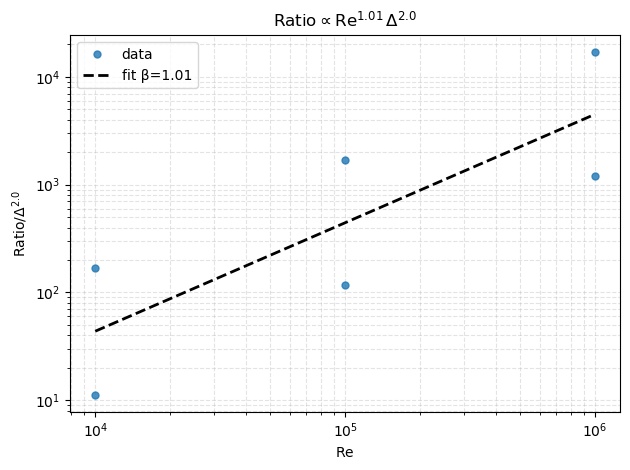

In [7]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH  = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"  # fallback if C missing
SAVE_FIG = False
FIG_PATH = "out_ratios_enstrophy/re_scaling_from_raw.png"
DELTA_EXPONENT = 2.0       # α found from previous Δ-fit
# ===================

# ---------- load ----------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

# clean and numeric columns
df["nu"] = df["nu"].astype(float)
df["Re"] = 1.0 / df["nu"]
df["Delta"] = df["Delta"].astype(float)
df["Ratio_signed"] = df["Ratio_signed"].astype(float)

# remove bad values
df = df[np.isfinite(df["Ratio_signed"]) & (df["Ratio_signed"] > 0)]
df = df[np.isfinite(df["Re"]) & (df["Re"] > 0)]
df = df[np.isfinite(df["Delta"]) & (df["Delta"] > 0)]

# ---------- normalize by Δ^α ----------
df["y_norm"] = df["Ratio_signed"] / (df["Delta"] ** DELTA_EXPONENT)

# ---------- group average per Re (optional smoothing) ----------
# We can average over all Deltas per Re (since Δ scaling is factored out)
df_re = df.groupby(["family", "dataset", "Re"], as_index=False)["y_norm"].median()

# ---------- fit log–log scaling: y_norm ∝ Re^β ----------
x = df_re["Re"].to_numpy()
y = df_re["y_norm"].to_numpy()

lx = np.log10(x)
ly = np.log10(y)
A = np.vstack([lx, np.ones_like(lx)]).T
coef, res, *_ = np.linalg.lstsq(A, ly, rcond=None)
beta, intercept = coef
R2 = 1 - res / np.sum((ly - ly.mean())**2)
A0 = 10**intercept

print(f"\nFit result:  y_norm ∝ Re^{beta:.3f}  (R² = {float(R2):.4f})")
print(f"→ Total scaling:  Ratio ∝ Re^{beta:.3f} * Δ^{DELTA_EXPONENT:.1f}")

# ---------- plot ----------
plt.figure(figsize=(6.4,4.8))
plt.loglog(x, y, 'o', ms=5, alpha=0.8, label="data")
xfit = np.geomspace(x.min(), x.max(), 100)
plt.loglog(xfit, A0 * xfit**beta, '--k', lw=2, label=f"fit β={beta:.2f}")
plt.xlabel(r"$\mathrm{Re}$")
plt.ylabel(r"$\mathrm{Ratio}/\Delta^{%.1f}$" % DELTA_EXPONENT)
plt.title(r"$\mathrm{Ratio} \propto \mathrm{Re}^{%.2f}\,\Delta^{%.1f}$" % (beta, DELTA_EXPONENT))
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend()
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
    plt.savefig(FIG_PATH, dpi=200)
    print("Saved:", FIG_PATH)

plt.show()

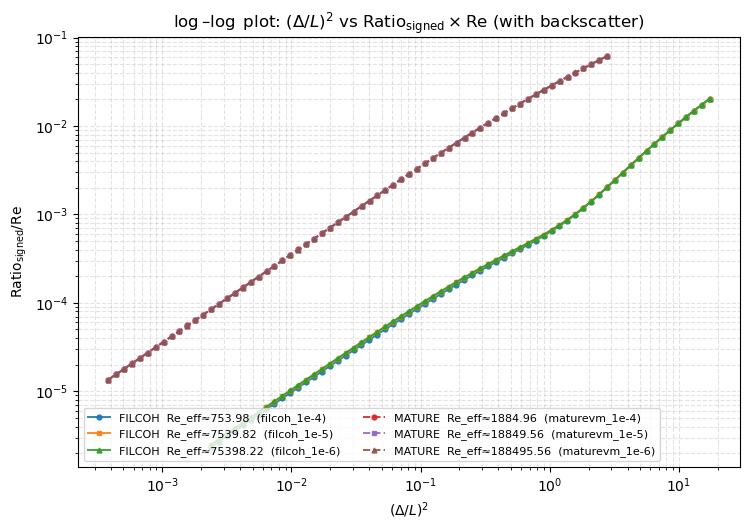

In [71]:
#!/usr/bin/env python3
# Plot: log–log (Delta/L)^2 (x) vs (Ratio_signed * Re_eff) (y),
# with L chosen per family:
#   - L = 2π/10 for "mature" datasets
#   - L = 2π/25 for "filcoh" datasets
# and Re_eff = 0.3 * L / nu

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"
SAVE_FIG = False
FIG_PATH = "out_ratios_enstrophy/plot_scaled_delta2_vs_ratio_times_Re.png"
# =====================

# ---------- load ----------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

# Ensure numeric dtypes
for col in ["nu", "Delta", "Ratio_signed"]:
    df[col] = df[col].astype(float)

# ---------- assign L per family ----------
def infer_L_from_family(family_str: str) -> float:
    """Return L based on family name (case-insensitive)."""
    f = str(family_str).lower()
    two_pi = 2.0 * np.pi
    if "mature" in f:
        return two_pi / 10.0
    if "filcoh" in f:
        return two_pi / 25.0
    # Fallback: raise with a helpful message so we don't silently mis-scale.
    raise ValueError(
        f"Unrecognized family '{family_str}'. "
        "Expected something containing 'mature' or 'filcoh' (case-insensitive)."
    )

if "family" not in df.columns:
    raise KeyError("CSV must contain a 'family' column to assign L values.")

df["L"] = df["family"].apply(infer_L_from_family)

# ---------- compute scaled axes ----------
# Re_eff = 0.3 * L / nu  (per-row because L depends on family)
df["Re_eff"] = 0.3 * df["L"] / df["nu"]

# x = (Delta/L)^2, y = Ratio_signed * Re_eff
df["x_scaled"] = (df["Delta"] / df["L"]) ** 2
df["y_scaled"] = df["Ratio_signed"] / df["Re_eff"]

# ---------- plot ----------
plt.figure(figsize=(7.6, 5.4))
plt.xscale("log")
plt.yscale("log")

families = sorted(df["family"].unique(), key=lambda s: str(s).lower())
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for fi, fam in enumerate(families):
    sub_f = df[df["family"] == fam].copy()

    # Group by the actual effective Re (depends on nu and L); keep numeric grouping
    # Use rounded string in the legend for readability.
    for ri, (Re_val, grp) in enumerate(sub_f.groupby("Re_eff")):
        grp = grp.sort_values("x_scaled")
        label = f"{fam}  Re_eff≈{Re_val:.2f}  ({grp['dataset'].iloc[0]})" if "dataset" in grp.columns else f"{fam}  Re_eff≈{Re_val:.2f}"

        plt.plot(
            grp["x_scaled"].to_numpy(),
            grp["y_scaled"].to_numpy(),
            linestyle=linestyles[fi % len(linestyles)],
            marker=markers[ri % len(markers)],
            ms=3.5,
            lw=1.4,
            alpha=0.9,
            label=label,
        )

plt.xlabel(r"$\left(\Delta/L\right)^2$")
plt.ylabel(r"$\mathrm{Ratio}_{\text{signed}} / \mathrm{Re}$")
plt.title(r"$\log$–$\log$ plot: $(\Delta/L)^2$ vs $\mathrm{Ratio}_{\text{signed}}\times \mathrm{Re}$ (with backscatter)")
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
    plt.savefig(FIG_PATH, dpi=200)
    print("Saved figure to:", FIG_PATH)

plt.show()

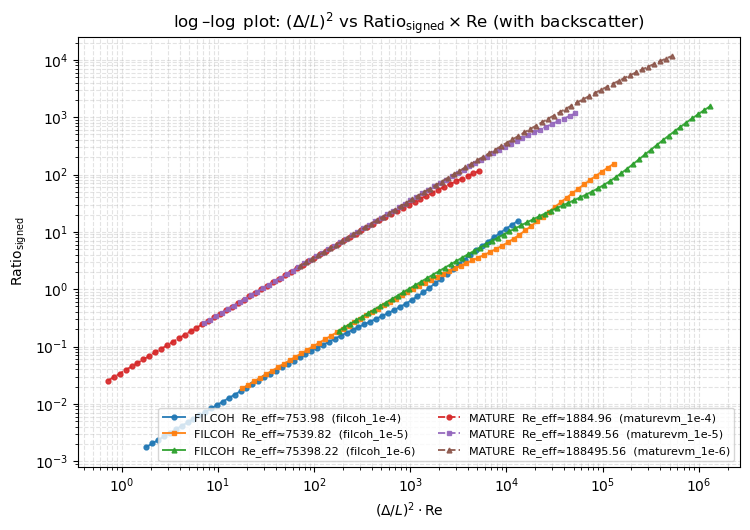

In [70]:
#!/usr/bin/env python3
# Plot: log–log (Delta/L)^2 (x) vs (Ratio_signed * Re_eff) (y),
# with L chosen per family:
#   - L = 2π/10 for "mature" datasets
#   - L = 2π/25 for "filcoh" datasets
# and Re_eff = 0.3 * L / nu

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"
SAVE_FIG = False
FIG_PATH = "out_ratios_enstrophy/plot_scaled_delta2_vs_ratio_times_Re.png"
# =====================

# ---------- load ----------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

# Ensure numeric dtypes
for col in ["nu", "Delta", "Ratio_signed"]:
    df[col] = df[col].astype(float)

# ---------- assign L per family ----------
def infer_L_from_family(family_str: str) -> float:
    """Return L based on family name (case-insensitive)."""
    f = str(family_str).lower()
    two_pi = 2.0 * np.pi
    if "mature" in f:
        return two_pi / 10.0
    if "filcoh" in f:
        return two_pi / 25.0
    # Fallback: raise with a helpful message so we don't silently mis-scale.
    raise ValueError(
        f"Unrecognized family '{family_str}'. "
        "Expected something containing 'mature' or 'filcoh' (case-insensitive)."
    )

if "family" not in df.columns:
    raise KeyError("CSV must contain a 'family' column to assign L values.")

df["L"] = df["family"].apply(infer_L_from_family)

# ---------- compute scaled axes ----------
# Re_eff = 0.3 * L / nu  (per-row because L depends on family)
df["Re_eff"] = 0.3 * df["L"] / df["nu"]

# x = (Delta/L)^2, y = Ratio_signed * Re_eff
df["x_scaled"] = (df["Delta"] / df["L"]) ** 2 * df["Re_eff"]
df["y_scaled"] = df["Ratio_signed"] 

# ---------- plot ----------
plt.figure(figsize=(7.6, 5.4))
plt.xscale("log")
plt.yscale("log")

families = sorted(df["family"].unique(), key=lambda s: str(s).lower())
markers = ["o", "s", "^", "D", "v", "P", "X", "*"]
linestyles = ["-", "--", "-.", ":"]

for fi, fam in enumerate(families):
    sub_f = df[df["family"] == fam].copy()

    # Group by the actual effective Re (depends on nu and L); keep numeric grouping
    # Use rounded string in the legend for readability.
    for ri, (Re_val, grp) in enumerate(sub_f.groupby("Re_eff")):
        grp = grp.sort_values("x_scaled")
        label = f"{fam}  Re_eff≈{Re_val:.2f}  ({grp['dataset'].iloc[0]})" if "dataset" in grp.columns else f"{fam}  Re_eff≈{Re_val:.2f}"

        plt.plot(
            grp["x_scaled"].to_numpy(),
            grp["y_scaled"].to_numpy(),
            linestyle=linestyles[fi % len(linestyles)],
            marker=markers[ri % len(markers)],
            ms=3.5,
            lw=1.4,
            alpha=0.9,
            label=label,
        )

plt.xlabel(r"$\left(\Delta/L\right)^2\cdot \mathrm{Re}$")
plt.ylabel(r"$\mathrm{Ratio}_{\text{signed}}$")
plt.title(r"$\log$–$\log$ plot: $(\Delta/L)^2$ vs $\mathrm{Ratio}_{\text{signed}}\times \mathrm{Re}$ (with backscatter)")
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
    plt.savefig(FIG_PATH, dpi=200)
    print("Saved figure to:", FIG_PATH)

plt.show()

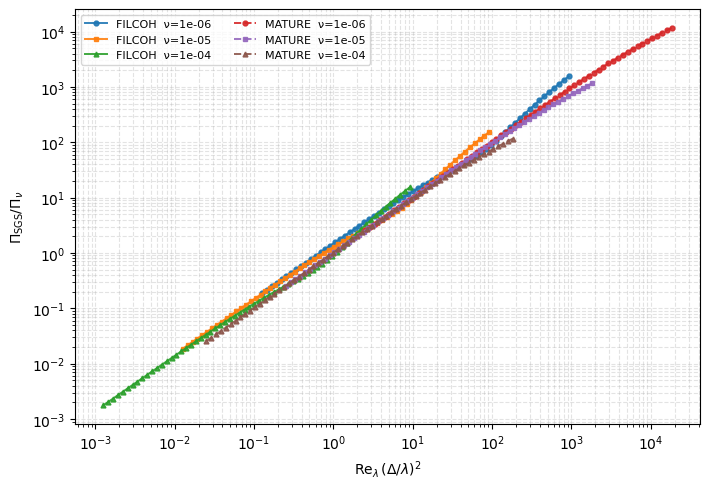

In [63]:
# Characteristic length scales (your chosen λ per family)
LF = 357.132   # FILCOH
LM = 18.0      # MATURE

# ---- load ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)

# numerics
for c in ["nu","Delta","Ratio_signed"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# valid rows
df = df.dropna(subset=["family","nu","Delta","Ratio_signed"])
df = df[(df["Ratio_signed"] > 0) & (df["Delta"] > 0)]

# assign λ per family
df["lambda"] = np.where(df["family"] == "FILCOH", LF, LM)

# pick a u_rms (constant 0.3 here; or map per-family if you prefer)
URMS = 0.3
# Re_λ = u_rms * λ / ν
df["Re_lambda"] = URMS * df["lambda"] / df["nu"]

# x = Re_λ * (Δ/λ)^2
df["X"] = df["Re_lambda"] * (df["Delta"] / df["lambda"])**2
df["Y"] = df["Ratio_signed"]

# ---- plot, grouped by ν (not Re) ----
plt.figure(figsize=(7.2, 5.0))
markers = ["o","s","^","D","v","P","X","*"]
linestyles = ["-","--","-.",":"]

for fi, fam in enumerate(sorted(df["family"].unique())):
    sub = df[df["family"] == fam]
    for ri, (nu_val, grp) in enumerate(sub.groupby("nu")):
        grp = grp.sort_values("X")
        label = f"{fam}  ν={nu_val:.0e}"
        plt.loglog(
            grp["X"], grp["Y"],
            linestyle=linestyles[fi % len(linestyles)],
            marker=markers[ri % len(markers)],
            ms=3.5, lw=1.4, alpha=0.9, label=label
        )

plt.xlabel(r"$\mathrm{Re}_\lambda\,(\Delta/\lambda)^2$")
plt.ylabel(r"$\Pi_{\rm SGS}/\Pi_{\nu}$")
plt.title("")
plt.grid(True, which="both", ls="--", alpha=0.35)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

if SAVE_FIG:
    os.makedirs(os.path.dirname(FIG_PATH), exist_ok=True)
    plt.savefig(FIG_PATH, dpi=200)
    print("Saved figure to:", FIG_PATH)

plt.show()

In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Check Δ-local gradients on ONE dataset:
- <S^2>(Δ) ~ Δ^{-2}?
- <|∇^2 ū|^2>(Δ) ~ Δ^{-4}?
- L_eff^(1), L_eff^(2) ∝ Δ ?
"""

import os, re, h5py
import numpy as np
import matplotlib.pyplot as plt

# ====== CONFIG ======
MAT_PATH = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"   # pick one
Lx = Ly = 2.0*np.pi
MAX_T = 5
NUM_DELTAS = 32
DELTAS = np.geomspace(2*np.pi/512, 2*np.pi/6, NUM_DELTAS)
# ====================

# ---------- I/O ----------
def parse_nu_from_filename(path: str) -> float:
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m: raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def load_variable_from_mat(mat_file_path, variable_name):
    with h5py.File(mat_file_path, 'r') as f:
        if variable_name in f:
            return np.array(f[variable_name])
        raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")

def load_velocity_uv(path: str, max_t: int | None = MAX_T) -> np.ndarray:
    s = load_variable_from_mat(path, "s")
    if s.ndim != 4: raise ValueError(f"Unsupported 's' shape: {s.shape}")
    if s.shape[1] == 2:    # (T,2,Nx,Ny)
        T, _, Nx, Ny = s.shape
        U = s[:max_t,1,:,:] if max_t else s[:,1,:,:]
        V = s[:max_t,0,:,:] if max_t else s[:,0,:,:]
        U = np.transpose(U, (1,2,0))
        V = np.transpose(V, (1,2,0))
    elif s.shape[0] == 2:  # (2,Nx,Ny,T)
        _, Nx, Ny, T = s.shape
        U = s[1,...,:max_t] if max_t else s[1,...]
        V = s[0,...,:max_t] if max_t else s[0,...]
    else:
        raise ValueError(f"Unrecognized 's' layout: {s.shape}")
    return np.stack([U, V], axis=2).astype(np.float64)  # (Nx,Ny,2,T)

# ---------- spectral tools ----------
def kgrid(N, L):   return (2*np.pi/L) * np.fft.fftfreq(N, d=L/N)
def rfftkgrid(N, L): return (2*np.pi/L) * np.fft.rfftfreq(N, d=L/N)

def gaussian_filter_fft(field, Delta, Lx, Ly):
    Nx, Ny = field.shape
    kx = kgrid(Nx, Lx); ky = rfftkgrid(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    G = np.exp(-(KX*KX + KY*KY) * (Delta**2)/24.0)
    F = np.fft.rfft2(field)
    return np.fft.irfft2(F * G, s=(Nx, Ny))

def filtered_gradients(ux_f, uy_f, Lx, Ly):
    Nx, Ny = ux_f.shape
    kx = kgrid(Nx, Lx); ky = rfftkgrid(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    iKX, iKY = 1j*KX, 1j*KY
    Ux = np.fft.rfft2(ux_f); Uy = np.fft.rfft2(uy_f)
    ux_x = np.fft.irfft2(iKX*Ux, s=(Nx, Ny)).real
    ux_y = np.fft.irfft2(iKY*Ux, s=(Nx, Ny)).real
    uy_x = np.fft.irfft2(iKX*Uy, s=(Nx, Ny)).real
    uy_y = np.fft.irfft2(iKY*Uy, s=(Nx, Ny)).real
    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5*(ux_y + uy_x)
    return Sxx, Sxy, Syy

def laplacian(field, Lx, Ly):
    Nx, Ny = field.shape
    kx = kgrid(Nx, Lx); ky = rfftkgrid(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    F = np.fft.rfft2(field)
    return np.fft.irfft2(-(KX*KX + KY*KY)*F, s=(Nx, Ny)).real

# ---------- load one dataset ----------
u = load_velocity_uv(MAT_PATH, MAX_T)
Nx, Ny, _, T = u.shape
print(f"Loaded {MAT_PATH}  shape={u.shape}")

# ---------- sweep Δ and measure scalings ----------
S2_list = []
grad_u2_list = []
lap_u2_list = []
Leff1_list = []
Leff2_list = []

for Delta in DELTAS:
    S2_t, grad_u2_t, lap_u2_t, Leff1_t, Leff2_t = [], [], [], [], []
    for t in range(T):
        ux, uy = u[:,:,0,t], u[:,:,1,t]
        uxf = gaussian_filter_fft(ux, Delta, Lx, Ly)
        uyf = gaussian_filter_fft(uy, Delta, Lx, Ly)

        # strain
        Sxx, Sxy, Syy = filtered_gradients(uxf, uyf, Lx, Ly)
        S2_t.append(np.mean(Sxx**2 + 2*Sxy**2 + Syy**2))

        # gradient magnitude
        Nx_, Ny_ = uxf.shape
        kx = kgrid(Nx_, Lx); ky = rfftkgrid(Ny_, Ly)
        KX, KY = np.meshgrid(kx, ky, indexing="ij")
        iKX, iKY = 1j*KX, 1j*KY
        Ux_hat, Uy_hat = np.fft.rfft2(uxf), np.fft.rfft2(uyf)
        uxf_x = np.fft.irfft2(iKX*Ux_hat, s=(Nx_, Ny_)).real
        uxf_y = np.fft.irfft2(iKY*Ux_hat, s=(Nx_, Ny_)).real
        uyf_x = np.fft.irfft2(iKX*Uy_hat, s=(Nx_, Ny_)).real
        uyf_y = np.fft.irfft2(iKY*Uy_hat, s=(Nx_, Ny_)).real
        grad_u2 = np.mean(uxf_x**2 + uxf_y**2 + uyf_x**2 + uyf_y**2)
        grad_u2_t.append(grad_u2)

        # Laplacian
        lap_ux = laplacian(uxf, Lx, Ly)
        lap_uy = laplacian(uyf, Lx, Ly)
        lap_u2 = np.mean(lap_ux**2 + lap_uy**2)
        lap_u2_t.append(lap_u2)

        # effective length scales
        u2 = np.mean(uxf**2 + uyf**2)
        Leff1_t.append(np.sqrt(u2 / (grad_u2 + 1e-30)))
        Leff2_t.append(np.sqrt((grad_u2 + 1e-30) / (lap_u2 + 1e-30)))

    S2_list.append(np.mean(S2_t))
    grad_u2_list.append(np.mean(grad_u2_t))
    lap_u2_list.append(np.mean(lap_u2_t))
    Leff1_list.append(np.mean(Leff1_t))
    Leff2_list.append(np.mean(Leff2_t))

# ---------- convert lists ----------
S2_arr  = np.asarray(S2_list)
G2_arr  = np.asarray(grad_u2_list)
L2_arr  = np.asarray(lap_u2_list)
Le1_arr = np.asarray(Leff1_list)
Le2_arr = np.asarray(Leff2_list)

# ---------- fit slopes ----------
def fit_slope(x, y, label):
    msk = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    m, b = np.polyfit(np.log10(x[msk]), np.log10(y[msk]), 1)
    print(f"{label}: slope = {m:.3f}")
    return m

m_S2 = fit_slope(DELTAS, S2_arr, "<S^2>(Δ)")
m_G2 = fit_slope(DELTAS, G2_arr, "<|∇ū|^2>(Δ)")
m_L2 = fit_slope(DELTAS, L2_arr, "<|∇^2 ū|^2>(Δ)")

# ---------- plots ----------
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.loglog(DELTAS, S2_arr, 'o-')
plt.title(f"<S^2> vs Δ  (slope≈{m_S2:.2f})")
plt.xlabel("Δ"); plt.ylabel("<S^2>"); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.subplot(1,3,2)
plt.loglog(DELTAS, G2_arr, 'o-')
plt.title(f"<|∇ū|^2> vs Δ  (slope≈{m_G2:.2f})")
plt.xlabel("Δ"); plt.ylabel("<|∇ū|^2>"); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.subplot(1,3,3)
plt.loglog(DELTAS, L2_arr, 'o-')
plt.title(f"<|∇^2 ū|^2> vs Δ  (slope≈{m_L2:.2f})")
plt.xlabel("Δ"); plt.ylabel("<|∇^2 ū|^2>"); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ---------- L_eff / Δ ~ const? ----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.loglog(DELTAS, Le1_arr/DELTAS, 'o-')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.title("L_eff^(1) / Δ")
plt.xlabel("Δ"); plt.ylabel("L_eff^(1)/Δ"); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.subplot(1,2,2)
plt.loglog(DELTAS, Le2_arr/DELTAS, 'o-')
plt.axhline(1.0, color='k', lw=1, alpha=0.5)
plt.title("L_eff^(2) / Δ")
plt.xlabel("Δ"); plt.ylabel("L_eff^(2)/Δ"); plt.grid(True, which='both', ls='--', alpha=0.5)

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
JAX version of Δ-local gradient scaling test:
- ⟨S²⟩(Δ) ~ Δ^{-2} ?
- ⟨|∇²ū|²⟩(Δ) ~ Δ^{-4} ?
- L_eff^(1), L_eff^(2) ∝ Δ ?
"""

import re, os, h5py, jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# ========== CONFIG ==========
MAT_PATH = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"
Lx = Ly = 2*jnp.pi
MAX_T = 5
NUM_DELTAS = 32
DELTAS = jnp.geomspace(2*jnp.pi/512, 2*jnp.pi/6, NUM_DELTAS)
# ============================

# ---------- helpers ----------
def parse_nu_from_filename(path: str):
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m:
        raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def load_velocity_uv(path: str, max_t: int | None = MAX_T):
    with h5py.File(path, 'r') as f:
        s = jnp.array(f["s"])
    if s.ndim != 4:
        raise ValueError(f"Unsupported 's' shape: {s.shape}")
    if s.shape[1] == 2:      # (T,2,Nx,Ny)
        T, _, Nx, Ny = s.shape
        U = s[:max_t,1,:,:] if max_t else s[:,1,:,:]
        V = s[:max_t,0,:,:] if max_t else s[:,0,:,:]
        U = jnp.transpose(U, (1,2,0))
        V = jnp.transpose(V, (1,2,0))
    elif s.shape[0] == 2:    # (2,Nx,Ny,T)
        _, Nx, Ny, T = s.shape
        U = s[1,...,:max_t] if max_t else s[1,...]
        V = s[0,...,:max_t] if max_t else s[0,...]
    else:
        raise ValueError(f"Unrecognized 's' layout: {s.shape}")
    return jnp.stack([U, V], axis=2)  # (Nx,Ny,2,T)

# ---------- spectral operators ----------
def rfft_mesh_2d(Nx, Ny, Lx, Ly):
    kx = jnp.fft.fftfreq(Nx, d=Lx/Nx) * 2*jnp.pi
    ky = jnp.fft.rfftfreq(Ny, d=Ly/Ny) * 2*jnp.pi
    return jnp.meshgrid(kx, ky, indexing="ij")

def gaussian_filter_fft(field, Delta, Lx, Ly):
    Nx, Ny = field.shape
    kx, ky = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    G = jnp.exp(-(kx**2 + ky**2) * (Delta**2)/24.0)
    return jnp.fft.irfft2(jnp.fft.rfft2(field) * G, s=(Nx, Ny))

def filtered_gradients(ux_f, uy_f, Lx, Ly):
    Nx, Ny = ux_f.shape
    kx, ky = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    i = 1j
    Ux, Uy = jnp.fft.rfft2(ux_f), jnp.fft.rfft2(uy_f)
    ux_x = jnp.fft.irfft2(i*kx*Ux, s=(Nx, Ny))
    ux_y = jnp.fft.irfft2(i*ky*Ux, s=(Nx, Ny))
    uy_x = jnp.fft.irfft2(i*kx*Uy, s=(Nx, Ny))
    uy_y = jnp.fft.irfft2(i*ky*Uy, s=(Nx, Ny))
    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5*(ux_y + uy_x)
    return Sxx.real, Sxy.real, Syy.real

def laplacian(field, Lx, Ly):
    Nx, Ny = field.shape
    kx, ky = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    F = jnp.fft.rfft2(field)
    return jnp.fft.irfft2(-(kx**2 + ky**2)*F, s=(Nx, Ny)).real

# ---------- main ----------
u = load_velocity_uv(MAT_PATH, MAX_T)
Nx, Ny, _, T = u.shape
print(f"Loaded {MAT_PATH} shape={u.shape}")

S2_list, G2_list, L2_list, Le1_list, Le2_list = [], [], [], [], []

for Delta in DELTAS:
    S2_t, G2_t, L2_t, Le1_t, Le2_t = [], [], [], [], []
    for t in range(T):
        ux, uy = u[:,:,0,t], u[:,:,1,t]
        uxf = gaussian_filter_fft(ux, Delta, Lx, Ly)
        uyf = gaussian_filter_fft(uy, Delta, Lx, Ly)

        # strain
        Sxx, Sxy, Syy = filtered_gradients(uxf, uyf, Lx, Ly)
        S2_t.append(jnp.mean(Sxx**2 + 2*Sxy**2 + Syy**2))

        # ∇ū
        Nx_, Ny_ = uxf.shape
        kx, ky = rfft_mesh_2d(Nx_, Ny_, Lx, Ly)
        i = 1j
        Ux, Uy = jnp.fft.rfft2(uxf), jnp.fft.rfft2(uyf)
        uxf_x = jnp.fft.irfft2(i*kx*Ux, s=(Nx_, Ny_))
        uxf_y = jnp.fft.irfft2(i*ky*Ux, s=(Nx_, Ny_))
        uyf_x = jnp.fft.irfft2(i*kx*Uy, s=(Nx_, Ny_))
        uyf_y = jnp.fft.irfft2(i*ky*Uy, s=(Nx_, Ny_))
        grad_u2 = jnp.mean(uxf_x**2 + uxf_y**2 + uyf_x**2 + uyf_y**2)
        G2_t.append(grad_u2)

        # ∇²ū
        lap_ux = laplacian(uxf, Lx, Ly)
        lap_uy = laplacian(uyf, Lx, Ly)
        L2_t.append(jnp.mean(lap_ux**2 + lap_uy**2))

        # effective lengths
        u2 = jnp.mean(uxf**2 + uyf**2)
        Le1_t.append(jnp.sqrt(u2 / (grad_u2 + 1e-30)))
        Le2_t.append(jnp.sqrt((grad_u2 + 1e-30) / (L2_t[-1] + 1e-30)))

    S2_list.append(jnp.mean(jnp.stack(S2_t)))
    G2_list.append(jnp.mean(jnp.stack(G2_t)))
    L2_list.append(jnp.mean(jnp.stack(L2_t)))
    Le1_list.append(jnp.mean(jnp.stack(Le1_t)))
    Le2_list.append(jnp.mean(jnp.stack(Le2_t)))

# ---------- convert ----------
S2_arr, G2_arr, L2_arr = jnp.array(S2_list), jnp.array(G2_list), jnp.array(L2_list)
Le1_arr, Le2_arr = jnp.array(Le1_list), jnp.array(Le2_list)

# ---------- fit slopes ----------
def fit_slope(x, y, label):
    x, y = jnp.log10(x), jnp.log10(y)
    A = jnp.vstack([x, jnp.ones_like(x)]).T
    m, b = jnp.linalg.lstsq(A, y, rcond=None)[0]
    print(f"{label}: slope = {m:.3f}")
    return float(m)

m_S2 = fit_slope(DELTAS, S2_arr, "<S²>(Δ)")
m_G2 = fit_slope(DELTAS, G2_arr, "<|∇ū|²>(Δ)")
m_L2 = fit_slope(DELTAS, L2_arr, "<|∇²ū|²>(Δ)")

# ---------- plots ----------
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.loglog(DELTAS, S2_arr, 'o-'); plt.title(f"<S²> vs Δ (slope≈{m_S2:.2f})")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.subplot(1,3,2)
plt.loglog(DELTAS, G2_arr, 'o-'); plt.title(f"<|∇ū|²> vs Δ (slope≈{m_G2:.2f})")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.subplot(1,3,3)
plt.loglog(DELTAS, L2_arr, 'o-'); plt.title(f"<|∇²ū|²> vs Δ (slope≈{m_L2:.2f})")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()

# ---------- L_eff / Δ ----------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.loglog(DELTAS, Le1_arr/DELTAS, 'o-'); plt.axhline(1, color='k', lw=1)
plt.title("L_eff^(1)/Δ"); plt.grid(True, which="both", ls="--", alpha=0.5)
plt.subplot(1,2,2)
plt.loglog(DELTAS, Le2_arr/DELTAS, 'o-'); plt.axhline(1, color='k', lw=1)
plt.title("L_eff^(2)/Δ"); plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout(); plt.show()


Loaded /storage/scratch1/1/bchoi73/maturevm_1e-5.mat shape=(2048, 2048, 2, 5)
Q(Δ)=S_rms Δ / U_rms: log–log slope ≈ 0.928 (≈0 means flat)
Mean Q (≈ C_G): 0.403 ± 0.409


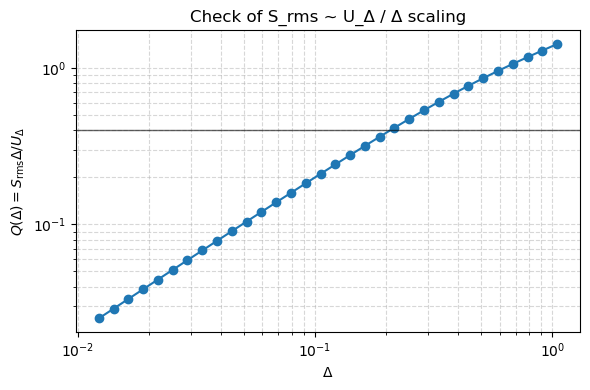

In [42]:
import jax, jax.numpy as jnp
import numpy as np

# --- you already have these from earlier scripts ---
# rfft_mesh_2d, gaussian_filter_fft, filtered_gradients
# load_velocity_uv(MAT_PATH, MAX_T)

def S_rms_from_filtered(ux_f, uy_f, Lx, Ly):
    Sxx, Sxy, Syy = filtered_gradients(ux_f, uy_f, Lx, Ly)
    S2 = Sxx*Sxx + 2.0*Sxy*Sxy + Syy*Syy
    return jnp.sqrt(jnp.mean(S2))

def U_rms_from_filtered(ux_f, uy_f):
    return jnp.sqrt(jnp.mean(ux_f*ux_f + uy_f*uy_f))

def check_S_vs_U_over_Delta(u, Deltas, Lx, Ly):
    """
    u: (Nx,Ny,2,T) unfiltered DNS
    Returns arrays of: Delta, Q(Delta) = S_rms*Delta / U_rms
    """
    Nx, Ny, _, T = u.shape
    Qs = []
    for Delta in np.asarray(Deltas):
        Delta = float(Delta)
        S_vals, U_vals = [], []
        for t in range(int(T)):
            ux = u[:,:,0,t]; uy = u[:,:,1,t]
            ux_f = gaussian_filter_fft(ux, Delta, Lx, Ly)
            uy_f = gaussian_filter_fft(uy, Delta, Lx, Ly)
            S_rms = S_rms_from_filtered(ux_f, uy_f, Lx, Ly)
            U_rms = U_rms_from_filtered(ux_f, uy_f)
            S_vals.append(S_rms); U_vals.append(U_rms)
        S_mean = jnp.mean(jnp.stack(S_vals))
        U_mean = jnp.mean(jnp.stack(U_vals))
        Qs.append( (S_mean * Delta) / (U_mean + 1e-30) )
    D = jnp.asarray(Deltas)
    Q = jnp.asarray(Qs)
    # log–log slope of Q vs Delta
    xm, ym = jnp.log(D), jnp.log(Q)
    A = jnp.vstack([xm, jnp.ones_like(xm)]).T
    slope, intercept = jnp.linalg.lstsq(A, ym, rcond=None)[0]
    print(f"Q(Δ)=S_rms Δ / U_rms: log–log slope ≈ {float(slope):.3f} (≈0 means flat)")
    print(f"Mean Q (≈ C_G): {float(jnp.mean(Q)):.3f} ± {float(jnp.std(Q)):.3f}")
    return D, Q

# Example usage
MAT_PATH = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"
Lx = Ly = 2 * jnp.pi
MAX_T = 5
Deltas = jnp.geomspace(2*jnp.pi/512, 2*jnp.pi/6, 32)

# --- load one dataset ---
u = load_velocity_uv(MAT_PATH, MAX_T)
print(f"Loaded {MAT_PATH} shape={u.shape}")

# --- run test ---
D, Q = check_S_vs_U_over_Delta(u, Deltas, Lx, Ly)

# --- plot result ---
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.loglog(D, Q, "o-")
plt.axhline(jnp.mean(Q), color="k", lw=1, alpha=0.6)
plt.xlabel(r"$\Delta$")
plt.ylabel(r"$Q(\Delta)=S_{\rm rms}\Delta/U_\Delta$")
plt.title("Check of S_rms ~ U_Δ / Δ scaling")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

Loaded /storage/scratch1/1/bchoi73/maturevm_1e-5.mat  shape=(2048, 2048, 2, 5)
k_rms(Δ): slope = -0.075
C(Δ)=Δ·k_rms(Δ): slope = 0.925
U_Δ(Δ): slope = -0.021
sqrt(<|∇ū|^2>)(Δ): slope = -0.096

Expectations for Δ-local regime: slope(k_rms) ≈ -1, slope(C) ≈ 0.
Summary: slope(k_rms)=-0.075, slope(Δ·k_rms)=0.925, slope(U_Δ)=-0.021, slope(sqrt(<|∇ū|^2>))=-0.096


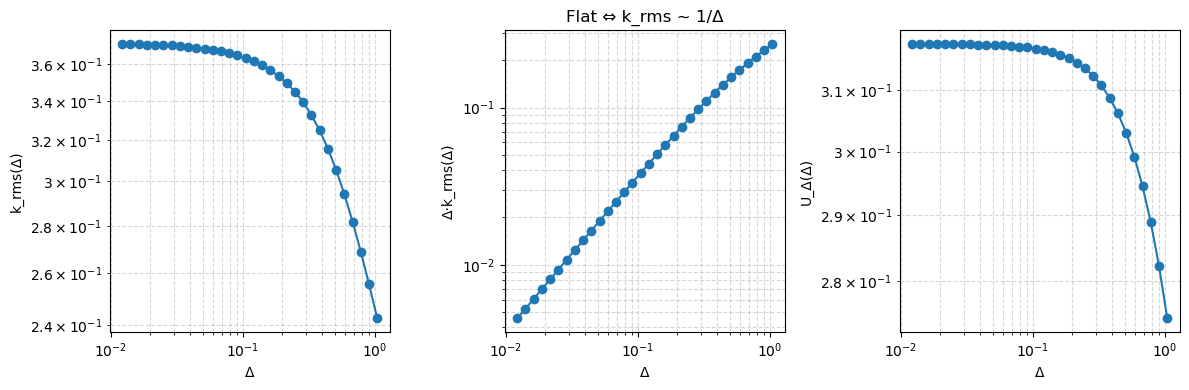

In [44]:
import jax, jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

# Expect these to already exist in your session:
# - load_velocity_uv(path, max_t)
# - gaussian_filter_fft(field, Delta, Lx, Ly)
# - filtered_gradients(ux_f, uy_f, Lx, Ly)
# If you don't have a "grad energy" helper yet, we compute it explicitly below.

def grad_energy_from_filtered(ux_f: jnp.ndarray, uy_f: jnp.ndarray, Lx: float, Ly: float) -> float:
    """Return <|∇ū|^2> = <ux_x^2 + ux_y^2 + uy_x^2 + uy_y^2>."""
    Nx, Ny = ux_f.shape
    # spectral wavenumbers
    kx = (2*jnp.pi/Lx) * jnp.fft.fftfreq(Nx, d=Lx/Nx)
    ky = (2*jnp.pi/Ly) * jnp.fft.rfftfreq(Ny, d=Ly/Ny)
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')
    iKX, iKY = 1j*KX, 1j*KY

    Ux_hat = jnp.fft.rfft2(ux_f)
    Uy_hat = jnp.fft.rfft2(uy_f)

    ux_x = jnp.fft.irfft2(iKX * Ux_hat, s=(Nx, Ny)).real
    ux_y = jnp.fft.irfft2(iKY * Ux_hat, s=(Nx, Ny)).real
    uy_x = jnp.fft.irfft2(iKX * Uy_hat, s=(Nx, Ny)).real
    uy_y = jnp.fft.irfft2(iKY * Uy_hat, s=(Nx, Ny)).real

    grad_u2 = jnp.mean(ux_x*ux_x + ux_y*ux_y + uy_x*uy_x + uy_y*uy_y)
    return float(grad_u2)

def energy_from_filtered(ux_f: jnp.ndarray, uy_f: jnp.ndarray) -> float:
    """Return <|ū|^2> = <ux_f^2 + uy_f^2>."""
    return float(jnp.mean(ux_f*ux_f + uy_f*uy_f))

def fit_loglog(x: np.ndarray, y: np.ndarray, label: str):
    """Return slope and intercept of log(y)=m log(x)+b."""
    xm = np.log(x); ym = np.log(y)
    A = np.vstack([xm, np.ones_like(xm)]).T
    m, b = np.linalg.lstsq(A, ym, rcond=None)[0]
    print(f"{label}: slope = {m:.3f}")
    return float(m), float(b)

def measure_k_rms_vs_Delta(MAT_PATH: str,
                           Deltas: np.ndarray,
                           Lx: float = 2*np.pi,
                           Ly: float = 2*np.pi,
                           MAX_T: int | None = 5):
    # load one dataset
    u = load_velocity_uv(MAT_PATH, MAX_T)     # (Nx,Ny,2,T)
    Nx, Ny, _, T = u.shape
    print(f"Loaded {MAT_PATH}  shape={u.shape}")

    k_rms_list = []
    C_list = []     # C(Δ) = Δ * k_rms(Δ)
    U_list = []     # optional: U_Δ(Δ)
    G_list = []     # optional: <|∇ū|^2>(Δ)

    for Delta in np.asarray(Deltas, dtype=float):
        grad_u2_t = []
        u2_t = []
        for t in range(int(T)):
            ux = u[:, :, 0, t]
            uy = u[:, :, 1, t]
            ux_f = gaussian_filter_fft(ux, Delta, Lx, Ly)
            uy_f = gaussian_filter_fft(uy, Delta, Lx, Ly)

            u2   = energy_from_filtered(ux_f, uy_f)
            g2   = grad_energy_from_filtered(ux_f, uy_f, Lx, Ly)

            u2_t.append(u2)
            grad_u2_t.append(g2)

        u2_mean = float(np.mean(u2_t))
        g2_mean = float(np.mean(grad_u2_t))

        k_rms = np.sqrt(max(g2_mean, 0.0) / (u2_mean + 1e-300))
        k_rms_list.append(k_rms)
        C_list.append(Delta * k_rms)
        U_list.append(np.sqrt(max(u2_mean, 0.0)))
        G_list.append(g2_mean)

    D = np.asarray(Deltas, dtype=float)
    k_rms_arr = np.asarray(k_rms_list)
    C_arr     = np.asarray(C_list)
    U_arr     = np.asarray(U_list)
    G_arr     = np.asarray(G_list)

    # fits
    m_k, _ = fit_loglog(D, k_rms_arr, "k_rms(Δ)")
    m_C,  _ = fit_loglog(D, C_arr,     "C(Δ)=Δ·k_rms(Δ)")
    m_U,  _ = fit_loglog(D, U_arr,     "U_Δ(Δ)")
    # sanity: since k_rms = S_rms / U_Δ and S_rms^2 ~ (1/2)<|∇ū|^2| + ...>,
    # you can also check slope of sqrt(G) vs Δ:
    m_sqrtG, _ = fit_loglog(D, np.sqrt(np.maximum(G_arr,0)), "sqrt(<|∇ū|^2>)(Δ)")

    print(f"\nExpectations for Δ-local regime: slope(k_rms) ≈ -1, slope(C) ≈ 0.")
    print(f"Summary: slope(k_rms)={m_k:.3f}, slope(Δ·k_rms)={m_C:.3f}, "
          f"slope(U_Δ)={m_U:.3f}, slope(sqrt(<|∇ū|^2>))={m_sqrtG:.3f}")

    return D, k_rms_arr, C_arr, U_arr, G_arr

# ---- example run ----
MAT_PATH = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"
DELTAS   = np.geomspace(2*np.pi/512, 2*np.pi/6, 32)

D, k_rms_arr, C_arr, U_arr, G_arr = measure_k_rms_vs_Delta(MAT_PATH, DELTAS)

# quick plots
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.loglog(D, k_rms_arr, 'o-'); plt.xlabel("Δ"); plt.ylabel("k_rms(Δ)"); plt.grid(True, which='both', ls='--', alpha=0.5)
plt.subplot(1,3,2)
plt.loglog(D, C_arr, 'o-'); plt.xlabel("Δ"); plt.ylabel("Δ·k_rms(Δ)"); plt.title("Flat ⇔ k_rms ~ 1/Δ"); plt.grid(True, which='both', ls='--', alpha=0.5)
plt.subplot(1,3,3)
plt.loglog(D, U_arr, 'o-'); plt.xlabel("Δ"); plt.ylabel("U_Δ(Δ)"); plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout(); plt.show()

In [8]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Compute lambda, Re_lambda, and a standard box-length Re (Re_L) from *initials only*.

Definitions
  β       = ν <|∇ω|^2>    (space-average from the initial snapshot)
  λ       = (ν / β^{1/3})^{1/2}
  u_rms   = sqrt(<u_x^2 + u_y^2>)
  Re_λ    = u_rms * λ / ν
  Re_L    = u_rms * Lx / ν     (here Lx = 2π)
  Re_nom  = 1 / ν              (nondimensional nominal Re from your filenames)

Notes
  • Periodic box Lx = Ly = 2π
  • Uses ONLY the 'intials' variable from v7.3 .mat files
  • Robust to common velocity array layouts
"""

import os, re, csv, h5py
import numpy as np

# =================== CONFIG ===================
MAT_FILES = {
    "CONDENSATE": [
        "/storage/scratch1/1/bchoi73/condensate_1e-4.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-5.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-6.mat",
    ],
    "FILCOH": [
        "/storage/scratch1/1/bchoi73/filcoh_1e-4.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-5.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-6.mat",
    ],
    "MATURE": [
        "/storage/scratch1/1/bchoi73/maturevm_1e-4.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-6.mat",
    ],
}
Lx = 2.0*np.pi
Ly = 2.0*np.pi
OUTDIR = "out_ratios_enstrophy"
os.makedirs(OUTDIR, exist_ok=True)
OUTCSV = os.path.join(OUTDIR, "lambda_Re_lambda_initials.csv")
# ==============================================

# --------- your loader (verbatim style) ---------
def load_variable_from_mat(mat_file_path, variable_name):
    """Efficiently load a single variable from a MATLAB v7.3 .mat file."""
    try:
        with h5py.File(mat_file_path, 'r') as f:
            if variable_name in f:
                return np.array(f[variable_name])
            else:
                print(f"Variable '{variable_name}' not found in file.")
                return None
    except Exception as e:
        print(f"Error loading .mat file: {e}")
        return None

# ---------------- helpers -----------------
def parse_nu_from_filename(path: str) -> float:
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m:
        raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def _fftfreq_rad(N, L):
    # match np.fft.fftfreq indexing but return angular wavenumbers
    n = np.arange(N)
    k = np.where(n <= N//2, n, n - N)
    return (2*np.pi/L) * k

def _rfftfreq_rad(N, L):
    n = np.arange(N//2 + 1)
    return (2*np.pi/L) * n

def shape_to_NxNy2(arr):
    """
    Accepts velocity from 'intials' and returns u with shape (Nx, Ny, 2).
    Supported shapes:
      (2,Nx,Ny), (Nx,Ny,2), (1,2,Nx,Ny), (2,Nx,Ny,1)
    """
    a = np.asarray(arr)
    if a.ndim == 3:
        if a.shape[0] == 2:     # (2,Nx,Ny)
            # If your order is [u_x, u_y], switch to [u_x, u_y] below accordingly.
            u = np.stack([a[1], a[0]], axis=-1)  # maps [u,v] with your earlier (V=0,U=1) convention
        elif a.shape[-1] == 2:  # (Nx,Ny,2)
            u = a
        else:
            raise ValueError(f"Unsupported 3D shape for 'intials': {a.shape}")
    elif a.ndim == 4:
        a = np.squeeze(a)
        return shape_to_NxNy2(a)
    else:
        raise ValueError(f"Unsupported ndim for 'intials': {a.shape}")
    if u.dtype != np.float64:
        u = u.astype(np.float64, copy=False)
    return u

def vorticity_and_gradients(u, Lx, Ly):
    """
    u: (Nx,Ny,2) with components (u_x, u_y).
    Returns: w, wx, wy (all real-space arrays)
    """
    Nx, Ny, _ = u.shape
    ux, uy = u[...,0], u[...,1]

    kx = _fftfreq_rad(Nx, Lx)
    ky = _rfftfreq_rad(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')

    Ux = np.fft.rfft2(ux)
    Uy = np.fft.rfft2(uy)

    w_hat  = 1j*KX*Uy - 1j*KY*Ux
    wx     = np.fft.irfft2(1j*KX*w_hat, s=(Nx,Ny)).real
    wy     = np.fft.irfft2(1j*KY*w_hat, s=(Nx,Ny)).real
    w      = np.fft.irfft2(w_hat, s=(Nx,Ny)).real
    return w, wx, wy

def metrics_from_initial(u, nu, Lx, Ly):
    """
    Compute β, λ, u_rms, Re_λ, Re_L from a single initial snapshot.
    """
    # gradients of vorticity
    _, wx, wy = vorticity_and_gradients(u, Lx, Ly)
    gradw2 = np.mean(wx*wx + wy*wy)
    beta = nu * gradw2

    if beta <= 0.0 or not np.isfinite(beta):
        lam = np.nan
    else:
        lam = (nu / (beta**(1.0/3.0)))**0.5

    u_rms = np.sqrt(np.mean(u[...,0]**2 + u[...,1]**2))
    Re_lambda = (u_rms * lam / nu) if np.isfinite(lam) else np.nan
    Re_L = (u_rms * Lx / nu) if np.isfinite(u_rms) else np.nan
    return float(beta), float(lam), float(u_rms), float(Re_lambda), float(Re_L)

# ---------------- main -----------------
def main():
    rows = []
    for family, files in MAT_FILES.items():
        for path in files:
            if not os.path.exists(path):
                print(f"[WARN] missing: {path}")
                continue
            nu = parse_nu_from_filename(path)
            Re_nominal = 1.0/nu
            base = os.path.splitext(os.path.basename(path))[0]

            # load ONLY 'intials'
            arr = load_variable_from_mat(path, 'intials')
            if arr is None:
                print(f"[SKIP] '{path}' has no 'intials'")
                continue

            try:
                u = shape_to_NxNy2(arr)     # (Nx,Ny,2)
                Nx, Ny, _ = u.shape
                beta, lam, u_rms, Re_lam, Re_L = metrics_from_initial(u, nu, Lx, Ly)
                print(f"[{family}] {base}  nu={nu:g}  Re_nom≈{Re_nominal:.0e}  "
                      f"beta={beta:.4e}  lambda={lam:.4e}  u_rms={u_rms:.4e}  "
                      f"Re_lambda={Re_lam:.2f}  Re_L={Re_L:.1f}")

                rows.append([
                    family, base, f"{Re_nominal:.0e}", nu, Nx, Ny,
                    beta, lam, u_rms, Re_lam, Re_L
                ])
            except Exception as e:
                print(f"[ERROR] {path}: {e}")

    # write CSV
    with open(OUTCSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "family","dataset","Re_nominal","nu","Nx","Ny",
            "beta","lambda","u_rms","Re_lambda","Re_L"
        ])
        w.writerows(rows)
    print(f"\n[OK] Wrote {OUTCSV}")

if __name__ == "__main__":
    main()

[CONDENSATE] condensate_1e-4  nu=0.0001  Re_nom≈1e+04  beta=6.4160e-03  lambda=2.3198e-02  u_rms=4.1910e+00  Re_lambda=972.24  Re_L=263328.0
[CONDENSATE] condensate_1e-5  nu=1e-05  Re_nom≈1e+05  beta=1.0720e-03  lambda=9.8848e-03  u_rms=4.1915e+00  Re_lambda=4143.27  Re_L=2633623.6
[CONDENSATE] condensate_1e-6  nu=1e-06  Re_nom≈1e+06  beta=1.9417e-04  lambda=4.1556e-03  u_rms=4.1916e+00  Re_lambda=17418.90  Re_L=26336863.9
[FILCOH] filcoh_1e-4  nu=0.0001  Re_nom≈1e+04  beta=1.5392e-02  lambda=2.0050e-02  u_rms=3.9743e-01  Re_lambda=79.69  Re_L=24971.2
[FILCOH] filcoh_1e-5  nu=1e-05  Re_nom≈1e+05  beta=2.5792e-03  lambda=8.5392e-03  u_rms=3.9758e-01  Re_lambda=339.50  Re_L=249808.6
[FILCOH] filcoh_1e-6  nu=1e-06  Re_nom≈1e+06  beta=2.9528e-04  lambda=3.8752e-03  u_rms=3.9761e-01  Re_lambda=1540.83  Re_L=2498271.8
[MATURE] maturevm_1e-4  nu=0.0001  Re_nom≈1e+04  beta=1.7815e-03  lambda=2.8721e-02  u_rms=3.1753e-01  Re_lambda=91.20  Re_L=19950.9
[MATURE] maturevm_1e-5  nu=1e-05  Re_nom≈1e

In [34]:
import os, numpy as np, pandas as pd

# --- inputs you already have ---
CSV_PATH = CSV_PATH  # your ratios csv with columns: family,dataset,nu,Delta,Ratio_signed
urms_family = {"FILCOH": 0.3974, "MATURE": 0.3175}   # unfiltered u_rms
nu_ref = 1e-5                                        # use the 1e-5 dataset to define λ per family

targets = {
    "FILCOH": "filcoh_1e-5",
    "MATURE": "maturevm_1e-5",
}

# -------- helpers --------
def find_delta_at_ratio_one_linear(grp: pd.DataFrame) -> float | None:
    """Linear interpolation in Δ for Ratio_signed = 1."""
    g = grp.sort_values("Delta")[["Delta","Ratio_signed"]].dropna().values
    D = g[:,0]; R = g[:,1]
    # find bracketing segment where R crosses 1
    dif = R - 1.0
    # indices where consecutive points have opposite sign (or one equals 1 exactly)
    hit = np.where((dif[:-1] == 0) | (dif[1:] == 0) | (dif[:-1]*dif[1:] < 0))[0]
    if hit.size == 0:
        # fall back: pick nearest point to 1 (no true crossing)
        i = np.argmin(np.abs(dif))
        return float(D[i])
    i = int(hit[0])
    D0, D1 = float(D[i]), float(D[i+1])
    R0, R1 = float(R[i]), float(R[i+1])
    if R1 == R0:   # degenerate; avoid divide-by-zero
        return float(0.5*(D0 + D1))
    # linear interpolation in Δ
    return D0 + (1.0 - R0) * (D1 - D0) / (R1 - R0)

# -------- main --------
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
# ensure numeric
for c in ["nu","Delta","Ratio_signed"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df = df.dropna(subset=["family","dataset","nu","Delta","Ratio_signed"])

lambda_family = {}
delta_star = {}

for fam, ds in targets.items():
    sub = df[(df["dataset"] == ds) & np.isfinite(df["Delta"]) & np.isfinite(df["Ratio_signed"])]
    if sub.empty:
        raise ValueError(f"No data for dataset '{ds}'")
    Delta_star = find_delta_at_ratio_one_linear(sub)
    delta_star[fam] = Delta_star
    lam = urms_family[fam] * (Delta_star**2) / nu_ref
    lambda_family[fam] = lam

print("\n=== Flux-balance λ from 1e-5 datasets (linear interpolation in Δ) ===")
for fam in ["FILCOH","MATURE"]:
    print(f"{fam}: Δ*(R=1) = {delta_star[fam]:.6g}   →   λ = u_rms*Δ*^2/ν = {lambda_family[fam]:.6g}")

# Example: attach to your plotting frame
# df["lambda_flux"] = df["family"].map(lambda_family)
# df["Delta_over_lambda"] = df["Delta"] / df["lambda_flux"]


=== Flux-balance λ from 1e-5 datasets (linear interpolation in Δ) ===
FILCOH: Δ*(R=1) = 0.0947983   →   λ = u_rms*Δ*^2/ν = 357.132
MATURE: Δ*(R=1) = 0.0243189   →   λ = u_rms*Δ*^2/ν = 18.7773


In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Compute E50 length scale λ_E50 and Re_lambda from *initials only*.

Definition (Energy-retention scale):
    λ_E50 is the filter width Δ such that
        < |ū(Δ)|^2 > / < |u|^2 > = f_target
    where f_target = 0.5 by default ("E50").

Associated Reynolds number:
    Re_λ = u_rms * λ_E50 / ν

Notes
  • Periodic box with Lx = Ly = 2π
  • Uses ONLY the 'intials' variable from MATLAB v7.3 .mat (HDF5) files.
  • Robust to common velocity array layouts:
        (2,Nx,Ny), (Nx,Ny,2), (1,2,Nx,Ny), (2,Nx,Ny,1)
  • Gaussian filter in Fourier space:  Ĝ = exp( -k^2 Δ^2 / 24 )

Outputs
  1) Prints λ_E50 and Re_λ per dataset to stdout
  2) Writes CSV to out_lengths/lambda_E50_initials.csv with columns:
        family,dataset,nu,Nx,Ny,u_rms,lambda_E50,Re_lambda_E50,f_target
"""

import os, re, csv, h5py
import numpy as np

# =================== CONFIG ===================
# Point these to your datasets
MAT_FILES = {
    "CONDENSATE": [
        "/storage/scratch1/1/bchoi73/condensate_1e-4.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-5.mat",
        "/storage/scratch1/1/bchoi73/condensate_1e-6.mat",
    ],
    "FILCOH": [
        "/storage/scratch1/1/bchoi73/filcoh_1e-4.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-5.mat",
        "/storage/scratch1/1/bchoi73/filcoh_1e-6.mat",
    ],
    "MATURE": [
        "/storage/scratch1/1/bchoi73/maturevm_1e-4.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat",
        "/storage/scratch1/1/bchoi73/maturevm_1e-6.mat",
    ],
}

# Box sizes (periodic)
Lx = 2.0 * np.pi
Ly = 2.0 * np.pi

# E-retention target (0.5 → "E50"); feel free to try 0.4 / 0.6, etc.
F_TARGET = 0.5

# Δ sweep for searching the E-retention crossing (geomspace is robust)
DELTA_MIN = 2*np.pi/512.0
DELTA_MAX = 2*np.pi/4.0
N_DELTAS  = 64

OUTDIR = "out_lengths"
OUTCSV = os.path.join(OUTDIR, "lambda_E50_initials.csv")
os.makedirs(OUTDIR, exist_ok=True)
# ==============================================


# --------- I/O: v7.3 .mat loader (HDF5) ---------
def load_variable_from_mat(mat_file_path, variable_name):
    """Load a single variable from a MATLAB v7.3 .mat (HDF5) file."""
    try:
        with h5py.File(mat_file_path, 'r') as f:
            if variable_name not in f:
                raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")
            return np.array(f[variable_name])
    except Exception as e:
        raise RuntimeError(f"Error loading {variable_name} from {mat_file_path}: {e}") from e


# ---------------- helpers -----------------
def parse_nu_from_filename(path: str) -> float:
    m = re.search(r'_([-+eE0-9\.]+)\.mat$', os.path.basename(path))
    if not m:
        raise ValueError(f"Cannot parse ν from filename: {path}")
    return float(m.group(1))

def _fftfreq_rad(N, L):
    # like np.fft.fftfreq but in angular wavenumbers on [0,L]
    n = np.arange(N)
    k = np.where(n <= N//2, n, n - N)
    return (2*np.pi/L) * k

def _rfftfreq_rad(N, L):
    n = np.arange(N//2 + 1)
    return (2*np.pi/L) * n

def gaussian_filter_fft(field: np.ndarray, Delta: float, Lx: float, Ly: float) -> np.ndarray:
    """
    Apply Gaussian filter in spectral space: Ĝ = exp(-k^2 Δ^2 / 24)
    field: (Nx,Ny) real array -> filtered (Nx,Ny)
    """
    Nx, Ny = field.shape
    kx = _fftfreq_rad(Nx, Lx)
    ky = _rfftfreq_rad(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX*KX + KY*KY
    G = np.exp(-K2 * (Delta**2)/24.0)

    F = np.fft.rfft2(field)
    return np.fft.irfft2(F * G, s=(Nx, Ny))

def shape_to_NxNy2(arr):
    """
    Accepts 'intials' and returns u with shape (Nx, Ny, 2) = [u_x, u_y].
    Supported shapes: (2,Nx,Ny), (Nx,Ny,2), (1,2,Nx,Ny), (2,Nx,Ny,1)
    """
    a = np.asarray(arr)
    if a.ndim == 4:
        a = np.squeeze(a)
    if a.ndim == 3:
        if a.shape[0] == 2:     # (2,Nx,Ny) -> assume order [v, u] in your files; map to [u, v]
            u = np.stack([a[1], a[0]], axis=-1)
        elif a.shape[-1] == 2:  # (Nx,Ny,2)
            u = a
        else:
            raise ValueError(f"Unsupported 3D shape for 'intials': {a.shape}")
    else:
        raise ValueError(f"Unsupported ndim for 'intials': {a.shape}")
    return u.astype(np.float64, copy=False)

def lambda_Efrac_from_initials(u: np.ndarray,
                               f_target: float = 0.5,
                               Lx: float = 2*np.pi, Ly: float = 2*np.pi,
                               delta_min: float = DELTA_MIN,
                               delta_max: float = DELTA_MAX,
                               n_deltas: int = N_DELTAS) -> tuple[float, float]:
    """
    Compute λ_Efrac = Δ* s.t. <|ū(Δ*)|^2>/<|u|^2> = f_target (default 0.5),
    and return (lambda_Efrac, u_rms).
    """
    ux, uy = u[...,0], u[...,1]
    E0 = np.mean(ux*ux + uy*uy)
    if not np.isfinite(E0) or E0 <= 0:
        raise ValueError("Invalid base energy in initials snapshot.")

    deltas = np.geomspace(delta_min, delta_max, n_deltas)
    fracs = np.empty_like(deltas)
    for i, D in enumerate(deltas):
        uxf = gaussian_filter_fft(ux, D, Lx, Ly)
        uyf = gaussian_filter_fft(uy, D, Lx, Ly)
        Ef = np.mean(uxf*uxf + uyf*uyf)
        fracs[i] = Ef / E0

    # Find Δ where retained fraction = f_target (linear interpolation in Δ)
    diff = fracs - f_target
    idx = np.where(diff[:-1] * diff[1:] <= 0)[0]
    if idx.size == 0:
        # No bracketing segment; pick nearest Δ to target
        D_star = float(deltas[np.argmin(np.abs(diff))])
    else:
        j = int(idx[0])
        D0, D1, F0, F1 = deltas[j], deltas[j+1], fracs[j], fracs[j+1]
        if F1 == F0:
            D_star = float(0.5*(D0 + D1))
        else:
            D_star = float(D0 + (f_target - F0)*(D1 - D0)/(F1 - F0))

    u_rms = float(np.sqrt(E0))
    return D_star, u_rms


# ---------------- main -----------------
def main():
    rows = []
    print(f"Target retained-energy fraction f_target = {F_TARGET:.3f}\n")
    for family, files in MAT_FILES.items():
        for path in files:
            if not os.path.exists(path):
                print(f"[WARN] missing: {path}")
                continue
            try:
                nu = parse_nu_from_filename(path)
                base = os.path.splitext(os.path.basename(path))[0]

                # Load ONLY 'intials'
                arr = load_variable_from_mat(path, "intials")
                u = shape_to_NxNy2(arr)             # (Nx, Ny, 2)
                Nx, Ny, _ = u.shape

                # Compute λ_E50 and Re_λ
                lam_E, u_rms = lambda_Efrac_from_initials(
                    u, f_target=F_TARGET, Lx=Lx, Ly=Ly,
                    delta_min=DELTA_MIN, delta_max=DELTA_MAX, n_deltas=N_DELTAS
                )
                Re_lam = u_rms * lam_E / nu

                print(f"[{family}] {base:14s}  ν={nu:.1e}  Nx×Ny={Nx}×{Ny}  "
                      f"u_rms={u_rms:.4f}  λ_E50={lam_E:.6f}  Re_λ={Re_lam:.2f}")

                rows.append([
                    family, base, nu, Nx, Ny, u_rms, lam_E, Re_lam, F_TARGET
                ])
            except Exception as e:
                print(f"[ERROR] {path}: {e}")

    # Write CSV
    with open(OUTCSV, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["family","dataset","nu","Nx","Ny","u_rms","lambda_Efrac","Re_lambda","f_target"])
        w.writerows(rows)
    print(f"\n[OK] Wrote {OUTCSV}")

if __name__ == "__main__":
    main()

Target retained-energy fraction f_target = 0.500

[CONDENSATE] condensate_1e-4  ν=1.0e-04  Nx×Ny=2048×2048  u_rms=4.1910  λ_E50=1.570796  Re_λ=65831.99
[CONDENSATE] condensate_1e-5  ν=1.0e-05  Nx×Ny=2048×2048  u_rms=4.1915  λ_E50=1.570796  Re_λ=658405.90


KeyboardInterrupt: 

In [84]:
#!/usr/bin/env python3
import os
import numpy as np
import pandas as pd

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"
# =====================

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")

df = pd.read_csv(CSV_PATH)
for col in ["Delta", "Ratio_signed"]:
    df[col] = df[col].astype(float)

targets = [1.0, 10.0]
results = []

# group by each dataset within each family
for (fam, dset), grp in df.groupby(["family", "dataset"]):
    grp = grp.sort_values("Delta")
    Δ = grp["Delta"].to_numpy()
    R = grp["Ratio_signed"].to_numpy()
    mask = np.isfinite(Δ) & np.isfinite(R)
    Δ, R = Δ[mask], R[mask]
    if len(Δ) < 2:
        continue

    for t in targets:
        if (R.min() <= t <= R.max()) or (R.max() <= t <= R.min()):
            Δ_t = np.interp(t, R, Δ)
            N_t = 6*np.pi/Δ_t
        else:
            Δ_t = np.nan
            N_t = 6*np.pi/Δ_t
        results.append((fam, dset, t, Δ_t, N_t))

# ---- print nicely ----
print(f"{'Family':<10} {'Dataset':<15} {'Target':>8} {'Δ':>12}{'N':>12}")
for fam, dset, t, val, N in results:
    if np.isnan(val):
        print(f"{fam:<10} {dset:<15} {t:8.1f} {'--':>12}")
    else:
        print(f"{fam:<10} {dset:<15} {t:8.1f} {val:12.4e}{int(round(N)):>12}")

Family     Dataset           Target            Δ           N
FILCOH     filcoh_1e-4          1.0   3.5568e-01          53
FILCOH     filcoh_1e-4         10.0   8.6423e-01          22
FILCOH     filcoh_1e-5          1.0   9.4798e-02         199
FILCOH     filcoh_1e-5         10.0   3.5454e-01          53
FILCOH     filcoh_1e-6          1.0   2.8317e-02         666
FILCOH     filcoh_1e-6         10.0   9.4010e-02         201
MATURE     maturevm_1e-4        1.0   7.6714e-02         246
MATURE     maturevm_1e-4       10.0   2.4642e-01          76
MATURE     maturevm_1e-5        1.0   2.4319e-02         775
MATURE     maturevm_1e-5       10.0   7.6774e-02         246
MATURE     maturevm_1e-6        1.0           --
MATURE     maturevm_1e-6       10.0   2.4326e-02         775


Loaded maturevm_1e-5.mat  u.shape=(2048, 2048, 2)
Log–log slopes m vs Δ (theory in enstrophy range ~ -2 for ⟨|∇²ū|²⟩ and ⟨SijSij⟩; ~ -1 for their square-roots):
  <|∇²ū|²>       : -1.432
  Sxx_rms         : -0.274
  Sxy_rms         : -0.249
  Syy_rms         : -0.356
  <SijSij>        : -0.606
  sqrt<SijSij>    : -0.303


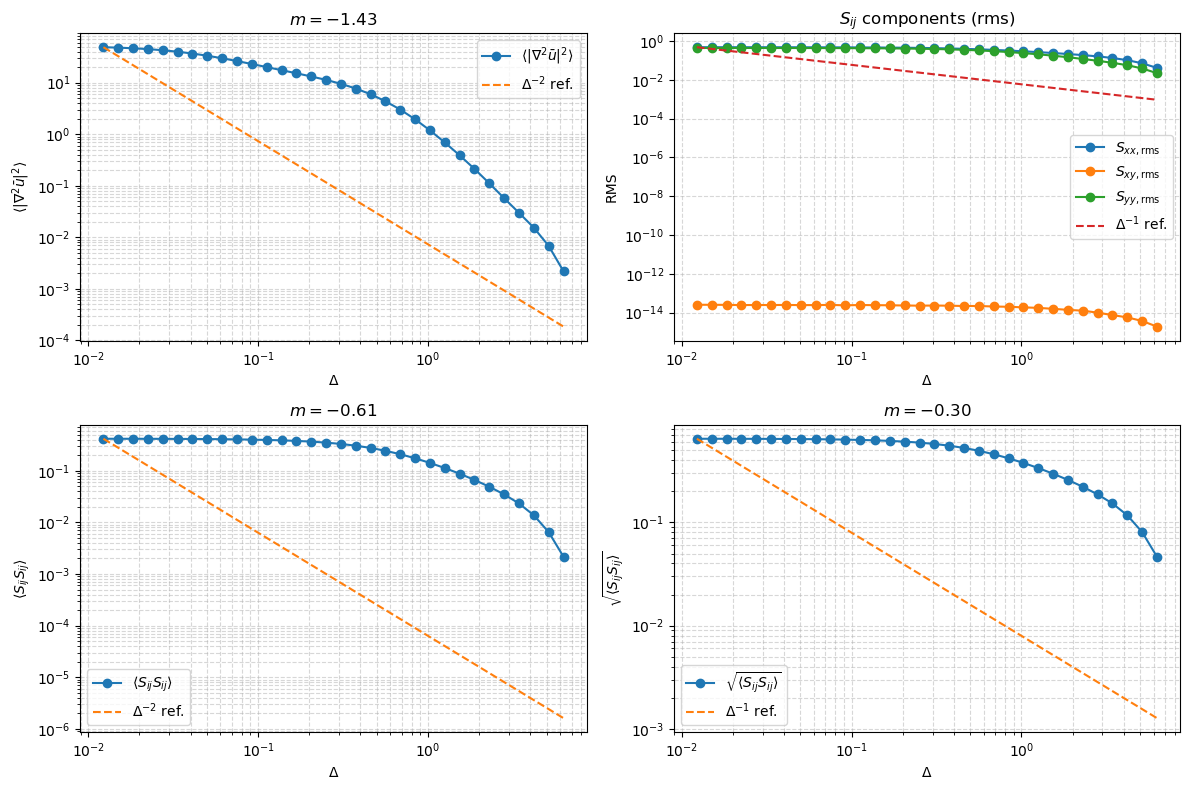

In [12]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Scaling vs Δ for:
  1) ⟨|∇² ū|²⟩
  2) Strain components Sxx, Sxy, Syy (rms)
  3) Strain invariant ⟨S_ij S_ij⟩ = ⟨Sxx^2 + Syy^2 + 2 Sxy^2⟩

Loader:   h5py v7.3 .mat, variable 'intials' ONLY
Filter:   Gaussian in Fourier space, Ĝ = exp(-k^2 Δ^2 / 24)
Derivs:   spectral (∂ ↔ i k, ∇² ↔ -k²)

Expected enstrophy-cascade trends (heuristic):
  - ⟨S_ij S_ij⟩ ~ Δ^{-2}   (since S_rms ~ U_Δ/Δ and U_Δ varies weakly)
  - ⟨|∇² ū|²⟩   ~ Δ^{-2}
Slow log corrections ignored in slope checks.
"""

import os, re, h5py
import numpy as np
import matplotlib.pyplot as plt

# =================== CONFIG ===================
MAT_PATH  = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"
Lx = 2.0*np.pi
Ly = 2.0*np.pi

DELTA_MIN = 2*np.pi/512.0
DELTA_MAX = 2*np.pi
N_DELTAS  = 32
# ==============================================

# --------- Loader: v7.3 .mat (HDF5) ----------
def load_variable_from_mat(mat_file_path, variable_name):
    with h5py.File(mat_file_path, 'r') as f:
        if variable_name not in f:
            raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")
        return np.array(f[variable_name])


# --------- Spectral utilities ----------
def _fftfreq_rad(N, L):
    n = np.arange(N)
    k = np.where(n <= N//2, n, n - N)
    return (2*np.pi/L) * k

def _rfftfreq_rad(N, L):
    n = np.arange(N//2 + 1)
    return (2*np.pi/L) * n

def _k_grids(Nx, Ny, Lx, Ly):
    kx = _fftfreq_rad(Nx, Lx)
    ky = _rfftfreq_rad(Ny, Ly)
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K2 = KX*KX + KY*KY
    return kx, ky, KX, KY, K2

# --------- Filtering ----------
def gaussian_filter_fft(field: np.ndarray, Delta: float, Lx: float, Ly: float) -> np.ndarray:
    """
    Apply Gaussian filter in spectral space: Ĝ = exp(-k^2 Δ^2 / 24)
    field: (Nx,Ny) -> (Nx,Ny)
    """
    Nx, Ny = field.shape
    _, _, KX, KY, K2 = _k_grids(Nx, Ny, Lx, Ly)
    G = np.exp(-K2 * (Delta**2)/24.0)
    F = np.fft.rfft2(field)
    return np.fft.irfft2(F * G, s=(Nx, Ny))

# --------- Diagnostics ----------
def laplacian_energy_from_filtered(ux_f: np.ndarray, uy_f: np.ndarray,
                                   Lx: float, Ly: float) -> float:
    """⟨|∇² ū|²⟩ = ⟨(∇² ūx)² + (∇² ūy)²⟩ via spectral Laplacian."""
    Nx, Ny = ux_f.shape
    _, _, KX, KY, K2 = _k_grids(Nx, Ny, Lx, Ly)
    Ux_hat = np.fft.rfft2(ux_f)
    Uy_hat = np.fft.rfft2(uy_f)
    lap_ux = np.fft.irfft2((-K2) * Ux_hat, s=(Nx, Ny)).real
    lap_uy = np.fft.irfft2((-K2) * Uy_hat, s=(Nx, Ny)).real
    return float(np.mean(lap_ux*lap_ux + lap_uy*lap_uy))

def strain_components_from_filtered(ux_f: np.ndarray, uy_f: np.ndarray,
                                    Lx: float, Ly: float):
    """
    Return Sxx, Sxy, Syy where Sij = 0.5(∂i ū_j + ∂j ū_i).
    In 2D: i,j ∈ {x,y}. Sxy = Syx.
    """
    Nx, Ny = ux_f.shape
    _, _, KX, KY, _ = _k_grids(Nx, Ny, Lx, Ly)
    iKX, iKY = 1j*KX, 1j*KY

    Ux_hat = np.fft.rfft2(ux_f)
    Uy_hat = np.fft.rfft2(uy_f)

    ux_x = np.fft.irfft2(iKX * Ux_hat, s=(Nx, Ny)).real
    ux_y = np.fft.irfft2(iKY * Ux_hat, s=(Nx, Ny)).real
    uy_x = np.fft.irfft2(iKX * Uy_hat, s=(Nx, Ny)).real
    uy_y = np.fft.irfft2(iKY * Uy_hat, s=(Nx, Ny)).real

    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5*(ux_y + uy_x)
    return Sxx, Sxy, Syy

def strain_invariant_S2(Sxx: np.ndarray, Sxy: np.ndarray, Syy: np.ndarray) -> float:
    """
    ⟨S_ij S_ij⟩ = ⟨Sxx^2 + Syy^2 + 2 Sxy^2⟩ in 2D.
    """
    return float(np.mean(Sxx*Sxx + Syy*Syy + 2.0*Sxy*Sxy))

# --------- Measurement vs Δ ----------
def fit_loglog(x, y):
    xm, ym = np.log(np.asarray(x)), np.log(np.asarray(y) + 1e-300)
    A = np.vstack([xm, np.ones_like(xm)]).T
    m, b = np.linalg.lstsq(A, ym, rcond=None)[0]
    return float(m), float(b)

def measure_scalings_initials(u: np.ndarray, Deltas: np.ndarray,
                              Lx: float = 2*np.pi, Ly: float = 2*np.pi):
    """
    For a single (Nx,Ny,2) initials snapshot:
      For each Δ:
        - filter u
        - compute ⟨|∇² ū|²⟩
        - compute Sxx_rms, Sxy_rms, Syy_rms
        - compute ⟨S_ij S_ij⟩ and its sqrt
    Return dict of series + slopes.
    """
    ux, uy = u[...,0], u[...,1]

    D  = np.asarray(Deltas, dtype=float)
    L2 = []   # ⟨|∇² ū|²⟩
    Sxx_rms, Sxy_rms, Syy_rms = [], [], []
    S2, S2_sqrt = [], []

    for Delta in D:
        uxf = gaussian_filter_fft(ux, Delta, Lx, Ly)
        uyf = gaussian_filter_fft(uy, Delta, Lx, Ly)

        # Laplacian energy
        L2.append(laplacian_energy_from_filtered(uxf, uyf, Lx, Ly))

        # Strain components and invariants
        Sxx, Sxy, Syy = strain_components_from_filtered(uxf, uyf, Lx, Ly)
        Sxx_rms.append(float(np.sqrt(np.mean(Sxx*Sxx))))
        Sxy_rms.append(float(np.sqrt(np.mean(Sxy*Sxy))))
        Syy_rms.append(float(np.sqrt(np.mean(Syy*Syy))))

        S2_val = strain_invariant_S2(Sxx, Sxy, Syy)
        S2.append(S2_val)
        S2_sqrt.append(float(np.sqrt(max(S2_val, 0.0))))

    # slopes
    m_L2, _      = fit_loglog(D, L2)
    m_Sxx, _     = fit_loglog(D, Sxx_rms)
    m_Sxy, _     = fit_loglog(D, Sxy_rms)
    m_Syy, _     = fit_loglog(D, Syy_rms)
    m_S2, _      = fit_loglog(D, S2)
    m_S2sqrt, _  = fit_loglog(D, S2_sqrt)

    results = {
        "D": D,
        "L2": np.asarray(L2),
        "Sxx_rms": np.asarray(Sxx_rms),
        "Sxy_rms": np.asarray(Sxy_rms),
        "Syy_rms": np.asarray(Syy_rms),
        "S2": np.asarray(S2),
        "S2_sqrt": np.asarray(S2_sqrt),
        "slopes": {
            "<|∇²ū|²>": m_L2,
            "Sxx_rms": m_Sxx,
            "Sxy_rms": m_Sxy,
            "Syy_rms": m_Syy,
            "<SijSij>": m_S2,
            "sqrt<SijSij>": m_S2sqrt,
        }
    }
    return results

# =========================
# ---- Run & Plot ----------
# =========================
def main():
    if not os.path.exists(MAT_PATH):
        raise FileNotFoundError(f"MAT file not found: {MAT_PATH}")

    arr = load_variable_from_mat(MAT_PATH, "intials")

    DELTAS = np.geomspace(DELTA_MIN, DELTA_MAX, N_DELTAS)
    res = measure_scalings_initials(u, DELTAS, Lx=Lx, Ly=Ly)

    print(f"Loaded {os.path.basename(MAT_PATH)}  u.shape={u.shape}")
    print("Log–log slopes m vs Δ (theory in enstrophy range ~ -2 for ⟨|∇²ū|²⟩ and ⟨SijSij⟩; ~ -1 for their square-roots):")
    for k, v in res["slopes"].items():
        print(f"  {k:16s}: {v:+.3f}")

    D = res["D"]

    # --- Plots ---
    plt.figure(figsize=(12,8))

    # (1) Laplacian energy
    plt.subplot(2,2,1)
    L2 = res["L2"]
    plt.loglog(D, L2, "o-", label=r"$\langle|\nabla^2\bar{ u}|^2\rangle$")
    ref = (L2[0] / (D[0]**(-2))) * (D**(-2))
    plt.loglog(D, ref, "--", label=r"$\Delta^{-2}$ ref.")
    plt.title(rf"$m={res['slopes']['<|∇²ū|²>']:+.2f}$")
    plt.xlabel(r"$\Delta$"); plt.ylabel(r"$\langle|\nabla^2\bar{ u}|^2\rangle$")
    plt.grid(True, which="both", ls="--", alpha=0.5); plt.legend()

    # (2) Strain rms components
    plt.subplot(2,2,2)
    plt.loglog(D, res["Sxx_rms"], "o-", label=r"$S_{xx,{\rm rms}}$")
    plt.loglog(D, res["Sxy_rms"], "o-", label=r"$S_{xy,{\rm rms}}$")
    plt.loglog(D, res["Syy_rms"], "o-", label=r"$S_{yy,{\rm rms}}$")
    plt.loglog(D, (res["Sxx_rms"][0]/(D[0]**(-1)))*(D**(-1)), "--", label=r"$\Delta^{-1}$ ref.")
    plt.title(r"$S_{ij}$ components (rms)")
    plt.xlabel(r"$\Delta$"); plt.ylabel(r"RMS")
    plt.grid(True, which="both", ls="--", alpha=0.5); plt.legend()

    # (3) S_ij S_ij
    plt.subplot(2,2,3)
    S2 = res["S2"]
    plt.loglog(D, S2, "o-", label=r"$\langle S_{ij}S_{ij}\rangle$")
    refS2 = (S2[0] / (D[0]**(-2))) * (D**(-2))
    plt.loglog(D, refS2, "--", label=r"$\Delta^{-2}$ ref.")
    plt.title(rf"$m={res['slopes']['<SijSij>']:+.2f}$")
    plt.xlabel(r"$\Delta$"); plt.ylabel(r"$\langle S_{ij}S_{ij}\rangle$")
    plt.grid(True, which="both", ls="--", alpha=0.5); plt.legend()

    # (4) sqrt<S_ij S_ij>
    plt.subplot(2,2,4)
    S2s = res["S2_sqrt"]
    plt.loglog(D, S2s, "o-", label=r"$\sqrt{\langle S_{ij}S_{ij}\rangle}$")
    refS = (S2s[0] / (D[0]**(-1))) * (D**(-1))
    plt.loglog(D, refS, "--", label=r"$\Delta^{-1}$ ref.")
    plt.title(rf"$m={res['slopes']['sqrt<SijSij>']:+.2f}$")
    plt.xlabel(r"$\Delta$"); plt.ylabel(r"$\sqrt{\langle S_{ij}S_{ij}\rangle}$")
    plt.grid(True, which="both", ls="--", alpha=0.5); plt.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [23]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os, h5py
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

# =================== CONFIG ===================
MAT_PATH  = "/storage/scratch1/1/bchoi73/maturevm_1e-5.mat"
Lx = float(2*jnp.pi)
Ly = float(2*jnp.pi)

DELTA_MIN = 2*np.pi/512.0
DELTA_MAX = 2*np.pi/6.0
N_DELTAS  = 32
EPS = 1e-300
MAX_T = 5  # used by signature default (kept for your function)
# ==============================================

# ----- loader pieces -----
def load_variable_from_mat(mat_file_path, variable_name):
    with h5py.File(mat_file_path, 'r') as f:
        if variable_name not in f:
            raise KeyError(f"Variable '{variable_name}' not found in {mat_file_path}")
        return np.array(f[variable_name])

# ====== USE EXACTLY THIS TO LOAD ======
def load_velocity_uv(path: str, max_t: int | None = MAX_T) -> jnp.ndarray:
    """
    Return velocity array u with shape (Nx, Ny, 2, T), dtype float64, using only 's'.
    Supports shapes: (T,2,Nx,Ny) or (2,Nx,Ny,T).
    """
    s = load_variable_from_mat(path, "s")
    s = jnp.asarray(s)
    if s.ndim != 4:
        raise ValueError(f"Unsupported 's' shape: {s.shape}")
    max_t = 5
    if s.shape[1] == 2:    # (T,2,Nx,Ny)
        T, _, Nx, Ny = s.shape
        U = s[:,1,:,:]
        V = s[:,0,:,:]
        if max_t is not None:
            U, V = U[:max_t], V[:max_t]
        U = jnp.transpose(U, (1,2,0))  # (Nx,Ny,T)
        V = jnp.transpose(V, (1,2,0))
    elif s.shape[0] == 2:  # (2,Nx,Ny,T)
        _, Nx, Ny, T = s.shape
        U = s[1,...]
        V = s[0,...]
        if max_t is not None:
            U, V = U[..., :max_t], V[..., :max_t]
    else:
        raise ValueError(f"Unrecognized 's' layout: {s.shape}")

    u = jnp.stack([U, V], axis=2).astype(jnp.float64)  # (Nx,Ny,2,T)
    return u
# ======================================

# ----- spectral grids / filtering -----
def rfft_mesh_2d(Nx: int, Ny: int, Lx: float, Ly: float):
    kx = 2*jnp.pi*jnp.fft.fftfreq(Nx, d=Lx/Nx)
    ky = 2*jnp.pi*jnp.fft.rfftfreq(Ny, d=Ly/Ny)
    KX, KY = jnp.meshgrid(kx, ky, indexing='ij')
    K2 = KX*KX + KY*KY
    return kx, ky, KX, KY, K2

def gaussian_filter_fft(field: jnp.ndarray, Delta: float, Lx: float, Ly: float) -> jnp.ndarray:
    Nx, Ny = field.shape
    _, _, _, _, K2 = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    F_hat = jnp.fft.rfft2(field)
    Ghat  = jnp.exp(-(Delta*Delta)*K2/24.0)
    return jnp.fft.irfft2(F_hat * Ghat, s=(Nx, Ny)).real

# ----- derivatives / diagnostics -----
def strain_components_from_filtered(ux_f: jnp.ndarray, uy_f: jnp.ndarray,
                                    Lx: float, Ly: float):
    Nx, Ny = ux_f.shape
    kx, ky, KX, KY, _ = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    iKX, iKY = 1j*KX, 1j*KY
    Ux_hat = jnp.fft.rfft2(ux_f)
    Uy_hat = jnp.fft.rfft2(uy_f)
    ux_x = jnp.fft.irfft2(iKX*Ux_hat, s=(Nx, Ny)).real
    ux_y = jnp.fft.irfft2(iKY*Ux_hat, s=(Nx, Ny)).real
    uy_x = jnp.fft.irfft2(iKX*Uy_hat, s=(Nx, Ny)).real
    uy_y = jnp.fft.irfft2(iKY*Uy_hat, s=(Nx, Ny)).real
    Sxx = ux_x
    Syy = uy_y
    Sxy = 0.5*(ux_y + uy_x)
    return Sxx, Sxy, Syy

def mean_strain_frobenius(Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray) -> float:
    mSxx = float(jnp.mean(Sxx))
    mSyy = float(jnp.mean(Syy))
    mSxy = float(jnp.mean(Sxy))
    return float(np.sqrt(mSxx*mSxx + mSyy*mSyy + 2.0*mSxy*mSxy))

def strain_invariant_S2(Sxx: jnp.ndarray, Sxy: jnp.ndarray, Syy: jnp.ndarray) -> float:
    return float(jnp.mean(Sxx*Sxx + Syy*Syy + 2.0*Sxy*Sxy))

def laplacian_energy_from_filtered(ux_f: jnp.ndarray, uy_f: jnp.ndarray,
                                   Lx: float, Ly: float) -> float:
    Nx, Ny = ux_f.shape
    _, _, _, _, K2 = rfft_mesh_2d(Nx, Ny, Lx, Ly)
    Ux_hat = jnp.fft.rfft2(ux_f)
    Uy_hat = jnp.fft.rfft2(uy_f)
    lap_ux = jnp.fft.irfft2((-K2)*Ux_hat, s=(Nx, Ny)).real
    lap_uy = jnp.fft.irfft2((-K2)*Uy_hat, s=(Nx, Ny)).real
    return float(jnp.mean(lap_ux*lap_ux + lap_uy*lap_uy))

# ----- fitting -----
def fit_loglog(x: np.ndarray, y: np.ndarray):
    xm, ym = np.log(np.asarray(x)), np.log(np.asarray(y) + EPS)
    A = np.vstack([xm, np.ones_like(xm)]).T
    m, b = np.linalg.lstsq(A, ym, rcond=None)[0]
    return float(m), float(b)

# ----- measurement (averaged over T) -----
def measure_scalings_over_Delta(u: jnp.ndarray, Deltas: np.ndarray,
                                Lx: float, Ly: float):
    Nx, Ny, _, T = u.shape
    D  = np.asarray(Deltas, dtype=float)
    L2 = []
    Sxx_rms, Sxy_rms, Syy_rms = [], [], []
    S2, S2_sqrt = [], []
    R_ratio, R2_ratio = [], []
    meanS_norms = []

    for Delta in D:
        # time-average all metrics
        L2_t = []
        Sxx_t, Sxy_t, Syy_t, S2_t, mS_t = [], [], [], [], []
        for t in range(int(T)):
            ux = u[:, :, 0, t]; uy = u[:, :, 1, t]
            uxf = gaussian_filter_fft(ux, Delta, Lx, Ly)
            uyf = gaussian_filter_fft(uy, Delta, Lx, Ly)

            L2_val = laplacian_energy_from_filtered(uxf, uyf, Lx, Ly)
            Sxx, Sxy, Syy = strain_components_from_filtered(uxf, uyf, Lx, Ly)
            
            print(Sxx+Syy)

            L2_t.append(L2_val)
            Sxx_t.append(float(jnp.sqrt(jnp.mean(Sxx*Sxx))))
            Sxy_t.append(float(jnp.sqrt(jnp.mean(Sxy*Sxy))))
            Syy_t.append(float(jnp.sqrt(jnp.mean(Syy*Syy))))
            S2_t.append(strain_invariant_S2(Sxx, Sxy, Syy))
            mS_t.append(mean_strain_frobenius(Sxx, Sxy, Syy))

        L2_mean = float(np.mean(L2_t))
        Sxx_mean = float(np.mean(Sxx_t))
        Sxy_mean = float(np.mean(Sxy_t))
        Syy_mean = float(np.mean(Syy_t))
        S2_mean  = float(np.mean(S2_t))
        mS_mean  = float(np.mean(mS_t))

        L2.append(L2_mean)
        Sxx_rms.append(Sxx_mean)
        Sxy_rms.append(Sxy_mean)
        Syy_rms.append(Syy_mean)
        S2.append(S2_mean)
        S2_sqrt.append(float(np.sqrt(max(S2_mean, 0.0))))
        meanS_norms.append(mS_mean)
        R_ratio.append(L2_mean / (S2_mean + EPS))
        R2_ratio.append(L2_mean * mS_mean / (S2_mean + EPS))

    m_L2, _      = fit_loglog(D, L2)
    m_Sxx, _     = fit_loglog(D, Sxx_rms)
    m_Sxy, _     = fit_loglog(D, Sxy_rms)
    m_Syy, _     = fit_loglog(D, Syy_rms)
    m_S2, _      = fit_loglog(D, S2)
    m_S2sqrt, _  = fit_loglog(D, S2_sqrt)
    m_R, _       = fit_loglog(D, R_ratio)
    m_R2, _      = fit_loglog(D, R2_ratio)

    return {
        "D": D,
        "L2": np.asarray(L2),
        "Sxx_rms": np.asarray(Sxx_rms),
        "Sxy_rms": np.asarray(Sxy_rms),
        "Syy_rms": np.asarray(Syy_rms),
        "S2": np.asarray(S2),
        "S2_sqrt": np.asarray(S2_sqrt),
        "R_ratio": np.asarray(R_ratio),
        "R2_ratio": np.asarray(R2_ratio),
        "meanS_norm": np.asarray(meanS_norms),
        "slopes": {
            "<|∇²ū|²>": m_L2,
            "Sxx_rms": m_Sxx,
            "Sxy_rms": m_Sxy,
            "Syy_rms": m_Syy,
            "<SijSij>": m_S2,
            "sqrt<SijSij>": m_S2sqrt,
            "R = L2/<SijSij>": m_R,
            "R2 = L2*||<S>||_F/<SijSij>": m_R2,
        }
    }

# =========================
# ---- Run & Plot ----------
# =========================
def main():
    if not os.path.exists(MAT_PATH):
        raise FileNotFoundError(f"MAT file not found: {MAT_PATH}")

    u = load_velocity_uv(MAT_PATH)  # EXACT loader
    print(f"Loaded {os.path.basename(MAT_PATH)} u.shape={tuple(u.shape)}")

    DELTAS = np.geomspace(DELTA_MIN, DELTA_MAX, N_DELTAS)
    res = measure_scalings_over_Delta(u, DELTAS, Lx=Lx, Ly=Ly)

    print("Log–log slopes m vs Δ:")
    for k, v in res["slopes"].items():
        print(f"  {k:28s}: {v:+.3f}")

    D = res["D"]

    plt.figure(figsize=(12,12))

    # (1) ⟨|∇² ū|²⟩
    ax = plt.subplot(3,2,1)
    L2 = res["L2"]
    ax.loglog(D, L2, "o-", label=r"$\langle|\nabla^2\bar{\mathbf u}|^2\rangle$")
    ref = (L2[0] / (D[0]**(-2))) * (D**(-2))
    ax.loglog(D, ref, "--", label=r"$\Delta^{-2}$ ref.")
    ax.set_title(rf"$m={res['slopes']['<|∇²ū|²>']:+.2f}$")
    ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$\langle|\nabla^2\bar{\mathbf u}|^2\rangle$")
    ax.grid(True, which="both", ls="--", alpha=0.5); ax.legend()

    # (2) ⟨Sij Sij⟩
    ax = plt.subplot(3,2,2)
    S2 = res["S2"]
    ax.loglog(D, S2, "o-", label=r"$\langle S_{ij}S_{ij}\rangle$")
    refS2 = (S2[0] / (D[0]**(-2))) * (D**(-2))
    ax.loglog(D, refS2, "--", label=r"$\Delta^{-2}$ ref.")
    ax.set_title(rf"$m={res['slopes']['<SijSij>']:+.2f}$")
    ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$\langle S_{ij}S_{ij}\rangle$")
    ax.grid(True, which="both", ls="--", alpha=0.5); ax.legend()

    # (3) ||<S>||_F
    ax = plt.subplot(3,2,3)
    mS = res["meanS_norm"]
    ax.loglog(D, mS + EPS, "o-", label=r"$\|\langle S\rangle\|_F$")
    ax.loglog(D, 0*D + (mS[0]+EPS), "--", label="flat ref.")
    ax.set_title(r"$\|\langle S\rangle\|_F$")
    ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$\|\langle S\rangle\|_F$")
    ax.grid(True, which="both", ls="--", alpha=0.5); ax.legend()

    # (4) R = L2 / <SijSij>
    ax = plt.subplot(3,2,4)
    R = res["R_ratio"]
    ax.loglog(D, R, "o-", label=r"$R=\frac{\langle|\nabla^2\bar{\mathbf u}|^2\rangle}{\langle S_{ij}S_{ij}\rangle}$")
    ax.loglog(D, 0*D + R[0], "--", label="flat ref.")
    ax.set_title(rf"$m={res['slopes']['R = L2/<SijSij>']:+.2f}$ (expect ≈ 0)")
    ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$R(\Delta)$")
    ax.grid(True, which="both", ls="--", alpha=0.5); ax.legend()

    # (5) R2 = L2 * ||<S>||_F / <SijSij>
    ax = plt.subplot(3,2,5)
    R2 = res["R2_ratio"]
    ax.loglog(D, R2 + EPS, "o-", label=r"$R_2=\frac{\langle|\nabla^2\bar{\mathbf u}|^2\rangle\,\|\langle S\rangle\|_F}{\langle S_{ij}S_{ij}\rangle}$")
    ax.loglog(D, 0*D + (R2[0]+EPS), "--", label="flat ref.")
    ax.set_title(rf"$m={res['slopes']['R2 = L2*||<S>||_F/<SijSij>']:+.2f}$")
    ax.set_xlabel(r"$\Delta$"); ax.set_ylabel(r"$R_2(\Delta)$")
    ax.grid(True, which="both", ls="--", alpha=0.5); ax.legend()

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

Loaded maturevm_1e-5.mat u.shape=(2048, 2048, 2, 5)
[[0.25136918 0.25928771 0.26705232 ... 0.22886503 0.23592661 0.24348062]
 [0.24741337 0.25544912 0.26345342 ... 0.22495086 0.23190564 0.23947012]
 [0.24344525 0.2516262  0.25977764 ... 0.2210531  0.22798318 0.23547909]
 ...
 [0.26304653 0.2705066  0.27768284 ... 0.24103197 0.24816126 0.25555292]
 [0.2591947  0.26682806 0.27423438 ... 0.2369651  0.2440733  0.25160193]
 [0.25526255 0.26303637 0.27066517 ... 0.2328424  0.23996903 0.24748263]]
[[0.26758584 0.27533865 0.28268388 ... 0.24299243 0.25120723 0.25949058]
 [0.2639504  0.2719944  0.27953714 ... 0.23904447 0.24725889 0.25570154]
 [0.2603304  0.26855397 0.2763729  ... 0.23502353 0.24333131 0.25191563]
 ...
 [0.27810657 0.2852021  0.29182744 ... 0.25501528 0.26290327 0.27062485]
 [0.27468458 0.28197497 0.28887406 ... 0.25106156 0.259044   0.2669543 ]
 [0.27109128 0.27868333 0.28580084 ... 0.2469846  0.25514567 0.26322865]]
[[0.28380206 0.2907642  0.29709944 ... 0.2599447  0.26830804

[[0.25141284 0.25906903 0.26662976 ... 0.22995445 0.23667309 0.24392319]
 [0.24763826 0.25539196 0.26308036 ... 0.2261874  0.23284696 0.2400202 ]
 [0.24379227 0.25162825 0.25949228 ... 0.22244549 0.2289983  0.23615918]
 ...
 [0.26296076 0.2701934  0.27719843 ... 0.24181272 0.24861674 0.2557705 ]
 [0.25915065 0.2665288  0.27371275 ... 0.23783728 0.24460915 0.25177136]
 [0.25532758 0.26284796 0.27023154 ... 0.23387618 0.2406767  0.24786815]]
[[0.26711482 0.27468002 0.2819105  ... 0.24343973 0.25126415 0.25925037]
 [0.2635691  0.27139187 0.27879488 ... 0.23956873 0.24750899 0.25557917]
 [0.25994334 0.2679171  0.2755781  ... 0.23573042 0.24358994 0.2518022 ]
 ...
 [0.2775555  0.28456125 0.29111642 ... 0.25516948 0.26271942 0.27028027]
 [0.27408326 0.2812907  0.2881042  ... 0.25128227 0.25895756 0.2666063 ]
 [0.27058274 0.27802497 0.28500903 ... 0.2473255  0.25513652 0.26294795]]
[[0.2829486  0.28986323 0.29629043 ... 0.25961196 0.2677157  0.27556264]
 [0.2799175  0.28700876 0.2935957  ... 

[[0.25215113 0.25903425 0.26593137 ... 0.23310378 0.23909457 0.24542087]
 [0.24855897 0.2555338  0.26253626 ... 0.2296255  0.23549476 0.24189162]
 [0.24502105 0.2520436  0.25912932 ... 0.22619036 0.23197022 0.23829165]
 ...
 [0.2629431  0.26959246 0.27606288 ... 0.24407284 0.25006023 0.25646463]
 [0.25932527 0.26607305 0.27272016 ... 0.24033427 0.24633718 0.25275248]
 [0.25576678 0.26252252 0.26933724 ... 0.23667583 0.24272077 0.24909171]]
[[0.266244   0.27333033 0.2801686  ... 0.24499837 0.25191808 0.259113  ]
 [0.26283544 0.2700697  0.277034   ... 0.24146697 0.24836387 0.2556476 ]
 [0.25947952 0.2667843  0.27396494 ... 0.23789471 0.24488872 0.25213486]
 ...
 [0.2762798  0.28289914 0.2892853  ... 0.25583756 0.2626543  0.26951158]
 [0.27300102 0.27971828 0.2863329  ... 0.2521691  0.25910568 0.26601413]
 [0.26960203 0.27653843 0.2832406  ... 0.24858892 0.25548488 0.26257777]]
[[0.28109998 0.28779343 0.29420725 ... 0.25938618 0.2667661  0.274001  ]
 [0.27798072 0.28487343 0.291425   ... 

[[0.255031   0.26054698 0.26615244 ... 0.23961571 0.24447349 0.24968675]
 [0.2520045  0.2575057  0.2631805  ... 0.23651564 0.24148035 0.24660015]
 [0.24891093 0.25449783 0.26017326 ... 0.23352395 0.23838726 0.24357149]
 ...
 [0.26440686 0.26981658 0.27521557 ... 0.24909659 0.25404125 0.25912645]
 [0.2612493  0.26669937 0.27217925 ... 0.24587241 0.2507926  0.2560036 ]
 [0.25816914 0.26358688 0.2691993  ... 0.24271874 0.24767932 0.25278664]]
[[0.26633757 0.27220276 0.27800864 ... 0.24932162 0.2548479  0.26055732]
 [0.2634335  0.26931083 0.27519733 ... 0.24631593 0.251816   0.25756437]
 [0.26043588 0.26641616 0.2723528  ... 0.24332035 0.2488819  0.25461042]
 ...
 [0.27528846 0.28093743 0.28652376 ... 0.2586364  0.2640745  0.2696793 ]
 [0.27232683 0.278059   0.2837286  ... 0.25552177 0.26102257 0.26667985]
 [0.26928794 0.27508307 0.28082535 ... 0.2523376  0.25788337 0.26355448]]
[[0.2787029  0.28465456 0.29045194 ... 0.26078632 0.26676098 0.272775  ]
 [0.27595216 0.28192636 0.2877975  ... 

[[0.2581247  0.26260638 0.26706114 ... 0.24467188 0.24918517 0.25365102]
 [0.25557363 0.26009887 0.2645511  ... 0.24203324 0.24651265 0.25104937]
 [0.2530754  0.25754994 0.26215005 ... 0.23935103 0.24393663 0.2484599 ]
 ...
 [0.26587147 0.27014086 0.27444825 ... 0.25276464 0.25714186 0.26146814]
 [0.26324594 0.2676702  0.27196884 ... 0.25006533 0.2544508  0.2589018 ]
 [0.26071626 0.26514137 0.26951718 ... 0.24735057 0.25183144 0.2562668 ]]
[[0.2672574  0.2717563  0.27622265 ... 0.25355068 0.25814673 0.26271695]
 [0.26489305 0.26945683 0.27393806 ... 0.2511294  0.25570744 0.2603293 ]
 [0.26246676 0.26708746 0.27160168 ... 0.24855083 0.2531829  0.2578676 ]
 ...
 [0.27459562 0.27895677 0.2832172  ... 0.26134786 0.26575682 0.27022573]
 [0.27220342 0.27655518 0.28095838 ... 0.25872982 0.2632577  0.26774257]
 [0.269752   0.27425    0.27859467 ... 0.25619373 0.26074892 0.2652682 ]]
[[0.27682108 0.28133112 0.285686   ... 0.26313448 0.26770985 0.27231383]
 [0.2745676  0.27908868 0.28350812 ... 

...

ValueError: 
\langle|\nabla^2\bar{\mathbf u}|^2\rangle
                     ^
ParseSyntaxException: Unknown symbol: \mathbf, found '\'  (at char 21), (line:1, col:22)

Error in callback <function _draw_all_if_interactive at 0x1553f812dc60> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
\langle|\nabla^2\bar{\mathbf u}|^2\rangle
                     ^
ParseSyntaxException: Unknown symbol: \mathbf, found '\'  (at char 21), (line:1, col:22)

ValueError: 
\langle|\nabla^2\bar{\mathbf u}|^2\rangle
                     ^
ParseSyntaxException: Unknown symbol: \mathbf, found '\'  (at char 21), (line:1, col:22)

<Figure size 1200x1200 with 5 Axes>

[DIAG] column stats:
        family: {'unique': 3, 'sample': ['CONDENSATE', 'FILCOH', 'MATURE'], 'dtype': 'object'}
       dataset: {'unique': 9, 'sample': ['condensate_1e-4', 'condensate_1e-5', 'condensate_1e-6', 'filcoh_1e-4', 'filcoh_1e-5'], 'dtype': 'object'}
            nu: {'nan': 0, 'finite': 1800, 'min': 1e-06, 'max': 0.0001, 'dtype': 'float64'}
         Delta: {'nan': 0, 'finite': 1800, 'min': 0.0122718463, 'max': 3.14159265, 'dtype': 'float64'}
  Ratio_signed: {'nan': 0, 'finite': 1800, 'min': -2803.98956, 'max': 946.572195, 'dtype': 'float64'}
[INFO] dropped 0 rows due to unknown/invalid L_family or Ubar
[INFO] total rows=1800 | finite after parsing=1800 | after Δ/L cuts=1719 | dropped_by_family={'CONDENSATE': 0, 'FILCOH': 0, 'MATURE': 81}


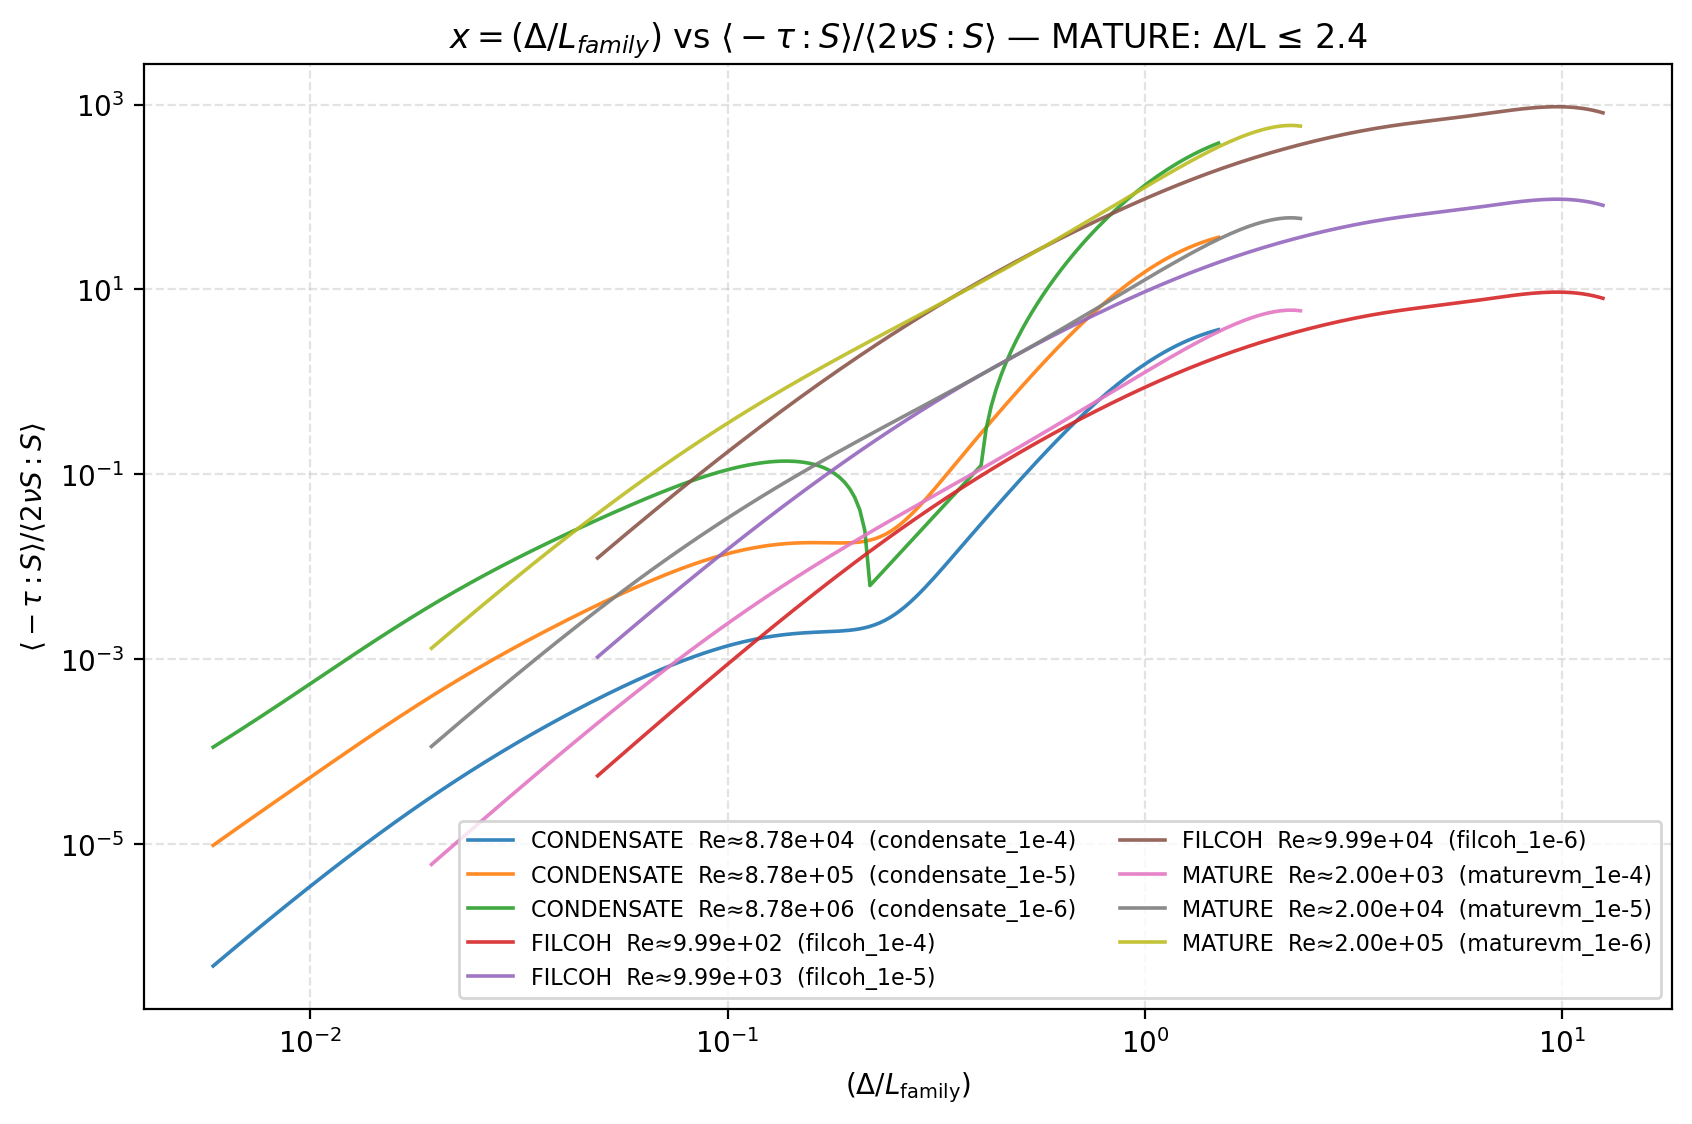

In [15]:
# %% [markdown]
# Δ/L_family (optionally × Re) vs Ratio_signed — per-family cuts + robust diagnostics (show-only)

# %%
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

# ====== CONFIG ======
CSV_PATH = "/storage/home/hcoda1/4/mugliotti3/Research/Untitled Folder/out_ratios_enstrophy/ratios_signed_all.csv"

# Per-family lengthscales
LENGTHSCALES = {
    "FILCOH":  2*np.pi/25.0,
    "MATURE":  2*np.pi/10.0,
    "CONDENSATE":  2*np.pi/3,
}

# Family mean speeds for Re = Ubar * L / nu
UBAR = {
    "FILCOH": 0.39749,
    "MATURE": 0.31764,
    "CONDENSATE": 4.1913,
}

# Per-family Δ/L cuts (applied to x_base BEFORE any ×Re)
CUT_MAX_XBASE = {
    "FILCOH": None,   # e.g., 0.25
    "MATURE": 2.4,    # e.g., 0.15
}
CUT_MIN_XBASE = {
    "FILCOH": None,
    "MATURE": None,
}

# Optional multiply x by Re  (x_scaled = x_base * Re)
MULTIPLY_X_BY_RE = False

Y_COLUMN = "Ratio_signed"
Y_LABEL  = r"$\langle -\tau:S\rangle / \langle 2\nu S:S\rangle$"
# ===============================================

# ---- load ----
if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]

required = {"family","dataset","nu","Delta",Y_COLUMN}
missing = required - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns in CSV: {missing}")

# ---- sanitize family names ----
def normalize_family(x):
    s = str(x).strip().upper()
    if s.startswith("FILCOH"):  return "FILCOH"
    if s.startswith("MATURE"):  return "MATURE"
    return s
df["family"] = df["family"].map(normalize_family)

# ---- numeric coercion for numeric cols ----
def to_num(series):
    cleaned = series.astype(str).str.strip().str.replace(",", "", regex=False)
    cleaned = cleaned.replace({"": np.nan, "nan": np.nan, "None": np.nan})
    return pd.to_numeric(cleaned, errors="coerce")

for c in ["nu", "Delta", Y_COLUMN]:
    df[c] = to_num(df[c])

# ---- safe diagnostics (no isfinite on strings) ----
def col_stats(s: pd.Series):
    if is_numeric_dtype(s):
        arr = s.to_numpy()
        finite = np.isfinite(arr)
        return {
            "nan": int(np.isnan(arr).sum()),
            "finite": int(finite.sum()),
            "min": float(arr[finite].min()) if finite.any() else None,
            "max": float(arr[finite].max()) if finite.any() else None,
            "dtype": s.dtype.name,
        }
    else:
        return {
            "unique": int(s.nunique(dropna=True)),
            "sample": list(s.dropna().astype(str).unique()[:5]),
            "dtype": s.dtype.name,
        }

print("[DIAG] column stats:")
for col in ["family","dataset","nu","Delta",Y_COLUMN]:
    print(f"  {col:>12}: {col_stats(df[col])}")

# Quick hard checks for numeric columns
for col in ["Delta", Y_COLUMN, "nu"]:
    if not is_numeric_dtype(df[col]) or not np.isfinite(df[col].to_numpy()).any():
        raise RuntimeError(f"Column '{col}' has no finite numeric values after parsing. Check the CSV.")

# ---- attach family L and Ubar; compute Re = Ubar*L/nu ----
df["L_family"]   = df["family"].map(lambda fam: float(LENGTHSCALES.get(fam, np.nan)))
df["Ubar_family"] = df["family"].map(lambda fam: float(UBAR.get(fam, np.nan)))

unknown_L = sorted(set(df["family"].unique()) - set(LENGTHSCALES.keys()))
unknown_U = sorted(set(df["family"].unique()) - set(UBAR.keys()))
if unknown_L:
    print(f"[WARN] Families with no LENGTHSCALE mapping (dropping): {unknown_L}")
if unknown_U:
    print(f"[WARN] Families with no UBAR mapping (dropping): {unknown_U}")

before = len(df)
df = df[np.isfinite(df["L_family"]) & np.isfinite(df["Ubar_family"])]
print(f"[INFO] dropped {before - len(df)} rows due to unknown/invalid L_family or Ubar")

df["Re_float"] = (df["Ubar_family"] * df["L_family"]) / df["nu"]

# ---- compute x_base/x_scaled, y_val ----
df["x_base"]   = df["Delta"] / df["L_family"]
df["x_scaled"] = df["x_base"] * (df["Re_float"] if MULTIPLY_X_BY_RE else 1.0)
df["y_val"]    = df[Y_COLUMN]

# ---- apply per-family Δ/L cuts (on x_base) ----
mask_cuts = np.ones(len(df), dtype=bool)
dropped_by_fam = {}
for fam in df["family"].dropna().unique():
    fam_mask = (df["family"] == fam)
    fam_keep = np.ones(len(df), dtype=bool)
    xmax = CUT_MAX_XBASE.get(fam)
    xmin = CUT_MIN_XBASE.get(fam)
    if xmax is not None:
        fam_keep &= ((df["x_base"] <= float(xmax)) | ~fam_mask)
    if xmin is not None:
        fam_keep &= ((df["x_base"] >= float(xmin)) | ~fam_mask)
    before_fam = int(fam_mask.sum())
    after_fam  = int((fam_mask & fam_keep).sum())
    dropped_by_fam[fam] = before_fam - after_fam
    mask_cuts &= fam_keep

# ---- finite filter + cuts ----
finite_mask = np.isfinite(df["x_scaled"]) & np.isfinite(df["y_val"])
mask = finite_mask & mask_cuts
print(f"[INFO] total rows={len(df)} | finite after parsing={int(finite_mask.sum())} | "
      f"after Δ/L cuts={int(mask.sum())} | dropped_by_family={dropped_by_fam}")

if mask.sum() == 0:
    bad = df[~finite_mask].head(5)
    print("[DEBUG] Non-finite rows example:")
    display(bad[["family","dataset","Delta","L_family","Ubar_family","x_base","x_scaled","y_val","nu"]])
    raise RuntimeError("No valid points after sanitation + cuts. "
                       "Check NaNs in Delta/nu/Ratio_signed and your LENGTHSCALES/CUTS.")

# ---- choose scale ----
pos_log_mask = mask & (df["x_scaled"] > 0) & (df["y_val"] > 0)
if int(pos_log_mask.sum()) > 0:
    plot_df = df[pos_log_mask].copy()
    xscale, yscale, ymsg = "log", "log", ""
else:
    fallback_mask = mask & (df["x_scaled"] > 0)
    plot_df = df[fallback_mask].copy()
    xscale, yscale, ymsg = "log", "symlog", " (symlog)"
    print("[WARN] No positive y after cuts for log–log; using y='symlog' to show signed values.")

if plot_df.empty:
    print("[DEBUG] Example rows with x<=0 after cuts:", df[mask & (df["x_scaled"] <= 0)].head(3))
    raise RuntimeError("No valid points to plot (x must be > 0). Adjust Δ/L cuts or LENGTHSCALES.")

# ---- plot ----
plt.figure(figsize=(8.6, 5.8))
plt.xscale(xscale)
if yscale == "log":
    plt.yscale("log")
else:
    plt.yscale("symlog", linthresh=1e-8)

families = sorted([f for f in plot_df["family"].dropna().unique() if isinstance(f, str)])
markers    = ["o","s","^","D","v","P","X","*"]
linestyles = ["-","--","-."," :".replace(" ","")]

legend_entries = 0
for fi, fam in enumerate(families):
    sub = plot_df[plot_df["family"] == fam]
    for ri, (Re_val, grp) in enumerate(sub.groupby("Re_float")):
        if not np.isfinite(Re_val) or grp.empty:
            continue
        grp = grp.sort_values("x_scaled")
        label = f"{fam}  Re≈{Re_val:.2e}  ({grp['dataset'].iloc[0]})"
        plt.plot(
            (grp["x_scaled"].to_numpy()),   # <-- x = (Δ/L)^4  (optionally × Re)^4
            grp["y_val"].to_numpy(),
            #linestyle=linestyles[fi % len(linestyles)],
            #marker=markers[ri % len(markers)],
            ms=3.5, lw=1.3, alpha=0.9, label=label
        )
        legend_entries += 1

# Axis labels / title reflect the ^4 transform
xlab_core = r"$(\Delta / L_{\mathrm{family}})$"
if MULTIPLY_X_BY_RE:
    xlab_core = r"$\big((\Delta / L_{\mathrm{family}})\times \mathrm{Re}\big)^{4}$"
plt.xlabel(xlab_core)
plt.ylabel(Y_LABEL + ymsg)

# Subtitle shows Δ/L cuts
cuts_txt = []
for fam in ["FILCOH","MATURE"]:
    lo = CUT_MIN_XBASE.get(fam); hi = CUT_MAX_XBASE.get(fam)
    if (lo is not None) or (hi is not None):
        seg = []
        if lo is not None: seg.append(f"{lo:g} ≤")
        seg.append("Δ/L")
        if hi is not None: seg.append(f"≤ {hi:g}")
        cuts_txt.append(f"{fam}: " + " ".join(seg))
subtitle = (" | ".join(cuts_txt)) if cuts_txt else "no Δ/L cuts"
title_extra = " × Re" if MULTIPLY_X_BY_RE else ""
plt.title(rf"$x = (\Delta/L_{{family}}){title_extra}$ vs {Y_LABEL} — {subtitle}")

plt.grid(True, which="both", ls="--", alpha=0.35)
if legend_entries:
    plt.legend(ncol=2, fontsize=8)
plt.tight_layout()

# ---- grid & ticks: show ONLY decade lines (10^k) ----
from matplotlib.ticker import LogLocator, NullFormatter
ax = plt.gca()

# X axis (always log in your script)
if xscale == "log":
    ax.xaxis.set_major_locator(LogLocator(base=10.0))
    ax.xaxis.set_minor_locator(LogLocator(base=10.0, subs=()))  # disable minor ticks
    ax.xaxis.set_minor_formatter(NullFormatter())

# Y axis
if yscale == "log":
    ax.yaxis.set_major_locator(LogLocator(base=10.0))
    ax.yaxis.set_minor_locator(LogLocator(base=10.0, subs=()))
    ax.yaxis.set_minor_formatter(NullFormatter())
else:
    # symlog: symmetric decade ticks outside linear core
    linthresh = 1e-8  # must match set_yscale
    ymin, ymax = ax.get_ylim()
    rng_max = max(abs(ymin), abs(ymax))
    if rng_max <= 0:
        decade_ticks = [0.0]
    else:
        import math
        kmax = int(math.floor(math.log10(rng_max)))
        kmin = int(math.ceil(math.log10(linthresh))) if linthresh > 0 else -12
        ks = list(range(kmin, kmax + 1))
        pos = [10.0**k for k in ks]
        neg = [-v for v in pos]
        decade_ticks = [v for v in (neg[::-1] + [0.0] + pos) if (ymin <= v <= ymax)]
    ax.set_yticks(decade_ticks)

    # Pretty labels for symlog decades
    def _fmt_symlog_tick(v):
        if v == 0:
            return "0"
        s = "-" if v < 0 else ""
        p = abs(v)
        k = int(round(np.log10(p)))
        if np.isclose(p, 10.0**k, rtol=1e-12, atol=0.0):
            return rf"{s}$10^{{{k}}}$"
        return ""
    ax.set_yticklabels([_fmt_symlog_tick(v) for v in ax.get_yticks()])

# Grid: ONLY majors (decades)
ax.grid(True, which="major", ls="--", alpha=0.35)
ax.grid(False, which="minor")

plt.show()